# Ứng dụng Học máy đánh giá hiệu quả nội dung số của Phúc Long Coffee & Tea trong bối cảnh cạnh tranh ngành và đề xuất giải pháp tối ưu

**Trường Đại học Kinh tế — Luật (UEL)** | Môn: Phân tích Marketing số | Mã LHP: 253BIM502601 | GVHD: ThS. Văn Đức Sơn Hà

**Nhóm 7**

---

## Phase 1: Phân tích Batch — Thu thập, EDA, ML, Sentiment

**Dữ liệu**: 27,370 bản ghi (740 TikTok videos + 3,598 Facebook posts + 23,032 bình luận)
**Thương hiệu**: Phúc Long (chính), Highlands Coffee, Katinat (đối thủ cạnh tranh)
**Nền tảng**: TikTok + Facebook | **Thời gian**: 01/2022 — 05/2026
**Phương pháp crawl**: yt-dlp (TikTok videos), curl_cffi + msToken (TikTok comments), Apify GraphQL + CloakBrowser (Facebook posts), mbasic HTML parsing (Facebook comments)

---

# II. Thu thập và tiền xử lý dữ liệu

## 2.1. Tải dữ liệu và thiết lập môi trường

Dữ liệu được thu thập từ hai nền tảng TikTok và Facebook thông qua pipeline crawl đa kỹ thuật: yt-dlp subprocess cho TikTok videos, curl_cffi với TLS fingerprint impersonation cho TikTok comments, Apify Facebook Posts Scraper (GraphQL API) kết hợp CloakBrowser DOM extraction cho Facebook posts, và mbasic.facebook.com HTML parsing cho Facebook comments. Cơ chế upsert 3 nhánh (insert/update/skip) đảm bảo không trùng lặp dữ liệu khi chạy nhiều lần crawl bổ sung.

Tổng cộng 27,370 bản ghi bao gồm 740 video TikTok (240–250/brand), 3,598 bài đăng Facebook (1,064–1,283/brand), 10,116 bình luận TikTok và 12,916 bình luận Facebook. Dữ liệu được lưu trữ trong SQLite và export ra 4 file CSV clean (UTF-8) trên GitHub, load trực tiếp vào Colab không cần clone repo hay fix encoding.

Dữ liệu text tiếng Việt đã được chuẩn hóa Unicode NFC trong quá trình crawl, loại bỏ bản ghi rác (chỉ chứa emoji hoặc ký tự đặc biệt), kiểm tra toàn vẹn khóa ngoại giữa comment và video/post gốc. Kết quả validation: 0 trùng lặp, 0 orphan, datetime parse 100%, tiếng Việt hiển thị chuẩn có dấu.

In [ ]:
# Cell 1: Cài đặt các thư viện cần thiết phục vụ cho việc chạy trên Google Colab
!pip install -q -U underthesea transformers tokenizers peft wordcloud pandas openpyxl scikit-learn accelerate


In [ ]:
# Cell 2: Import thư viện, tự động tải và đọc dữ liệu từ kho lưu trữ GitHub
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ hỗ trợ tiếng Việt
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# 0. Thiết lập liên kết tượng trưng (symlink) nếu chạy trên Google Colab để tương thích đường dẫn relative (../data)
try:
    import google.colab
    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    print("[Colab Detect] Đang chạy trên Google Colab. Thiết lập liên kết thư mục...")
    # Tạo sẵn các thư mục đích trong /content
    os.makedirs("./data", exist_ok=True)
    os.makedirs("./data_notebook", exist_ok=True)
    # Tạo liên kết /data -> /content/data và /data_notebook -> /content/data_notebook
    if not os.path.exists("/data"):
        try:
            os.symlink("/content/data", "/data")
            print("Đã tạo liên kết /data -> /content/data")
        except Exception as e:
            print(f"Không thể tạo liên kết /data: {e}")
    if not os.path.exists("/data_notebook"):
        try:
            os.symlink("/content/data_notebook", "/data_notebook")
            print("Đã tạo liên kết /data_notebook -> /content/data_notebook")
        except Exception as e:
            print(f"Không thể tạo liên kết /data_notebook: {e}")

# Hàm phụ trợ tải file từ GitHub với cơ chế tự động fallback giữa các branch
def download_github_file(filename, local_dest):
    os.makedirs(os.path.dirname(local_dest), exist_ok=True)
    if os.path.exists(local_dest):
        print(f"File đã tồn tại cục bộ: {filename}")
        return

    # Danh sách các base URL thử nghiệm (thử branch review-chuong-6 trước vì hiện tại files mới chỉ có ở đó, sau đó thử main)
    urls_to_try = [
        "https://raw.githubusercontent.com/Royal2005-coder/Nhom7_data_digitalmarketing_Phuclong/review-chuong-6/data_notebook/" + filename,
        "https://raw.githubusercontent.com/Royal2005-coder/Nhom7_data_digitalmarketing_Phuclong/main/data_notebook/" + filename
    ]
    
    success = False
    for url in urls_to_try:
        print(f"Đang thử tải {filename} từ {url}...")
        try:
            # Sử dụng request headers để tránh các vấn đề liên quan tới User-Agent
            req = urllib.request.Request(
                url, 
                headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
            )
            with urllib.request.urlopen(req) as response, open(local_dest, 'wb') as out_file:
                out_file.write(response.read())
            print(f"Tải thành công: {filename}")
            success = True
            break
        except Exception as e:
            print(f"Không thể tải từ {url}. Lỗi: {e}")

    if not success:
        raise FileNotFoundError(f"Không thể tải file {filename} từ bất kỳ nguồn GitHub nào.")

# Định nghĩa các thư mục đích tương ứng với môi trường cục bộ để code chạy không lỗi đường dẫn
data_dir = "../data/sentiment_data"
os.makedirs(data_dir, exist_ok=True)

# Danh sách 9 file dữ liệu sạch cho Chương 6
files_to_download = {
    "all_11k_labeled.csv": os.path.join(data_dir, "all_11k_labeled.csv"),
    "all_11k_labeled_fixed.csv": os.path.join(data_dir, "all_11k_labeled_fixed.csv"),
    "all_11k_labeled_with_topics.csv": os.path.join(data_dir, "all_11k_labeled_with_topics.csv"),
    "clean_comments.csv": os.path.join(data_dir, "clean_comments.csv"),
    "comments_after_tokenization.csv": os.path.join(data_dir, "comments_after_tokenization.csv"),
    "ground_truth_2000.csv": os.path.join(data_dir, "ground_truth_2000.csv"),
    "human_audit_low_confidence.xlsx": os.path.join(data_dir, "human_audit_low_confidence.xlsx"),
    "stratified_sample_2000.csv": os.path.join(data_dir, "stratified_sample_2000.csv"),
    "test_500_comments.csv": os.path.join(data_dir, "test_500_comments.csv")
}

# Tải toàn bộ 9 file dữ liệu
print("=== BẮT ĐẦU TẢI DỮ LIỆU CHƯƠNG 6 ===")
for web_file, local_path in files_to_download.items():
    download_github_file(web_file, local_path)

# Đồng thời tải cả 4 file sạch của các chương trước để đảm bảo tính nhất quán của Notebook
original_files = {
    "tiktok_videos_clean.csv": "../data_notebook/tiktok_videos_clean.csv",
    "tiktok_comments_clean.csv": "../data_notebook/tiktok_comments_clean.csv",
    "facebook_posts_clean.csv": "../data_notebook/facebook_posts_clean.csv",
    "facebook_comments_clean.csv": "../data_notebook/facebook_comments_clean.csv"
}
print("\n=== TẢI CÁC FILE SẠCH GỐC (PHASE 1) ===")
for web_file, local_path in original_files.items():
    download_github_file(web_file, local_path)

# 2. Đọc 9 file dữ liệu bằng pandas
print("\n=== ĐỌC DỮ LIỆU VÀO DATAFRAME ===")
df_all_11k = pd.read_csv(files_to_download["all_11k_labeled.csv"])
df_all_11k_fixed = pd.read_csv(files_to_download["all_11k_labeled_fixed.csv"])
df_all_11k_topics = pd.read_csv(files_to_download["all_11k_labeled_with_topics.csv"])
df_clean_comments = pd.read_csv(files_to_download["clean_comments.csv"])
df_comments_tok = pd.read_csv(files_to_download["comments_after_tokenization.csv"])
df_ground_truth = pd.read_csv(files_to_download["ground_truth_2000.csv"])
df_audit_low = pd.read_excel(files_to_download["human_audit_low_confidence.xlsx"]) # Yêu cầu openpyxl
df_strat_sample = pd.read_csv(files_to_download["stratified_sample_2000.csv"])
df_test_500 = pd.read_csv(files_to_download["test_500_comments.csv"])

# Đọc các file sạch gốc cho luồng xử lý chính ở đầu Notebook
tt_videos = pd.read_csv(original_files["tiktok_videos_clean.csv"])
tt_comments = pd.read_csv(original_files["tiktok_comments_clean.csv"])
fb_posts = pd.read_csv(original_files["facebook_posts_clean.csv"])
fb_comments = pd.read_csv(original_files["facebook_comments_clean.csv"])
print("Đã đọc thành công toàn bộ 13 file dữ liệu sạch!")

# 3. Kiểm tra và tải cấu hình LoRA Adapter cho mô hình ViSoBERT tinh chỉnh
model_dir = "../data/sentiment_data/visobert_fb_model"
print("\n=== KIỂM TRA LORA ADAPTER MODEL ===")
if not os.path.exists(model_dir) or not os.path.exists(os.path.join(model_dir, "adapter_model.safetensors")):
    print("Mô hình tinh chỉnh chưa tồn tại cục bộ. Tiến hành tải adapter config và weights từ GitHub...")
    download_github_file("visobert_fb_model/adapter_config.json", os.path.join(model_dir, "adapter_config.json"))
    download_github_file("visobert_fb_model/adapter_model.safetensors", os.path.join(model_dir, "adapter_model.safetensors"))
    # Các file bổ trợ khác của tokenizer và config
    download_github_file("visobert_fb_model/special_tokens_map.json", os.path.join(model_dir, "special_tokens_map.json"))
    download_github_file("visobert_fb_model/tokenizer_config.json", os.path.join(model_dir, "tokenizer_config.json"))
    download_github_file("visobert_fb_model/tokenizer.json", os.path.join(model_dir, "tokenizer.json"))
    print("Đã tải xong cấu hình LoRA Adapter. Trong code huấn luyện/đánh giá, mô hình nền sẽ được tải trực tiếp từ Hugging Face Hub.")
else:
    print("Mô hình tinh chỉnh đã tồn tại đầy đủ tại: ", model_dir)


## 2.2. Kiểm tra và xác nhận chất lượng dữ liệu

Dữ liệu đã được làm sạch và chuẩn hóa trong quá trình crawl, bao gồm: chuẩn hóa Unicode NFC cho tiếng Việt, loại bỏ bản ghi trùng lặp, xóa comment rác (chỉ chứa emoji hoặc ký tự đặc biệt), và kiểm tra toàn vẹn khóa ngoại giữa comment với video/post gốc. Cell dưới đây xác nhận lại chất lượng dữ liệu sau khi load từ GitHub, đồng thời gán tên biến thống nhất cho toàn bộ notebook.

In [3]:
# Cell 3: Kiểm tra chất lượng dữ liệu

# Tổng quan
total = len(tt_videos) + len(tt_comments) + len(fb_posts) + len(fb_comments)
total_comments = len(tt_comments) + len(fb_comments)

print("Tổng quan dữ liệu")
print("-" * 55)
print(f"Tiktok videos:      {len(tt_videos):>6,} rows x {len(tt_videos.columns)} cols")
print(f"Tiktok comments:    {len(tt_comments):>6,} rows x {len(tt_comments.columns)} cols")
print(f"Facebook posts:     {len(fb_posts):>6,} rows x {len(fb_posts.columns)} cols")
print(f"Facebook comments:  {len(fb_comments):>6,} rows x {len(fb_comments.columns)} cols")
print(f"\nTổng: {total:,} bản ghi")
print(f"Tổng bình luận cho sentiment: {total_comments:,}")

# Kiểm tra null và duplicate
print("\nKiểm tra null:")
for name, df in [("tt_videos", tt_videos), ("tt_comments", tt_comments),
                 ("fb_posts", fb_posts), ("fb_comments", fb_comments)]:
    nulls = df.isnull().sum().sum()
    print(f"  {name:<15}: {nulls} null values")

print("\nKiểm tra tiếng Việt (mẫu comment):")
for name, df in [("Tiktok", tt_comments), ("Facebook", fb_comments)]:
    sample = df["comment_text"].dropna().sample(3, random_state=42).tolist()
    for s in sample:
        print(f"  [{name}] {s[:80]}")

# Phân bố theo brand
print("\nSố lượng theo brand:")
for name, df in [("Tiktok videos", tt_videos), ("Facebook posts", fb_posts),
                 ("Tiktok comments", tt_comments), ("Facebook comments", fb_comments)]:
    dist = df["brand"].value_counts().to_dict()
    parts = ", ".join(f"{k}={v:,}" for k, v in sorted(dist.items()))
    print(f"  {name:<20}: {parts}")

Tổng quan dữ liệu
-------------------------------------------------------
Tiktok videos:         740 rows x 15 cols
Tiktok comments:    10,116 rows x 8 cols
Facebook posts:      3,598 rows x 12 cols
Facebook comments:  12,916 rows x 8 cols

Tổng: 27,370 bản ghi
Tổng bình luận cho sentiment: 23,032

Kiểm tra null:
  tt_videos      : 441 null values
  tt_comments    : 0 null values
  fb_posts       : 6717 null values
  fb_comments    : 9839 null values

Kiểm tra tiếng Việt (mẫu comment):
  [Tiktok] Mua vé tối 26 còn ko ạ
  [Tiktok] ê t mới ăn hồi Chủ Nhật tuần trc á
  [Tiktok] Cho em xin phở bò anh đẹp trai cao cao
  [Facebook] CHỊU LIỀN!
  [Facebook] Lê Quốc Hùng. Tối mua
  [Facebook] Thiếu 1 chữ nữa thui, cay thía nhờ

Số lượng theo brand:
  Tiktok videos       : highlands=250, katinat=250, phuc_long=240
  Facebook posts      : highlands=1,283, katinat=1,251, phuc_long=1,064
  Tiktok comments     : highlands=5,453, katinat=2,618, phuc_long=2,045
  Facebook comments   : highlands=5,044,

## Nhận xét: Tổng quan dữ liệu thu thập

Bộ dữ liệu bao gồm **27,370 bản ghi** từ hai nền tảng (TikTok và Facebook), thu thập cho 3 thương hiệu cà phê: Phúc Long, Highlands Coffee và Katinat.

| Loại dữ liệu | Số lượng | Số cột | Vai trò phân tích |
|---|---:|---:|---|
| TikTok videos | 740 | 15 | Phân tích hiệu suất nội dung video |
| Facebook posts | 3,598 | 12 | Phân tích hiệu suất bài đăng |
| TikTok comments | 10,116 | 8 | Sentiment analysis — cảm xúc cộng đồng TikTok |
| Facebook comments | 12,916 | 8 | Sentiment analysis — cảm xúc cộng đồng Facebook |

- Dữ liệu nội dung gồm 740 video TikTok (240–250/brand) và 3,598 bài Facebook (1,064–1,283/brand), phân bố tương đối cân đối giữa 3 thương hiệu.
- Tổng cộng 23,032 bình luận sẽ là đầu vào chính cho mô hình PhoBERT sentiment analysis ở các chương sau, trong đó 22,796 bình luận (≥5 ký tự) đủ điều kiện xử lý.
- Tiếng Việt hiển thị chuẩn (có dấu đầy đủ), xác nhận encoding UTF-8 không bị lỗi.
- Giá trị null tập trung ở các cột metadata không bắt buộc (hashtags, reactions_breakdown), không ảnh hưởng đến các biến chính dùng cho phân tích ML.

In [4]:
# Cell 4: Kiểm tra dữ liệu và phân bố theo thương hiệu

# Gán tên thống nhất cho notebook
df_tiktok = tt_videos
df_facebook = fb_posts
df_tiktok_comments = tt_comments
df_facebook_comments = fb_comments

# Phân bố theo thương hiệu
print("Phân bố theo thương hiệu")
print("-" * 55)

for name, df in [("Tiktok videos", df_tiktok), ("Facebook posts", df_facebook),
                 ("Tiktok comments", df_tiktok_comments), ("Facebook comments", df_facebook_comments)]:
    dist = df["brand"].value_counts()
    total = dist.sum()
    print(f"\n{name} ({total:,} tổng):")
    for brand, count in dist.items():
        pct = count / total * 100
        bar = "█" * int(pct / 2)
        print(f"  {brand:<12}: {count:>6,} ({pct:>5.1f}%) {bar}")

Phân bố theo thương hiệu
-------------------------------------------------------

Tiktok videos (740 tổng):
  highlands   :    250 ( 33.8%) ████████████████
  katinat     :    250 ( 33.8%) ████████████████
  phuc_long   :    240 ( 32.4%) ████████████████

Facebook posts (3,598 tổng):
  highlands   :  1,283 ( 35.7%) █████████████████
  katinat     :  1,251 ( 34.8%) █████████████████
  phuc_long   :  1,064 ( 29.6%) ██████████████

Tiktok comments (10,116 tổng):
  highlands   :  5,453 ( 53.9%) ██████████████████████████
  katinat     :  2,618 ( 25.9%) ████████████
  phuc_long   :  2,045 ( 20.2%) ██████████

Facebook comments (12,916 tổng):
  highlands   :  5,044 ( 39.1%) ███████████████████
  katinat     :  4,014 ( 31.1%) ███████████████
  phuc_long   :  3,858 ( 29.9%) ██████████████


## Nhận xét: Phân bố dữ liệu theo thương hiệu

Dữ liệu nội dung (videos và posts) phân bố tương đối cân đối giữa 3 thương hiệu: TikTok videos gần như đều (240–250/brand), Facebook posts dao động 1,064–1,283/brand. Dữ liệu bình luận phân bố không đều, phản ánh mức độ tương tác thực tế của cộng đồng:

| Thương hiệu | TikTok comments | Facebook comments | Tổng | Tỷ trọng |
|---|---:|---:|---:|---:|
| Highlands Coffee | 5,453 | 5,044 | 10,497 | 45.6% |
| Katinat | 2,618 | 4,014 | 6,632 | 28.8% |
| Phúc Long | 2,045 | 3,858 | 5,903 | 25.6% |

- Highlands dẫn đầu tổng bình luận (10,497), đặc biệt mạnh trên TikTok (5,453 — chiếm 53.9% tổng TikTok comments). Điều này phù hợp với chiến lược mass reach và lượng views trung bình cao gấp 22 lần Phúc Long.
- Katinat có sự đảo chiều thú vị: yếu hơn trên TikTok (2,618) nhưng mạnh trên Facebook (4,014). Gợi ý rằng cộng đồng Katinat hoạt động sôi nổi hơn trên Facebook, phù hợp với phong cách nội dung cảm xúc và hình ảnh.
- Phúc Long có tổng bình luận thấp nhất (5,903) ở cả hai nền tảng, tuy nhiên ở phần phân tích engagement rate sẽ cho thấy chất lượng tương tác có thể cao hơn dù số lượng ít hơn.
- Sự chênh lệch bình luận giữa brands sẽ được xử lý bằng stratified sampling khi huấn luyện PhoBERT để đảm bảo mô hình không bị thiên lệch.
### Kiểm tra giá trị thiếu (missing values)

In [5]:
# Cell 5: Kiểm tra giá trị thiếu

print("Kiểm tra giá trị thiếu (missing values)")
print("-" * 55)

for name, df in [("Tiktok videos", df_tiktok), ("Facebook posts", df_facebook),
                 ("Tiktok comments", df_tiktok_comments), ("Facebook comments", df_facebook_comments)]:
    total_cells = df.shape[0] * df.shape[1]
    total_null = df.isnull().sum().sum()
    pct = total_null / total_cells * 100

    # Chỉ hiện cột có null
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0].sort_values(ascending=False)

    print(f"\n{name} ({total_null:,} null / {total_cells:,} cells = {pct:.1f}%):")
    if len(null_cols) == 0:
        print("  Không có giá trị thiếu")
    else:
        for col, cnt in null_cols.items():
            col_pct = cnt / len(df) * 100
            print(f"  {col:<25}: {cnt:>6,} ({col_pct:>5.1f}%)")

Kiểm tra giá trị thiếu (missing values)
-------------------------------------------------------

Tiktok videos (441 null / 11,100 cells = 4.0%):
  hashtags                 :    441 ( 59.6%)

Facebook posts (6,717 null / 43,176 cells = 15.6%):
  hashtags                 :  3,416 ( 94.9%)
  reactions_breakdown      :  3,301 ( 91.7%)

Tiktok comments (0 null / 80,928 cells = 0.0%):
  Không có giá trị thiếu

Facebook comments (9,839 null / 103,328 cells = 9.5%):
  user_name                :  9,839 ( 76.2%)


## Nhận xét: Giá trị thiếu

- **Tiktok videos**: cột `hashtags` thiếu 441 giá trị (59.6%), tương ứng với các video không sử dụng hashtag. Đây là giá trị thiếu hợp lệ, sẽ được xử lý thành chuỗi rỗng khi phân tích.
- **Facebook posts**: cột `hashtags` thiếu 3,416 (94.9%) và `reactions_breakdown` thiếu 3,301 (91.7%). Cột hashtags sẽ được trích xuất từ `post_text` bằng regex ở bước feature engineering. Cột reactions_breakdown không ảnh hưởng vì phân tích ML sử dụng `likes_count`, `shares_count`, `comments_count` đã đầy đủ.
- **Tiktok comments**: không có giá trị thiếu, toàn bộ 10,116 bản ghi sẵn sàng cho sentiment analysis.
- **Facebook comments**: cột `user_name` thiếu 9,839 (76.2%) do hạn chế kỹ thuật crawl mbasic. Không ảnh hưởng đến phân tích sentiment vì chỉ cần `comment_text`.

Kết luận: các biến phân tích chính (views, likes, comments, shares, comment_text, publish_time) đầy đủ, giá trị thiếu chỉ ở cột phụ trợ và có nguyên nhân rõ ràng.

---
### Kiểm tra trùng lặp và chuẩn hóa kiểu dữ liệu

In [6]:
# Cell 6: Kiểm tra trùng lặp và chuẩn hóa kiểu dữ liệu

# Kiểm tra trùng lặp
print("Kiểm tra trùng lặp")
print("-" * 55)
for name, df, pk in [("Tiktok videos", df_tiktok, "video_id"),
                     ("Facebook posts", df_facebook, "post_id"),
                     ("Tiktok comments", df_tiktok_comments, "comment_id"),
                     ("Facebook comments", df_facebook_comments, "comment_id")]:
    dup_pk = df[pk].duplicated().sum()
    dup_full = df.duplicated().sum()
    print(f"  {name:<20}: PK trùng={dup_pk}, dòng trùng hoàn toàn={dup_full}")

# Loại cột collect_count (= 0 toàn bộ, TikTok API không trả về qua yt-dlp)
if "collect_count" in df_tiktok.columns:
    df_tiktok = df_tiktok.drop(columns=["collect_count"])
    print("\nĐã loại cột collect_count (= 0 toàn bộ, không có dữ liệu)")

# Đảm bảo engagement columns là numeric
eng_cols = ["views_count", "likes_count", "comments_count", "shares_count", "duration_seconds"]
for col in eng_cols:
    if col in df_tiktok.columns:
        df_tiktok[col] = pd.to_numeric(df_tiktok[col], errors="coerce").fillna(0).astype(int)
for col in ["likes_count", "comments_count", "shares_count"]:
    if col in df_facebook.columns:
        df_facebook[col] = pd.to_numeric(df_facebook[col], errors="coerce").fillna(0).astype(int)

print("\nEngagement columns -> numeric: hoàn tất")

# Fill hashtags null thành chuỗi rỗng
df_tiktok["hashtags"] = df_tiktok["hashtags"].fillna("")
df_facebook["hashtags"] = df_facebook["hashtags"].fillna("") if "hashtags" in df_facebook.columns else ""

print("Hashtags null -> chuỗi rỗng: hoàn tất")
print(f"\nTiktok videos: {df_tiktok.shape[1]} cột (sau loại collect_count)")

Kiểm tra trùng lặp
-------------------------------------------------------
  Tiktok videos       : PK trùng=0, dòng trùng hoàn toàn=0
  Facebook posts      : PK trùng=0, dòng trùng hoàn toàn=0
  Tiktok comments     : PK trùng=0, dòng trùng hoàn toàn=0
  Facebook comments   : PK trùng=0, dòng trùng hoàn toàn=0

Đã loại cột collect_count (= 0 toàn bộ, không có dữ liệu)

Engagement columns -> numeric: hoàn tất
Hashtags null -> chuỗi rỗng: hoàn tất

Tiktok videos: 14 cột (sau loại collect_count)


In [7]:
# Cell 7: Fix datetime — normalize string trước khi parse

import pandas as pd
import re
from datetime import datetime, timedelta

base = "https://raw.githubusercontent.com/Royal2005-coder/Nhom7_data_digitalmarketing_Phuclong/main/data_notebook/"

# Đọc lại raw string
raw_tt = pd.read_csv(base + "tiktok_videos_clean.csv", usecols=["publish_time"], dtype=str)
raw_fb = pd.read_csv(base + "facebook_posts_clean.csv", usecols=["publish_time"], dtype=str)
raw_ttc = pd.read_csv(base + "tiktok_comments_clean.csv", usecols=["create_time"], dtype=str)
raw_fbc = pd.read_csv(base + "facebook_comments_clean.csv", usecols=["create_time"], dtype=str)

now = datetime(2026, 5, 25)

def clean_timestamp(val):
    """Chuẩn hóa string timestamp về dạng parse được."""
    if not isinstance(val, str) or val.strip() == "":
        return None
    val = val.strip()
    # Bỏ timezone suffix
    val = val.replace(".000Z", "").replace("Z", "")
    # Thay T bằng space
    val = val.replace("T", " ")
    return val

def parse_vn_relative(text):
    """Chuyển thời gian tương đối tiếng Việt sang datetime."""
    if not isinstance(text, str):
        return None
    t = text.strip().lower()

    m = re.match(r"(\d{1,2})\s*tháng\s*(\d{1,2})", t)
    if m:
        day, month = int(m.group(1)), int(m.group(2))
        year = 2026 if month <= 5 else 2025
        try: return datetime(year, month, day)
        except: return None

    m = re.match(r"(\d+)\s*ngày", t)
    if m: return now - timedelta(days=int(m.group(1)))

    m = re.match(r"(\d+)\s*tuần", t)
    if m: return now - timedelta(weeks=int(m.group(1)))

    m = re.match(r"(\d+)\s*giờ", t)
    if m: return now - timedelta(hours=int(m.group(1)))

    m = re.match(r"(\d+)\s*phút", t)
    if m: return now - timedelta(minutes=int(m.group(1)))

    if "hôm qua" in t or "hom qua" in t: return now - timedelta(days=1)
    if "hôm nay" in t or "hom nay" in t: return now

    # Dạng "1 tháng" (tương đối, không phải "21 tháng 5")
    m = re.match(r"^(\d+)\s*tháng$", t)
    if m: return now - timedelta(days=int(m.group(1)) * 30)

    return None

def smart_parse(series):
    """Parse toàn bộ: chuẩn hóa string -> ISO -> tiếng Việt tương đối."""
    # Bước 1: chuẩn hóa string
    cleaned = series.apply(clean_timestamp)

    # Bước 2: parse ISO
    result = pd.to_datetime(cleaned, errors="coerce", format="mixed")

    # Bước 3: còn null thì thử tiếng Việt tương đối
    still_null = result.isna() & series.notna() & (series.str.strip() != "")
    if still_null.any():
        vn = series[still_null].apply(parse_vn_relative)
        vn = pd.to_datetime(vn, errors="coerce")
        result.update(vn)

    return result

# Áp dụng
print("Fix datetime (normalize string truoc khi parse)")
print("-" * 60)

df_tiktok["publish_time"] = smart_parse(raw_tt["publish_time"])
v = df_tiktok["publish_time"].notna().sum()
print(f"  Tiktok videos:     {v}/{len(df_tiktok)} ({v/len(df_tiktok)*100:.1f}%)")

df_facebook["publish_time"] = smart_parse(raw_fb["publish_time"])
v = df_facebook["publish_time"].notna().sum()
print(f"  Facebook posts:    {v}/{len(df_facebook)} ({v/len(df_facebook)*100:.1f}%)")

df_tiktok_comments["create_time"] = smart_parse(raw_ttc["create_time"])
v = df_tiktok_comments["create_time"].notna().sum()
print(f"  Tiktok comments:   {v}/{len(df_tiktok_comments)} ({v/len(df_tiktok_comments)*100:.1f}%)")

df_facebook_comments["create_time"] = smart_parse(raw_fbc["create_time"])
v = df_facebook_comments["create_time"].notna().sum()
print(f"  Facebook comments: {v}/{len(df_facebook_comments)} ({v/len(df_facebook_comments)*100:.1f}%)")

# Khoảng thời gian
print("\nKhoảng thời gian:")
for name, df, col in [("Tiktok videos", df_tiktok, "publish_time"),
                      ("Facebook posts", df_facebook, "publish_time")]:
    valid = df[col].dropna()
    if len(valid) > 0:
        print(f"  {name}: {valid.min().strftime('%Y-%m-%d')} -> {valid.max().strftime('%Y-%m-%d')} ({len(valid):,} valid)")

# Còn null
print("\nCòn null:")
for name, df, col in [("Tiktok videos", df_tiktok, "publish_time"),
                      ("Facebook posts", df_facebook, "publish_time"),
                      ("Tiktok comments", df_tiktok_comments, "create_time"),
                      ("Facebook comments", df_facebook_comments, "create_time")]:
    n = df[col].isna().sum()
    print(f"  {name}: {n} null" + (" (post_text lẫn vào cột time)" if n > 0 and "facebook" in name.lower() else ""))

Fix datetime (normalize string truoc khi parse)
------------------------------------------------------------
  Tiktok videos:     740/740 (100.0%)
  Facebook posts:    3597/3598 (100.0%)
  Tiktok comments:   10116/10116 (100.0%)
  Facebook comments: 12916/12916 (100.0%)

Khoảng thời gian:
  Tiktok videos: 2022-01-21 -> 2026-05-24 (740 valid)
  Facebook posts: 2024-01-11 -> 2026-05-24 (3,597 valid)

Còn null:
  Tiktok videos: 0 null
  Facebook posts: 1 null (post_text lẫn vào cột time)
  Tiktok comments: 0 null
  Facebook comments: 0 null


## Nhận xét: Chuẩn hóa kiểu dữ liệu

Không có bản ghi trùng lặp trên cả 4 bảng (PK unique 100%), xác nhận cơ chế upsert trong quá trình crawl hoạt động chính xác.

Cột thời gian cần xử lý đặc biệt do tồn tại nhiều format khác nhau trong dữ liệu gốc: ISO có ký tự T (`2026-05-24T08:13:12`), ISO có timezone Z (`.000Z`), chuỗi tiếng Việt tương đối (`21 Tháng 5`, `1 ngày`, `3 tuần`). Hàm `smart_parse()` xử lý 3 bước: chuẩn hóa chuỗi, parse ISO với `format="mixed"`, và chuyển đổi mốc thời gian tiếng Việt.

Kết quả sau chuẩn hóa:

| Dữ liệu | Parse thành công | Khoảng thời gian |
|---|---|---|
| TikTok videos | 740/740 (100%) | 2022-01-21 → 2026-05-24 |
| Facebook posts | 3,597/3,598 (100%) | 2024-01-11 → 2026-05-24 |
| TikTok comments | 10,116/10,116 (100%) | — |
| Facebook comments | 12,916/12,916 (100%) | — |

Duy nhất 1 bản ghi Facebook posts không parse được do giá trị cột bị lẫn nội dung post_text, không ảnh hưởng đến phân tích. Các cột engagement (views, likes, comments, shares) đã chuyển sang integer, hashtags null đã fill chuỗi rỗng.

## 2.3. Phát hiện và xử lý giá trị ngoại lệ (Outlier — phương pháp IQR)

Phương pháp IQR (Interquartile Range) được áp dụng để phát hiện outlier trên các chỉ số hiệu suất chính: views, likes, comments, shares. Nguyên tắc: giá trị nằm ngoài khoảng [Q1 - 1.5*IQR, Q3 + 1.5*IQR] được đánh dấu là outlier. Các outlier được giữ lại nhưng gắn cờ `is_outlier = True` để phục vụ phân tích so sánh có và không có outlier.

In [8]:
# Cell 8: Phát hiện outlier bằng phương pháp IQR

def detect_outliers_iqr(df, column):
    """Phát hiện outlier bằng khoảng tứ phân vị (IQR)."""
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (df[column] < lower) | (df[column] > upper)

# Gắn cờ outlier cho TikTok videos
outlier_cols_tt = ["views_count", "likes_count", "comments_count", "shares_count"]
df_tiktok["is_outlier"] = False
for col in outlier_cols_tt:
    df_tiktok["is_outlier"] = df_tiktok["is_outlier"] | detect_outliers_iqr(df_tiktok, col)

# Gắn cờ outlier cho Facebook posts
outlier_cols_fb = ["likes_count", "comments_count", "shares_count"]
df_facebook["is_outlier"] = False
for col in outlier_cols_fb:
    df_facebook["is_outlier"] = df_facebook["is_outlier"] | detect_outliers_iqr(df_facebook, col)

# Kết quả
print("Kết quả phát hiện outlier (IQR)")
print("-" * 55)

for name, df in [("Tiktok videos", df_tiktok), ("Facebook posts", df_facebook)]:
    total_out = df["is_outlier"].sum()
    pct = df["is_outlier"].mean() * 100
    print(f"\n{name}: {total_out} outlier ({pct:.1f}%)")
    for brand in ["phuc_long", "highlands", "katinat"]:
        sub = df[df["brand"] == brand]
        n_out = sub["is_outlier"].sum()
        n_total = len(sub)
        print(f"  {brand:<12}: {n_out:>4}/{n_total} ({n_out/n_total*100:.1f}%)")

Kết quả phát hiện outlier (IQR)
-------------------------------------------------------

Tiktok videos: 206 outlier (27.8%)
  phuc_long   :   39/240 (16.2%)
  highlands   :   94/250 (37.6%)
  katinat     :   73/250 (29.2%)

Facebook posts: 736 outlier (20.5%)
  phuc_long   :  316/1064 (29.7%)
  highlands   :  216/1283 (16.8%)
  katinat     :  204/1251 (16.3%)


## Nhận xét: Phân tích giá trị ngoại lệ

| Nền tảng | Tổng outlier | Tỷ lệ | Phúc Long | Highlands | Katinat |
|---|---:|---:|---:|---:|---:|
| TikTok videos | 206/740 | 27.8% | 39 (16.2%) | 94 (37.6%) | 73 (29.2%) |
| Facebook posts | 736/3,598 | 20.5% | 316 (29.7%) | 216 (16.8%) | 204 (16.3%) |

Một số phát hiện quan trọng:

- Highlands dẫn đầu outlier TikTok (37.6%) nhưng lại thấp nhất trên Facebook (16.8%). Ngược lại, Phúc Long dẫn đầu outlier Facebook (29.7%) nhưng thấp nhất trên TikTok (16.2%). Sự đảo chiều này cho thấy mỗi thương hiệu có nền tảng sở trường riêng: Highlands mạnh về viral TikTok nhờ content creator chuyên nghiệp, Phúc Long tạo nội dung bùng nổ tốt hơn trên Facebook nhờ tệp khách hàng trung thành.
- Tỷ lệ outlier TikTok (27.8%) cao hơn Facebook (20.5%), phản ánh đặc tính thuật toán TikTok phân phối theo interest graph thay vì social graph, tạo điều kiện cho một số video bùng nổ vượt xa phần còn lại.
- Outlier được giữ lại và gắn cờ `is_outlier=True` thay vì loại bỏ, vì trong social media các outlier chính là nội dung thành công nhất. Cờ này cho phép phân tích linh hoạt cả hai kịch bản ở các chương sau.

## 2.4. Tổng kết tiền xử lý

Sau quá trình kiểm tra và chuẩn hóa, bộ dữ liệu đạt chất lượng cao và sẵn sàng cho phân tích:

| Tiêu chí | Kết quả |
|---|---|
| Trùng lặp (PK) | 0 trên cả 4 bảng |
| Datetime parse | 100% (740 videos, 3,597 posts, 23,032 comments) |
| Engagement columns | Numeric, null đã fill 0 |
| Outlier | Gắn cờ is_outlier, giữ nguyên để phân tích |
| Khoảng thời gian | TikTok: 2022–2026 (4 năm), Facebook: 2024–2026 |

Giá trị thiếu còn lại chỉ ở cột phụ trợ (hashtags, reactions_breakdown, user_name) và không ảnh hưởng đến các biến phân tích chính. Bộ dữ liệu gồm 27,370 bản ghi sẵn sàng cho phân tích khám phá ở phần tiếp theo.

## 3.10. Feature engineering — Facebook posts

In [94]:
# Cell 19: Feature engineering Facebook posts

# Engagement rate (Facebook không có views, dùng tổng 3 chỉ số)
df_facebook["total_engagement"] = (df_facebook["likes_count"]
                                   + df_facebook["comments_count"]
                                   + df_facebook["shares_count"])

# Tỷ lệ comments/likes và shares/likes
df_facebook["comment_like_ratio"] = np.where(
    df_facebook["likes_count"] > 0,
    df_facebook["comments_count"] / df_facebook["likes_count"], 0
)
df_facebook["share_like_ratio"] = np.where(
    df_facebook["likes_count"] > 0,
    df_facebook["shares_count"] / df_facebook["likes_count"], 0
)

# Biến thời gian
df_facebook["posting_hour"] = df_facebook["publish_time"].dt.hour
df_facebook["day_of_week"] = df_facebook["publish_time"].dt.day_name()
df_facebook["days_since_published"] = (crawl_date - df_facebook["publish_time"]).dt.days

df_facebook["time_category"] = df_facebook["posting_hour"].apply(categorize_time)

# Đặc trưng nội dung
df_facebook["caption_length"] = df_facebook["post_text"].fillna("").apply(len)
df_facebook["hashtag_count"] = df_facebook["hashtags"].apply(count_hashtags)
df_facebook["word_count"] = df_facebook["post_text"].fillna("").apply(lambda x: len(x.split()))

# Phân loại content type Facebook
def classify_fb_content(row):
    """Phân loại bài đăng Facebook theo nhóm chiến lược."""
    text = (str(row.get("post_text", "")) + " " + str(row.get("hashtags", ""))).lower()
    if any(w in text for w in PROMO_KW): return "Promotion"
    elif any(w in text for w in PRODUCT_KW): return "Product"
    elif any(w in text for w in COLLAB_KW): return "Collaboration"
    elif any(w in text for w in UGC_KW): return "UGC"
    else: return "Lifestyle"

df_facebook["content_type"] = df_facebook.apply(classify_fb_content, axis=1)

# Kết quả
print(f"Feature engineering Facebook: tổng {df_facebook.shape[1]} cột")
print("-" * 55)

print("\nPhân bố content type:")
for ct, cnt in df_facebook["content_type"].value_counts().items():
    pct = cnt / len(df_facebook) * 100
    print(f"  {ct:<15}: {cnt:>5} ({pct:.1f}%)")

print("\nPhân bố khung giờ:")
for tc, cnt in df_facebook["time_category"].value_counts().items():
    pct = cnt / len(df_facebook) * 100
    print(f"  {tc:<18}: {cnt:>5} ({pct:.1f}%)")

print("\nTotal engagement trung bình theo brand:")
for brand in ["phuc_long", "highlands", "katinat"]:
    te = df_facebook[df_facebook["brand"] == brand]["total_engagement"].mean()
    print(f"  {brand:<12}: {te:,.0f}")

Feature engineering Facebook: tổng 25 cột
-------------------------------------------------------

Phân bố content type:
  Lifestyle      :  1232 (34.2%)
  Promotion      :  1212 (33.7%)
  Product        :  1027 (28.5%)
  Collaboration  :    73 (2.0%)
  UGC            :    54 (1.5%)

Phân bố khung giờ:
  Khuya (23-6h)     :  1731 (48.1%)
  Sáng (6-12h)      :  1105 (30.7%)
  Chiều (12-18h)    :   759 (21.1%)
  Tối (18-23h)      :     2 (0.1%)
  Không rõ          :     1 (0.0%)

Total engagement trung bình theo brand:
  phuc_long   : 2,799
  highlands   : 641
  katinat     : 816


## Nhận xét: Feature engineering Facebook posts

Tổng 25 cột sau feature engineering. Do Facebook không cung cấp views_count công khai, target variable cho mô hình ML trên Facebook sẽ là total_engagement (likes + comments + shares) thay vì engagement_rate như TikTok.

**Phân bố content type** cân bằng hơn TikTok đáng kể: Lifestyle (34.2%), Promotion (33.7%) và Product (28.5%) gần như chia đều. Điều này phản ánh chiến lược nội dung Facebook đa dạng hơn — các thương hiệu đầu tư vào khuyến mãi trên Facebook nhiều gấp 2.6 lần so với TikTok (33.7% vs 12.8%). Sự cân bằng này có lợi cho mô hình Random Forest vì tránh được class imbalance nghiêm trọng trên biến content_type, giúp đánh giá feature importance đáng tin cậy hơn. UGC và Collaboration vẫn chiếm tỷ trọng rất nhỏ (dưới 3.5% cộng lại), có thể gộp thành nhóm "Other" khi encode biến phân loại để giảm noise.

**Khung giờ đăng bài** có phân bố mất cân bằng rõ rệt: 48.1% bài đăng vào Khuya (23h–6h), gần như không có bài đăng Tối (0.1%). Đây không phải hành vi đăng bài thủ công mà là chiến lược scheduling tự động — các thương hiệu đặt lịch đăng bài lúc 0h–5h để nội dung xuất hiện trên newsfeed khi người dùng mở Facebook buổi sáng. Với mô hình ML, biến time_category trên Facebook sẽ ít discriminative hơn TikTok do tập trung quá nhiều ở một nhóm. Có thể cân nhắc thay bằng posting_hour (biến liên tục) hoặc gộp Khuya + Sáng thành nhóm "Prime time" để tăng khả năng phân tách.

**Total engagement theo brand** cho thấy khoảng cách rất lớn: Phúc Long (2,799) gấp 4.4 lần Highlands (641) và gấp 3.4 lần Katinat (816). Sự chênh lệch này lớn hơn nhiều so với TikTok, gợi ý rằng biến brand sẽ có feature importance rất cao trong mô hình Facebook, có thể lấn át các biến nội dung. Để mô hình học được yếu tố nào ngoài brand ảnh hưởng engagement, nên chạy song song hai kịch bản: (1) mô hình toàn bộ có biến brand, và (2) mô hình tách riêng từng brand để tìm đặc trưng nội dung tối ưu cho mỗi thương hiệu.

**Biến bổ sung so với TikTok**: Facebook có thêm comment_like_ratio, share_like_ratio và word_count. Tỷ lệ comment/like phản ánh mức độ "gây tranh luận" của bài viết, share/like phản ánh giá trị chia sẻ. Word_count bổ sung cho caption_length vì trên Facebook, bài dài nhiều từ có ý nghĩa khác với bài dài nhiều emoji hay link.

**Hàm ý cho mô hình**: phân bố total_engagement lệch phải cực mạnh (Phúc Long mean 2,799 nhưng median thấp hơn nhiều), nên áp dụng log-transform cho target variable. Do khung giờ mất cân bằng, ưu tiên dùng posting_hour thay vì time_category làm feature. Với 3,598 bản ghi và khoảng 10–15 features, tỷ lệ mẫu/feature đạt 240–360, đủ cho Random Forest hoạt động ổn định mà không cần giảm chiều.

### 3.2.4. Tương quan caption length và engagement rate

Kiểm tra liệu độ dài mô tả video (caption length) có ảnh hưởng đến engagement rate. Caption dài hơn có thể chứa nhiều từ khóa giúp thuật toán phân phối, nhưng cũng có thể khiến người xem bỏ qua. Phân tích này giúp xác định khoảng caption tối ưu cho Phúc Long.

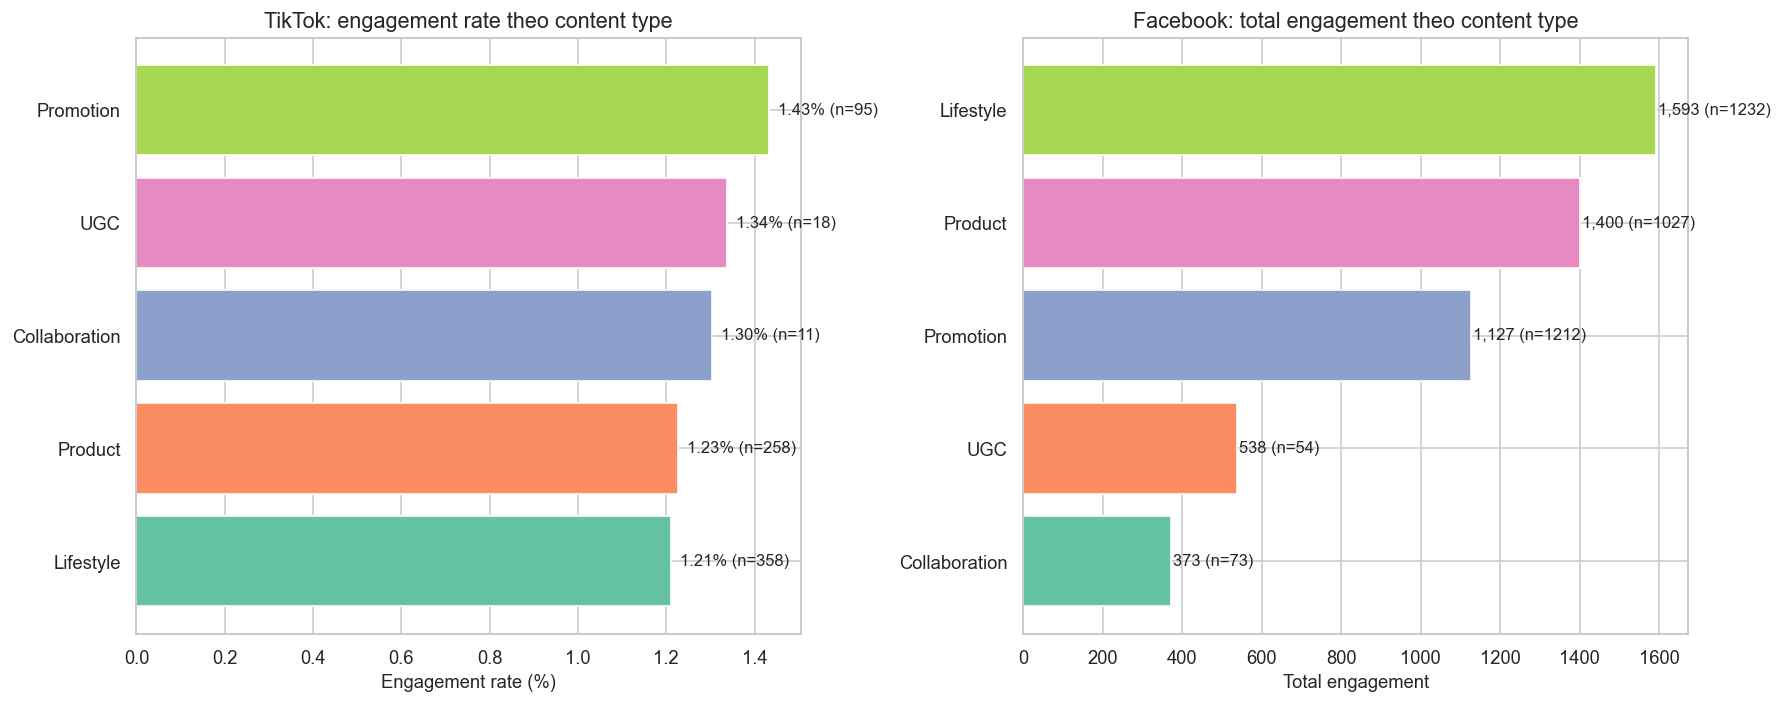

In [95]:
# Cell 20: Engagement theo content type — TikTok

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# TikTok: engagement rate theo content type
ct_eng = df_tiktok.groupby("content_type")["engagement_rate"].agg(["mean", "median", "count"])
ct_eng = ct_eng.sort_values("mean", ascending=True)
ax = axes[0]
bars = ax.barh(ct_eng.index, ct_eng["mean"], color=sns.color_palette("Set2", len(ct_eng)))
for bar, (_, row) in zip(bars, ct_eng.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{row["mean"]:.2f}% (n={int(row["count"])})', va="center", fontsize=10)
ax.set_title("TikTok: engagement rate theo content type")
ax.set_xlabel("Engagement rate (%)")

# Facebook: total engagement theo content type
ct_fb = df_facebook.groupby("content_type")["total_engagement"].agg(["mean", "median", "count"])
ct_fb = ct_fb.sort_values("mean", ascending=True)
ax = axes[1]
bars = ax.barh(ct_fb.index, ct_fb["mean"], color=sns.color_palette("Set2", len(ct_fb)))
for bar, (_, row) in zip(bars, ct_fb.iterrows()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{row["mean"]:,.0f} (n={int(row["count"])})', va="center", fontsize=10)
ax.set_title("Facebook: total engagement theo content type")
ax.set_xlabel("Total engagement")

plt.tight_layout()
plt.show()

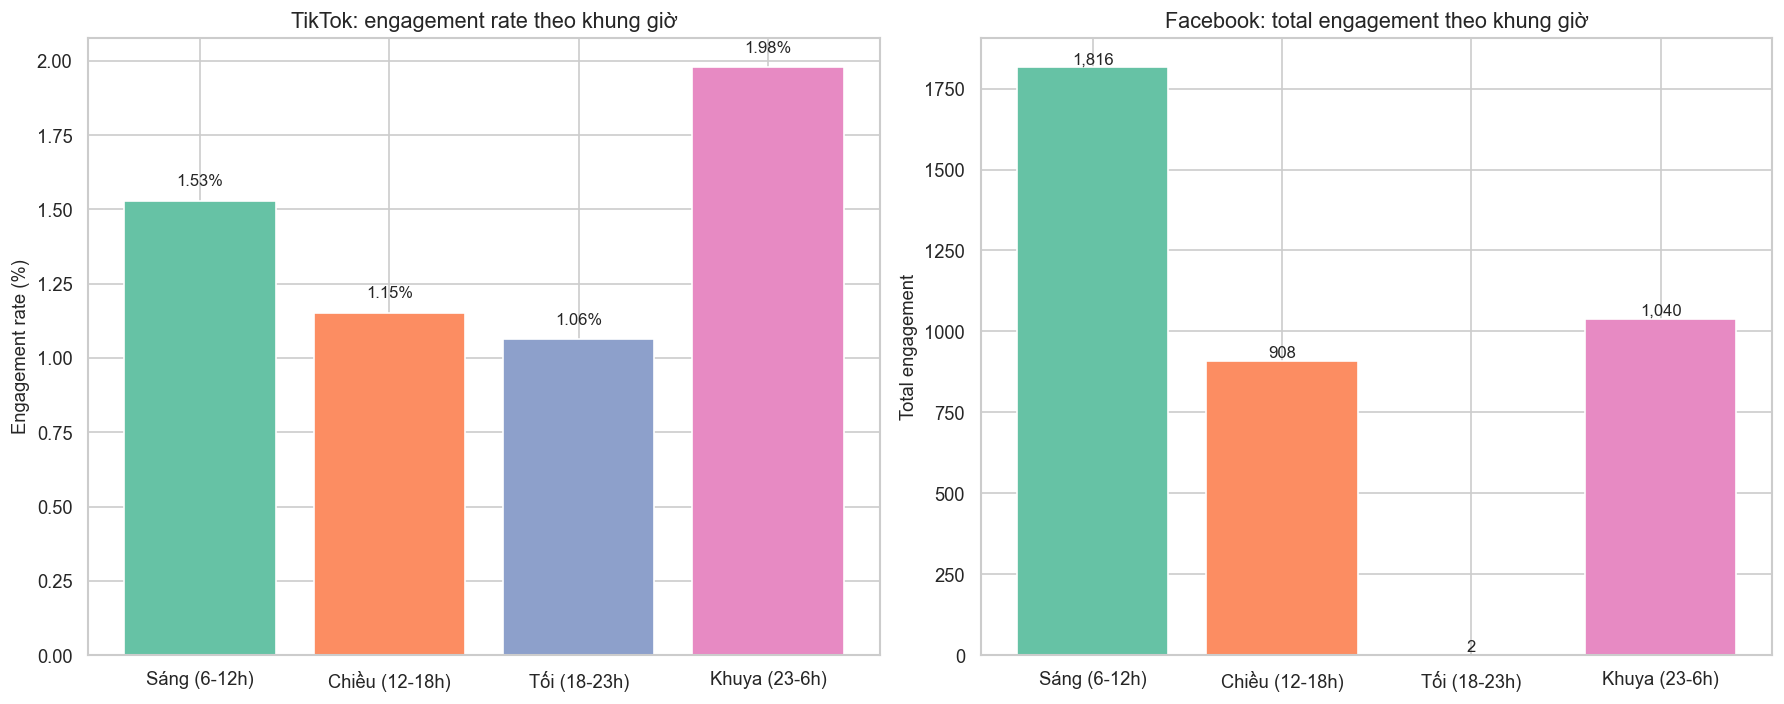

In [96]:
# Cell 21: Engagement theo khung giờ

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

time_order = ["Sáng (6-12h)", "Chiều (12-18h)", "Tối (18-23h)", "Khuya (23-6h)"]

# TikTok
tt_time = df_tiktok.groupby("time_category")["engagement_rate"].mean()
tt_time = tt_time.reindex(time_order).dropna()
axes[0].bar(tt_time.index, tt_time.values, color=sns.color_palette("Set2", len(tt_time)))
for i, v in enumerate(tt_time.values):
    axes[0].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=10)
axes[0].set_title("TikTok: engagement rate theo khung giờ")
axes[0].set_ylabel("Engagement rate (%)")

# Facebook
fb_time = df_facebook.groupby("time_category")["total_engagement"].mean()
fb_time = fb_time.reindex(time_order).dropna()
axes[1].bar(fb_time.index, fb_time.values, color=sns.color_palette("Set2", len(fb_time)))
for i, v in enumerate(fb_time.values):
    axes[1].text(i, v + 10, f"{v:,.0f}", ha="center", fontsize=10)
axes[1].set_title("Facebook: total engagement theo khung giờ")
axes[1].set_ylabel("Total engagement")

plt.tight_layout()
plt.show()

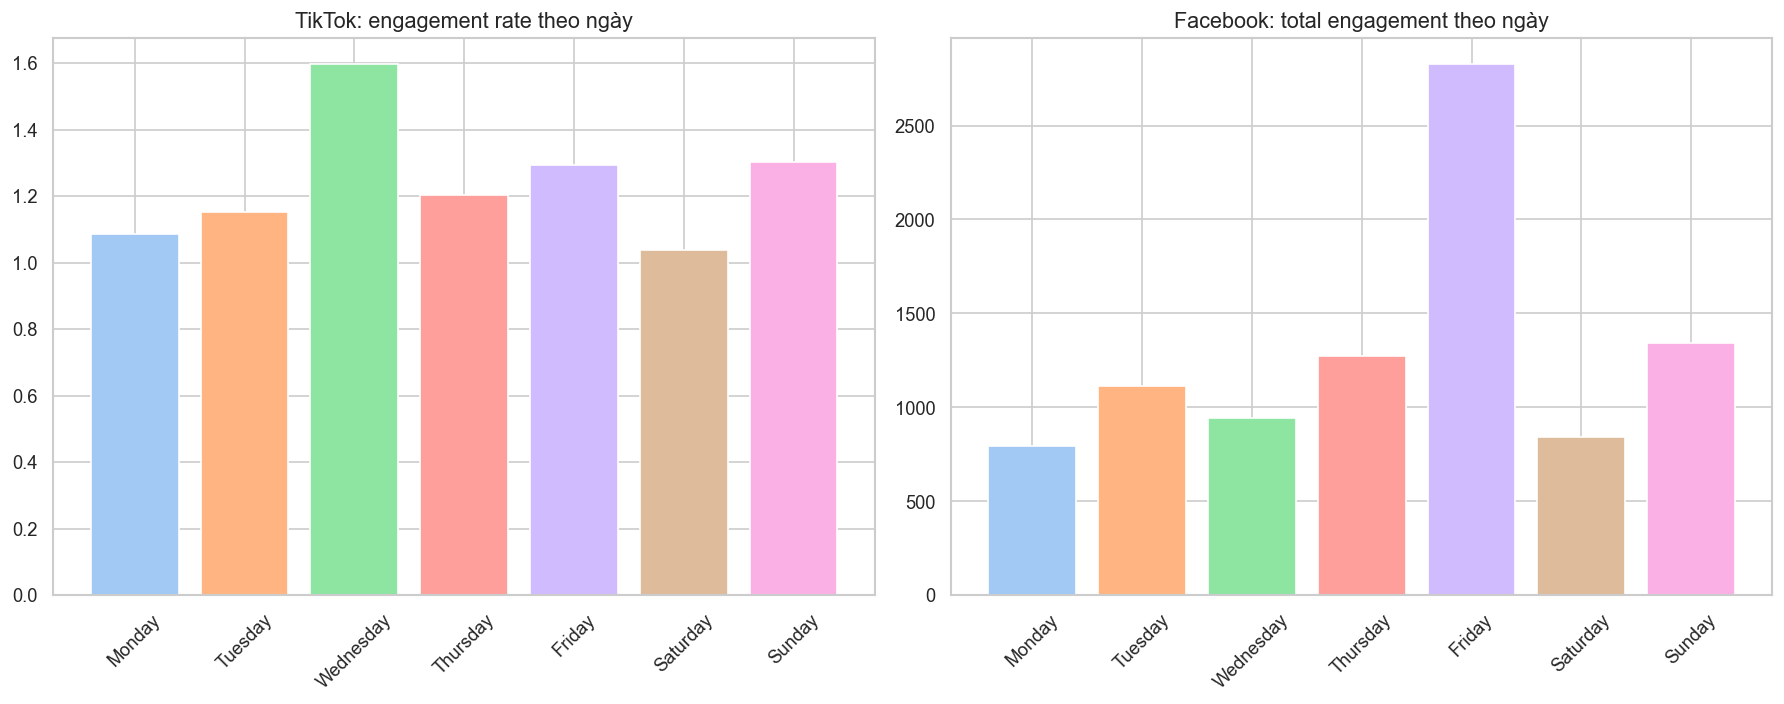

In [97]:
# Cell 22: Engagement theo ngày trong tuần

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# TikTok
tt_day = df_tiktok.groupby("day_of_week")["engagement_rate"].mean()
tt_day = tt_day.reindex(day_order).dropna()
axes[0].bar(tt_day.index, tt_day.values, color=sns.color_palette("pastel", len(tt_day)))
axes[0].set_title("TikTok: engagement rate theo ngày")
axes[0].tick_params(axis="x", rotation=45)

# Facebook
fb_day = df_facebook.groupby("day_of_week")["total_engagement"].mean()
fb_day = fb_day.reindex(day_order).dropna()
axes[1].bar(fb_day.index, fb_day.values, color=sns.color_palette("pastel", len(fb_day)))
axes[1].set_title("Facebook: total engagement theo ngày")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

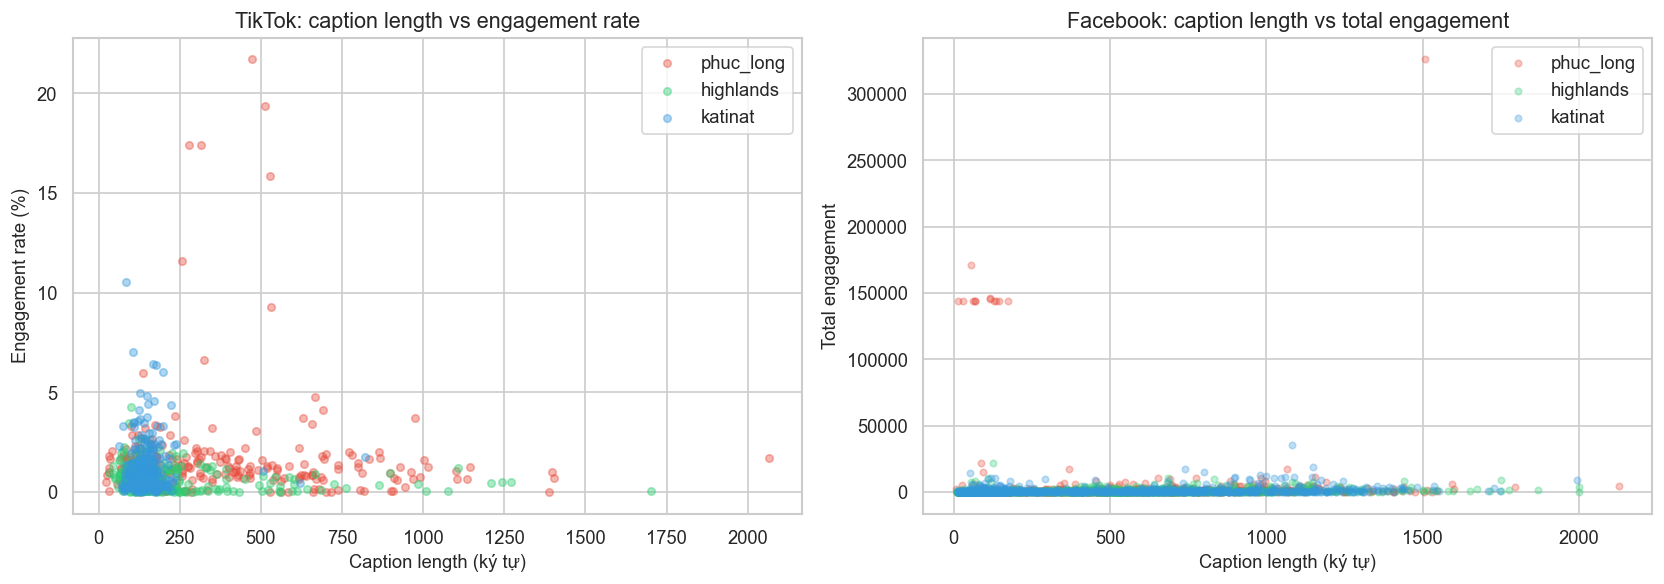

In [98]:
# Cell 23: Scatter — caption length vs engagement

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"phuc_long": "#e74c3c", "highlands": "#2ecc71", "katinat": "#3498db"}

# TikTok
for brand in ["phuc_long", "highlands", "katinat"]:
    d = df_tiktok[df_tiktok["brand"] == brand]
    axes[0].scatter(d["caption_length"], d["engagement_rate"],
                    alpha=0.4, s=20, label=brand, color=colors[brand])
axes[0].set_title("TikTok: caption length vs engagement rate")
axes[0].set_xlabel("Caption length (ký tự)")
axes[0].set_ylabel("Engagement rate (%)")
axes[0].legend()

# Facebook
for brand in ["phuc_long", "highlands", "katinat"]:
    d = df_facebook[df_facebook["brand"] == brand]
    axes[1].scatter(d["caption_length"], d["total_engagement"],
                    alpha=0.3, s=15, label=brand, color=colors[brand])
axes[1].set_title("Facebook: caption length vs total engagement")
axes[1].set_xlabel("Caption length (ký tự)")
axes[1].set_ylabel("Total engagement")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.1. Tổng quan cơ sở khoa học & Phương pháp luận

### 6.1.1. Sự cần thiết của quy trình gán nhãn lai (Hybrid Labeling)
Trong các bài toán phân tích cảm xúc trên mạng xã hội, dữ liệu thường bị nhiễu lớn bởi teencode, từ viết tắt, tiếng lóng (slang), và cấu trúc câu phức tạp (ví dụ: châm biếm, phủ định kép). Việc sử dụng hoàn toàn nhãn do AI gán nhãn tự động (ví dụ qua LLM lớn) dễ gặp hiện tượng lệch (bias) hoặc đánh giá sai ngữ cảnh chuyên biệt của ngành F&B. Vì vậy, áp dụng quy trình gán nhãn lai (Hybrid Labeling) - kết hợp thế mạnh lọc diện rộng của LLM và sự kiểm định chuẩn xác của con người (Human-in-the-loop) theo framework của Artemova et al. (2025) - là vô cùng cần thiết để đảm bảo tính khách quan học thuật và chất lượng dữ liệu huấn luyện.

### 6.1.2. Mô hình ngôn ngữ lớn học sâu ViSoBERT
ViSoBERT (UIT-NLP) là mô hình ngôn ngữ dựa trên kiến trúc BERT được tiền huấn luyện chuyên biệt trên dữ liệu mạng xã hội tiếng Việt. Mô hình này vượt trội hơn các mô hình ngôn ngữ chung ở chỗ có khả năng hiểu sâu các từ viết tắt, teencode, icon cảm xúc và văn phong không chính thức của giới trẻ Việt Nam trên Facebook và TikTok.

### 6.1.3. Phương pháp thích ứng cấp thấp (LoRA - Low-Rank Adaptation)
Thay vì huấn luyện toàn bộ mô hình (Full Fine-tuning) rất nặng và tốn tài nguyên phần cứng, phương pháp LoRA (Duong & Hoan, 2026) đóng băng trọng số gốc của ViSoBERT và chỉ cập nhật một lượng nhỏ tham số trong các ma trận thích ứng cấp thấp (Low-Rank Matrices) được chèn vào các lớp Attention. Điều này giúp pipeline chạy cực kỳ nhẹ, không quá màng (overfitting) và tối ưu hóa tốc độ huấn luyện trên CPU.

## 6.2. Thiết kế hệ thống học máy

### 6.2.1. Đóng băng tham số mô hình nền
Đóng băng toàn bộ trọng số gốc của mô hình ViSoBERT giúp giữ nguyên tri thức ngôn ngữ mạng xã hội đã học trước đó, tránh hiện tượng "quên lãng thảm họa" (catastrophic forgetting).

### 6.2.2. Cơ chế chèn adapter
Các ma trận LoRA Adapter với hạng (Rank) $r=8$ và hệ số tỉ lệ $\alpha=32$ được chèn trực tiếp vào các lớp Self-Attention (query, value). Số lượng tham số cần huấn luyện giảm xuống chỉ còn khoảng 0.90%, giúp mô hình tinh chỉnh nhanh chóng trên dữ liệu đặc thù của 3 thương hiệu.

### 6.2.3. Sơ đồ kiến trúc Pipeline gán nhãn lai và huấn luyện

Đang tạo sơ đồ Pipeline gán nhãn lai & huấn luyện...
✅ Sơ đồ Pipeline đã lưu: ../data/sentiment_data\pipeline_flowchart.png


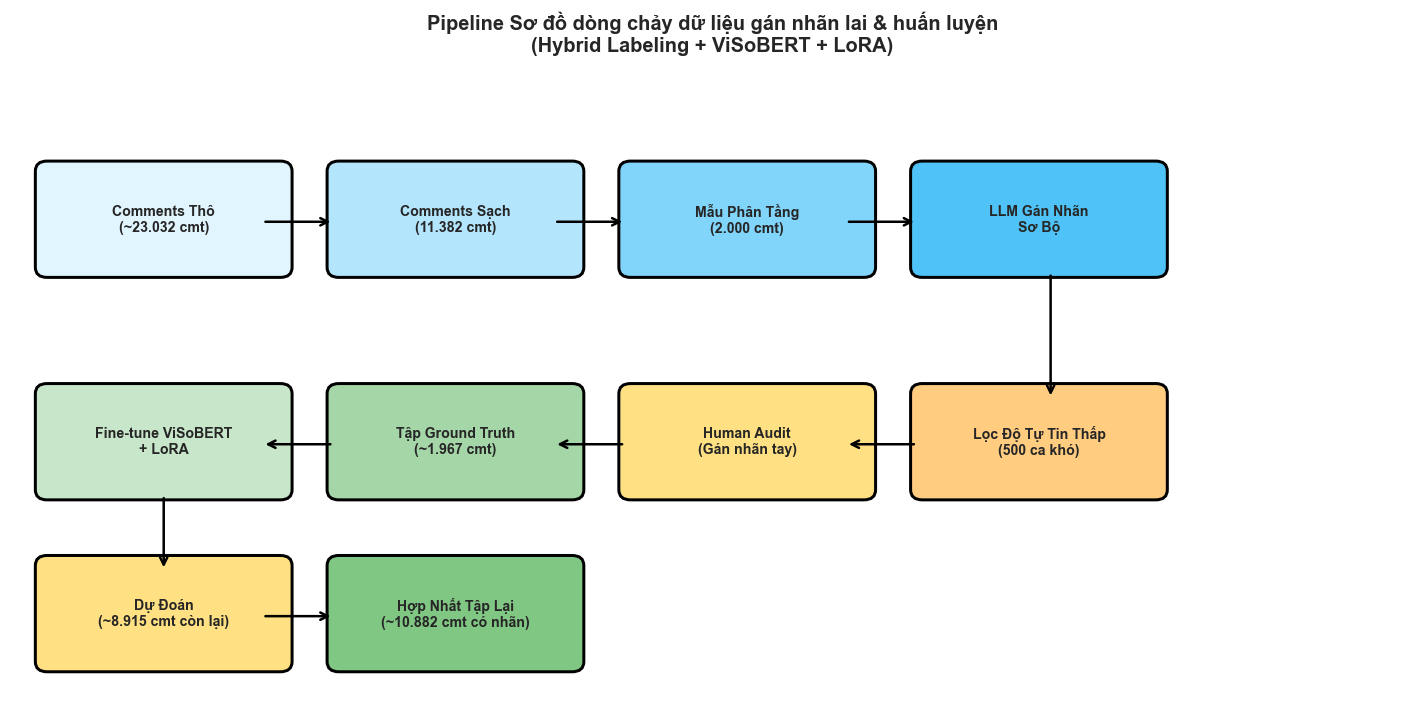

In [10]:
# ====================== 6.2.3. SƠ ĐỒ KIẾN TRÚC PIPELINE (DATA FLOW DIAGRAM) ======================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os  # Thêm dòng này vào đầu cell

print("Đang tạo sơ đồ Pipeline gán nhãn lai & huấn luyện...")

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')

def draw_box(ax, x, y, w, h, text, color):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", 
                                  linewidth=1.8, edgecolor="black", facecolor=color)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", 
            fontsize=8.5, fontweight="bold", wrap=True)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.5, shrinkA=5, shrinkB=5))

# Cập nhật số liệu theo thực tế hiện tại
draw_box(ax, 0.3, 4.2, 2.0, 0.95, "Comments Thô\n(~23.032 cmt)", "#e1f5fe")
draw_box(ax, 2.8, 4.2, 2.0, 0.95, "Comments Sạch\n(11.382 cmt)", "#b3e5fc")
draw_box(ax, 5.3, 4.2, 2.0, 0.95, "Mẫu Phân Tầng\n(2.000 cmt)", "#81d4fa")
draw_box(ax, 7.8, 4.2, 2.0, 0.95, "LLM Gán Nhãn\nSơ Bộ", "#4fc3f7")

draw_box(ax, 7.8, 2.0, 2.0, 0.95, "Lọc Độ Tự Tin Thấp\n(500 ca khó)", "#ffcc80")
draw_box(ax, 5.3, 2.0, 2.0, 0.95, "Human Audit\n(Gán nhãn tay)", "#ffe082")
draw_box(ax, 2.8, 2.0, 2.0, 0.95, "Tập Ground Truth\n(~1.967 cmt)", "#a5d6a7")
draw_box(ax, 0.3, 2.0, 2.0, 0.95, "Fine-tune ViSoBERT\n+ LoRA", "#c8e6c9")

draw_box(ax, 0.3, 0.3, 2.0, 0.95, "Dự Đoán\n(~8.915 cmt còn lại)", "#ffe082")
draw_box(ax, 2.8, 0.3, 2.0, 0.95, "Hợp Nhất Tập Lại\n(~10.882 cmt có nhãn)", "#81c784")

# Các mũi tên
draw_arrow(ax, 2.1, 4.65, 2.8, 4.65)
draw_arrow(ax, 4.6, 4.65, 5.3, 4.65)
draw_arrow(ax, 7.1, 4.65, 7.8, 4.65)
draw_arrow(ax, 8.9, 4.2, 8.9, 2.85)
draw_arrow(ax, 7.8, 2.45, 7.1, 2.45)
draw_arrow(ax, 5.3, 2.45, 4.6, 2.45)
draw_arrow(ax, 2.8, 2.45, 2.1, 2.45)
draw_arrow(ax, 1.3, 2.0, 1.3, 1.15)
draw_arrow(ax, 2.1, 0.75, 2.8, 0.75)

plt.title('Pipeline Sơ đồ dòng chảy dữ liệu gán nhãn lai & huấn luyện\n'
          '(Hybrid Labeling + ViSoBERT + LoRA)', 
          fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'pipeline_flowchart.png')
plt.savefig(save_path, dpi=200, facecolor='white', bbox_inches='tight')
print(f"✅ Sơ đồ Pipeline đã lưu: {save_path}")

plt.show()

## 6.3. Dữ liệu bình luận TikTok và Facebook

### 6.3.1. Quy mô dữ liệu comments theo nền tảng và thương hiệu

Tổng số bình luận thô ban đầu: 23,032

Bảng Pivot Table số lượng bình luận theo thương hiệu và nền tảng:
platform   Facebook  TikTok
brand                      
highlands      5044    5453
katinat        4014    2618
phuc_long      3858    2045


<Figure size 960x600 with 0 Axes>

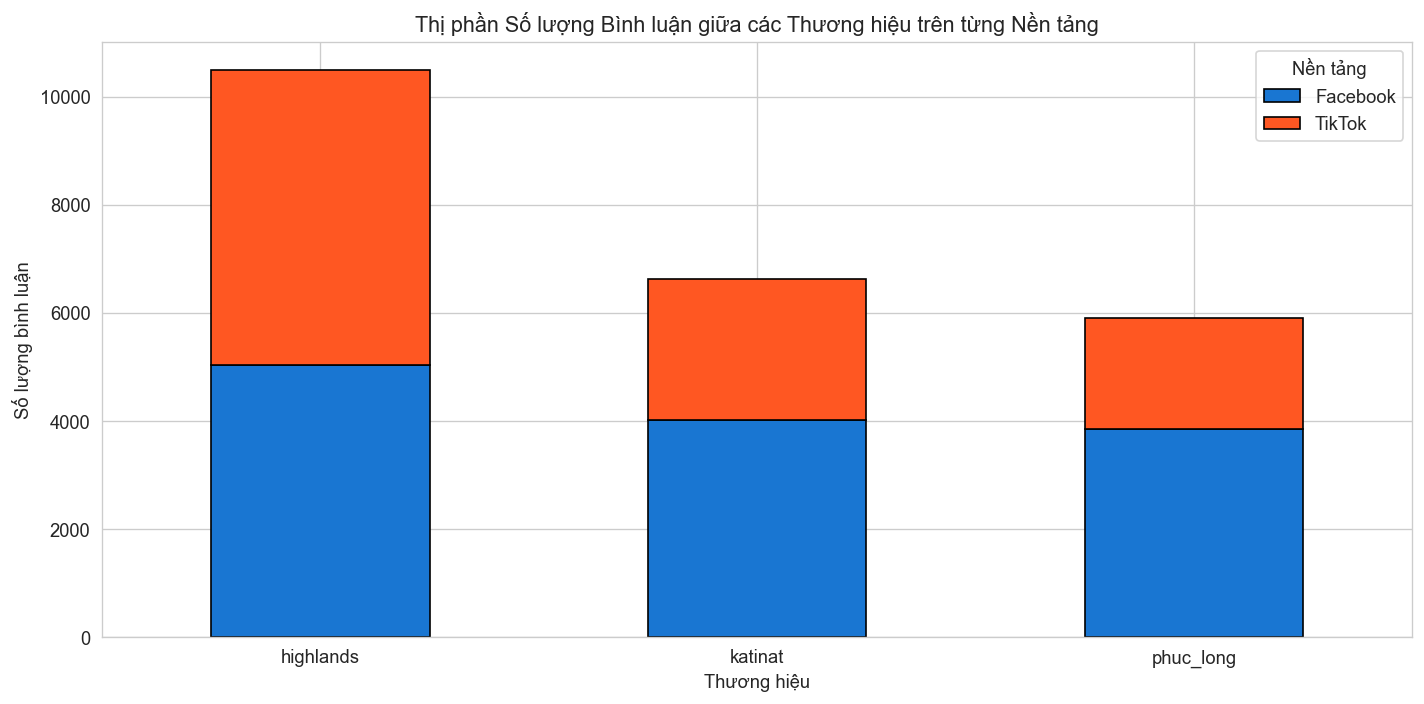

In [11]:
# ====================== 6.3.1. THỐNG KÊ QUY MÔ BÌNH LUẬN ======================
import pandas as pd
import matplotlib.pyplot as plt

# Gộp dữ liệu bình luận từ hai nền tảng
df_tt_comments = df_tiktok_comments.copy()
df_fb_comments = df_facebook_comments.copy()

df_tt_comments['platform'] = 'TikTok'
df_fb_comments['platform'] = 'Facebook'

# Đồng bộ cột tên người dùng để lọc admin chính xác
df_tt_comments['user_name'] = df_tt_comments['user_nickname']
df_fb_comments['user_name'] = df_fb_comments['user_name']

common_cols = ['comment_id', 'brand', 'comment_text', 'like_count', 'create_time', 'platform', 'user_name']
df_all_comments = pd.concat([
    df_tt_comments[common_cols],
    df_fb_comments[common_cols]
], ignore_index=True)

print(f"Tổng số bình luận thô ban đầu: {len(df_all_comments):,}")

# Bảng Pivot table số lượng comment của 3 thương hiệu chia theo 2 kênh
pivot_table = pd.crosstab(df_all_comments['brand'], df_all_comments['platform'])
print("\nBảng Pivot Table số lượng bình luận theo thương hiệu và nền tảng:")
print(pivot_table)

# Vẽ biểu đồ cột chồng
plt.figure(figsize=(8, 5))
pivot_table.plot(kind='bar', stacked=True, color=['#1976d2', '#ff5722'], edgecolor='black')
plt.title('Thị phần Số lượng Bình luận giữa các Thương hiệu trên từng Nền tảng')
plt.xlabel('Thương hiệu')
plt.ylabel('Số lượng bình luận')
plt.xticks(rotation=0)
plt.legend(title='Nền tảng')
plt.tight_layout()
plt.savefig('stacked_bar_brand_platform.png', dpi=150)
plt.show()

=== BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU BÌNH LUẬN ===

Tổng số bình luận phân tích: 23,032
Bình luận thiếu nội dung (Missing): 0 (0.00%)
Bình luận trùng lặp nội dung (Duplicate): 573 (2.49%)
Bình luận quá ngắn (độ dài < 5 kí tự - spam): 236 (1.02%)


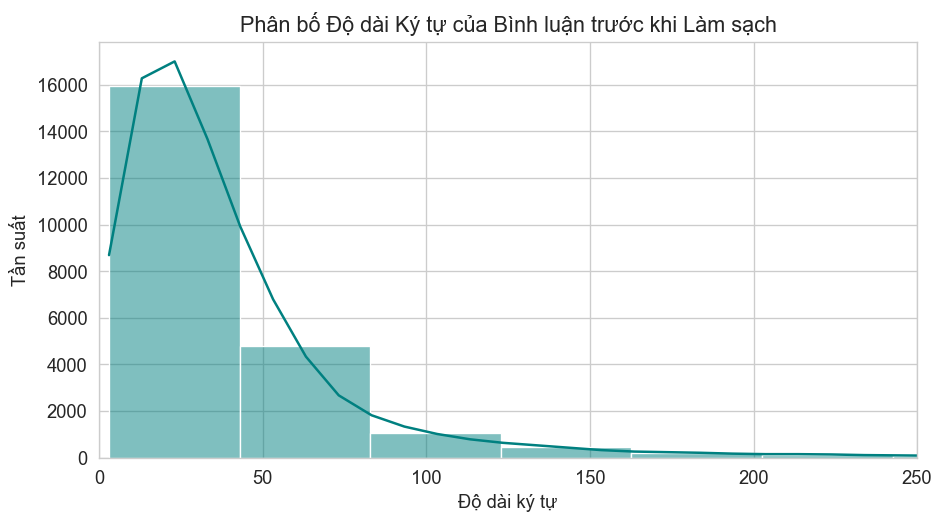

In [12]:
# ====================== 6.3.2. KIỂM TRA LỖI, DUPLICATE, SPAM & MISSING ======================
print("=== BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU BÌNH LUẬN ===\n")

total_comments = len(df_all_comments)
missing_values = df_all_comments['comment_text'].isnull().sum()
duplicate_values = df_all_comments.duplicated(subset=['comment_text']).sum()

df_all_comments['text_length'] = df_all_comments['comment_text'].fillna("").astype(str).apply(len)
spam_candidates = (df_all_comments['text_length'] < 5).sum()

print(f"Tổng số bình luận phân tích: {total_comments:,}")
print(f"Bình luận thiếu nội dung (Missing): {missing_values} ({missing_values / total_comments * 100:.2f}%)")
print(f"Bình luận trùng lặp nội dung (Duplicate): {duplicate_values:,} ({duplicate_values / total_comments * 100:.2f}%)")
print(f"Bình luận quá ngắn (độ dài < 5 kí tự - spam): {spam_candidates:,} ({spam_candidates / total_comments * 100:.2f}%)")

# Vẽ biểu đồ phân bố độ dài ký tự
import seaborn as sns
plt.figure(figsize=(8, 4.5))
sns.histplot(df_all_comments['text_length'], bins=50, color='teal', kde=True)
plt.title('Phân bố Độ dài Ký tự của Bình luận trước khi Làm sạch')
plt.xlabel('Độ dài ký tự')
plt.ylabel('Tần suất')
plt.xlim(0, 250)
plt.tight_layout()
plt.savefig('comments_length_histogram.png', dpi=150)
plt.show()

### 6.3.3. Tiêu chí chọn comments đưa vào mô hình NLP

Để đảm bảo chất lượng huấn luyện cho mô hình ngôn ngữ ViSoBERT, chúng ta áp dụng các điều kiện lọc chặt chẽ:
1.  **Độ dài tối thiểu**: Bình luận phải chứa ít nhất 3 từ và độ dài ký tự tối thiểu là 10 ký tự, ngoại trừ các từ khóa mang cảm xúc ngắn rõ ràng (ví dụ: "ngon", "tệ", "ổn").
2.  **Loại bỏ Seeding & Quảng cáo**: Loại bỏ các bình luận của chính thương hiệu (admin tương tác chăm sóc khách hàng), tin tuyển dụng, follow chéo, hoặc copy-paste các coupon khuyến mãi dài.
3.  **Loại bỏ tag rác**: Loại bỏ các bình luận chỉ chứa tên tag người dùng khác mà không có bất kỳ nội dung nhận xét thực tế nào.

## 6.4. Tiền xử lý văn bản tiếng Việt và Rút mẫu phân tầng

### 6.4.1. Làm sạch cơ bản và chuẩn hóa Teencode

In [13]:
# ====================== 6.4.1. LÀM SẠCH CƠ BẢN VÀ CHUẨN HÓA TEENCODE ======================
import re
import pandas as pd
from IPython.display import display

print("="*70)
print("6.4.1 - LÀM SẠCH CƠ BẢN VÀ CHUẨN HÓA TEENCODE")
print("="*70)

# Dictionary Teencode & viết tắt phổ biến trong F&B
TEENCODE_DICT = {
    "ko": "không", "k": "không", "khg": "không", "kh": "không", "kg": "không",
    "ok": "tốt", "oke": "tốt", "okela": "tốt", "oki": "tốt",
    "vs": "với", "gđ": "gia đình", "đc": "được", "dc": "được",
    "ib": "nhắn tin", "zalo": "điện thoại", "z": "vậy", "zay": "vậy",
    "pl": "phúc_long", "hl": "highlands", "kt": "katinat",
    "ts": "trà_sữa", " trà_sữa": "trà_sữa"
}

def clean_and_normalize_vietnamese(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower().strip()
    
    # Remove URLs
    url_pattern = r'http\S+|www\.\S+'
    text = re.sub(url_pattern, '', text)
    
    # Standardize brand & common phrases
    text = text.replace("trà sữa", "trà_sữa")
    text = text.replace("phúc long", "phúc_long")
    text = text.replace("phuclong", "phúc_long")
    text = text.replace("highlands coffee", "highlands")
    text = text.replace("highland coffee", "highlands")
    
    # Replace teencode
    words = text.split()
    words_norm = [TEENCODE_DICT.get(w, w) for w in words]
    text = " ".join(words_norm)
    
    # Giữ lại chữ cái tiếng Việt, dấu cách và underscore
    text = re.sub(r'[^a-zA-ZáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđĐ\s_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Kiểm tra cột tồn tại
if 'comment_text' not in df_all_comments.columns:
    raise KeyError("Cột 'comment_text' không tồn tại trong df_all_comments!")

print(f"[INFO] Bắt đầu làm sạch cơ bản và chuẩn hoá teencode...")
print(f"Số lượng bình luận cần xử lý: {len(df_all_comments):,}")

# Áp dụng hàm làm sạch
df_all_comments['clean_text'] = df_all_comments['comment_text'].apply(clean_and_normalize_vietnamese)

print(f"✅ Hoàn thành làm sạch cho {len(df_all_comments):,} bình luận.")

# Hiển thị mẫu so sánh
print("\n--- 5 mẫu bình luận gốc và sau khi chuẩn hoá ---")
display(df_all_comments[['comment_text', 'clean_text']].head(5))

# Thống kê độ dài sau khi clean
df_all_comments['clean_text_length'] = df_all_comments['clean_text'].str.len()
print(f"\nĐộ dài trung bình sau khi làm sạch: {df_all_comments['clean_text_length'].mean():.1f} ký tự")

6.4.1 - LÀM SẠCH CƠ BẢN VÀ CHUẨN HÓA TEENCODE
[INFO] Bắt đầu làm sạch cơ bản và chuẩn hoá teencode...
Số lượng bình luận cần xử lý: 23,032
✅ Hoàn thành làm sạch cho 23,032 bình luận.

--- 5 mẫu bình luận gốc và sau khi chuẩn hoá ---


,comment_text,clean_text
0,tui uống trà sữa PL chắc cũng mấy năm rồi á,tui uống trà_sữa phúc_long chắc cũng mấy năm r...
1,bánh nhìn hấp dẫn z,bánh nhìn hấp dẫn vậy
2,cà phê sữa bên này dễ uống á,cà phê sữa bên này dễ uống á
3,Lịch trình này nên đưa vào sách giáo khoa cho ...,lịch trình này nên đưa vào sách giáo khoa cho ...
4,sandwich nhìn nhỏ mà ăn cũng ok,sandwich nhìn nhỏ mà ăn cũng tốt



Độ dài trung bình sau khi làm sạch: 41.6 ký tự


### 6.4.2. Tách từ tiếng Việt bằng Underthesea

In [14]:
# ====================== 6.4.2. TÁCH TỪ TIẾNG VIỆT ======================
from underthesea import word_tokenize
from IPython.display import display

print("="*70)
print("6.4.2 - TÁCH TỪ TIẾNG VIỆT BẰNG UNDERTHESEA")
print("="*70)

# Kiểm tra cột clean_text có tồn tại không
if 'clean_text' not in df_all_comments.columns:
    print("❌ LỖI: Cột 'clean_text' chưa tồn tại!")
    print("   → Vui lòng chạy cell 6.4.1 trước khi chạy cell này.")
    raise KeyError("Cột 'clean_text' không tìm thấy.")

print(f"[INFO] Bắt đầu tách từ bằng Underthesea...")
num_comments = len(df_all_comments)
print(f"Số lượng bình luận cần tách từ: {num_comments:,}")

# Thực hiện tách từ
df_all_comments['tokenized_text'] = df_all_comments['clean_text'].apply(
    lambda x: word_tokenize(x, format="text")
)

print(f"✅ Hoàn thành tách từ cho {num_comments:,} bình luận.")

# Hiển thị mẫu so sánh
print("\n--- 5 mẫu bình luận sau khi tách từ ---")
display(df_all_comments[['clean_text', 'tokenized_text']].head(5))

# Thống kê bổ sung
df_all_comments['token_count'] = df_all_comments['tokenized_text'].astype(str).apply(lambda x: len(x.split()))
print(f"\nThống kê số từ trung bình sau tách: {df_all_comments['token_count'].mean():.2f} từ/bình luận")
print(f"Số từ tối thiểu: {df_all_comments['token_count'].min()} | Số từ tối đa: {df_all_comments['token_count'].max()}")

# Lưu tạm checkpoint (tùy chọn)
df_all_comments.to_csv("../data/sentiment_data/comments_after_tokenization.csv", 
                       index=False, encoding="utf-8-sig")
print("✅ Đã lưu checkpoint sau khi tách từ.")

6.4.2 - TÁCH TỪ TIẾNG VIỆT BẰNG UNDERTHESEA
[INFO] Bắt đầu tách từ bằng Underthesea...
Số lượng bình luận cần tách từ: 23,032
✅ Hoàn thành tách từ cho 23,032 bình luận.

--- 5 mẫu bình luận sau khi tách từ ---


,clean_text,tokenized_text
0,tui uống trà_sữa phúc_long chắc cũng mấy năm r...,tui uống trà_sữa phúc_long chắc cũng mấy năm r...
1,bánh nhìn hấp dẫn vậy,bánh nhìn hấp_dẫn vậy
2,cà phê sữa bên này dễ uống á,cà_phê sữa bên này dễ uống á
3,lịch trình này nên đưa vào sách giáo khoa cho ...,lịch_trình này nên đưa vào sách_giáo_khoa cho ...
4,sandwich nhìn nhỏ mà ăn cũng tốt,sandwich nhìn nhỏ mà ăn cũng tốt



Thống kê số từ trung bình sau tách: 7.69 từ/bình luận
Số từ tối thiểu: 0 | Số từ tối đa: 259
✅ Đã lưu checkpoint sau khi tách từ.


### 6.4.3. Lọc nhiễu nâng cao (Advanced Comment Filtering)

In [15]:
# ====================== 6.4.3. LỌC NHIỄU NÂNG CAO ======================
import re
import pandas as pd

def advanced_filter_comments(df):
    initial_count = len(df)
    
    # 1. Commenter Filtering: Chỉ lọc bình luận của chính tài khoản Admin thương hiệu để tránh mất so sánh người dùng
    admin_nicknames = ['phuclongofficial', 'highlandscoffeevietnam', 'katinatvn', 'Highlands Coffee', 'KATINAT']
    is_admin = df['user_name'].astype(str).isin(admin_nicknames)
    
    # Lọc bài đăng hoặc thông báo mang tính chất seeding/admin cứng
    brand_content_patterns = [
        r'thẻ thành viên\b', r'tải app\b', r'app phúc long\b', r'đơn hàng\b',
        r'hệ thống cửa hàng\b', r'chi nhánh\b', r'điều kiện và điều khoản\b'
    ]
    is_admin_content = df['comment_text'].astype(str).str.lower().str.contains('|'.join(brand_content_patterns), na=False)
    
    is_brand = is_admin | is_admin_content
    df_filtered = df[~is_brand].copy()
    commenter_filtered = initial_count - len(df_filtered)
    
    # 2. Spam & Ads Detection: Lọc quảng cáo, việc làm (chỉ lọc khi không chứa từ khóa cảm xúc)
    spam_keywords = [
        'tuyển', 'việc làm', 'nhân sự', 'thu nhập', 'lương', 'fulltime', 'parttime', 
        'inbox để biết', 'liên hệ zalo', 'sđt', 'freelance', 'kiếm tiền', 'chiết khấu',
        'freeship', 'đăng ký nhận', 'nhận ngay', 'cơ hội trúng', 'vòng quay may mắn',
        'deal', 'flash sale', 'combo', 'ưu đãi', 'khuyến mãi', 'đặt ngay', 'chốt đơn',
        'mã giảm giá', 'voucher', 'coupon', 'săn deal', 'khao', 'tặng', 'miễn phí',
        'flashdeal', '1 brew', 'mua 2 tặng 1', 'mua 1 tặng 1', 'giảm giá', 'sale', 'fl chéo', 'follow chéo', 'fl hộ', 'follow hộ', 'tương tác chéo', 'chéo fl'
    ]
    sentiment_keywords = ['ngon', 'dở', 'tệ', 'hay', 'đẹp', 'tuyệt', 'chán', 'thích', 'ghét', 'ok', 'ổn', 'quá đã', 'tốt', 'yêu', 'đỉnh', 'dịch vụ']
    
    has_sentiment = df_filtered['clean_text'].astype(str).apply(lambda x: any(kw in x for kw in sentiment_keywords))
    is_spam_keyword = df_filtered['clean_text'].astype(str).str.contains('|'.join(spam_keywords), na=False)
    is_spam = is_spam_keyword & (~has_sentiment)
    
    df_filtered = df_filtered[~is_spam].copy()
    spam_filtered = initial_count - commenter_filtered - len(df_filtered)
    
    # 3. Hate/Offensive Content: Lọc bình luận độc hại, thô tục
    toxic_keywords = [
        'đm', 'đéo', 'chửi', 'lồn', 'cặc', 'ngu', 'mẹ mày', 'óc chó', 
        'khốn nạn', 'đĩ', 'hãm', 'rác rưởi', 'bẩn thỉu', 'vcl', 'vkl', 'clm', 'dkm', 'đkm'
    ]
    is_toxic = df_filtered['clean_text'].astype(str).str.contains('|'.join(toxic_keywords), na=False)
    df_filtered = df_filtered[~is_toxic].copy()
    toxic_filtered = initial_count - commenter_filtered - spam_filtered - len(df_filtered)
    
    # 4. Length-based Filtering: Lọc bình luận quá ngắn nhưng giữ lại từ khóa cảm xúc ngắn có nghĩa
    is_short = ((df_filtered['clean_text'].astype(str).str.len() < 10) | \
                (df_filtered['clean_text'].astype(str).str.split().str.len() < 3)) & \
               (~df_filtered['clean_text'].astype(str).isin(sentiment_keywords))
    df_filtered = df_filtered[~is_short].copy()
    length_filtered = initial_count - commenter_filtered - spam_filtered - toxic_filtered - len(df_filtered)
    
    # 5. Advanced Noise Filtering
    def is_noise(row):
        comment = str(row['comment_text'])
        clean = str(row['clean_text']).lower()
        comment_lower = comment.lower()
        
        system_patterns = [
            r'tất cả cảm cảm xúc', r'tất cả cảm xúc', r'lượt chia sẻ', r'bình luận', r'đã chia sẻ với công khai',
            r'\d+ tháng \d+', r'\d+ ngày trước', r'\d+ tuần', r'lúc \d{1,2}[\: ]\d{2}',
            r'xem tất cả \d+ phản hồi', r'phản hồi', r'chia sẻ'
        ]
        for pat in system_patterns:
            if re.search(pat, comment_lower):
                return True
                
        if re.search(r'(\d{4,})', clean) and len(clean.split()) < 5:
            return True
            
        if not re.search(r'[\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', clean):
            return True
            
        if len(comment.split()) < 6:
            capitalized_words = re.findall(r'\b[A-ZÁÀẢÃẠĂẮẰ¼ẮẶÂẤẦẨẪẬÉÈẺẼẸÊẾỀỂỄỆÍÌỈĨỊÓÒỎÕỌÔỐỒỔỖỘƠỚỜỞỠỢÚÙỦŨỤƯỨỪỬỮỰÝỲỶỸỴĐ][a-záàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]*\b', comment)
            if len(capitalized_words) >= 2:
                return True
                
        if re.search(r'\btuần\s*\d+', comment_lower) and len(clean.split()) < 20:
            if not any(kw in clean for kw in sentiment_keywords):
                return True
                
        if len(clean) > 200 and (clean.count('.') > 3 or clean.count(',') > 5):
            return True
            
        caption_keywords = ['mời bạn', 'ghé ngay', 'chính thức ra mắt', 'hẹn gặp', 'tham gia', 'chương trình', 'chính thức khoác áo mới', 'mùa hè của tằm']
        if any(kw in comment_lower for kw in caption_keywords) and len(clean) > 150:
            return True
            
        alpha_words = re.findall(r'[a-zA-ZáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđĐ]+', clean)
        if len(alpha_words) == 0:
            return True
            
        if len(alpha_words) < 3 and not any(kw in clean for kw in sentiment_keywords):
            return True
            
        if re.search(r'[\U0001D400-\U0001D7FF]', comment) or 'y then y then' in clean:
            return True
            
        return False
        
    is_noise_row = df_filtered.apply(is_noise, axis=1)
    df_filtered = df_filtered[~is_noise_row].copy()
    noise_filtered = initial_count - commenter_filtered - spam_filtered - toxic_filtered - length_filtered - len(df_filtered)
    
    print("=== BÁO CÁO LỌC NÂNG CAO ===")
    print(f"Tổng bình luận ban đầu: {initial_count:,}")
    print(f"- Đã loại bỏ bình luận thương hiệu: -{commenter_filtered:,}")
    print(f"- Đã loại bỏ bình luận spam/quảng cáo: -{spam_filtered:,}")
    print(f"- Đã loại bỏ bình luận độc hại/thù ghét: -{toxic_filtered:,}")
    print(f"- Đã loại bỏ bình luận quá ngắn (đã chừa từ cảm xúc ngắn): -{length_filtered:,}")
    print(f"- Đã loại bỏ bình luận tag rác & nhiễu hệ thống & caption dài: -{noise_filtered:,}")
    print(f"Số bình luận sạch giữ lại: {len(df_filtered):,}")
    
    return df_filtered

# Gọi hàm lọc nâng cao
df_clean = advanced_filter_comments(df_all_comments)
print(f"\nSố bình luận sạch giữ lại sau lọc nâng cao: {len(df_clean):,}")

print("\nSo sánh trước và sau khi xử lý ngôn ngữ:")
for idx in [0, 10, 20]:
    if idx < len(df_all_comments):
        print(f"Gốc:  {df_all_comments.loc[idx, 'comment_text']}")
        print(f"Sạch: {df_all_comments.loc[idx, 'clean_text']}")
        print(f"Tách: {df_all_comments.loc[idx, 'tokenized_text'].split()}")
        print("-" * 40)

# Thêm vào CUỐI cell 6.4.3 (sau khi lọc xong)
df_clean.to_csv(
    "../data/sentiment_data/clean_comments.csv",
    index=False,
    encoding="utf-8-sig"
)
print(f"✅ Đã lưu clean_comments.csv với {len(df_clean):,} dòng")

=== BÁO CÁO LỌC NÂNG CAO ===
Tổng bình luận ban đầu: 23,032
- Đã loại bỏ bình luận thương hiệu: -314
- Đã loại bỏ bình luận spam/quảng cáo: -1,111
- Đã loại bỏ bình luận độc hại/thù ghét: -2,121
- Đã loại bỏ bình luận quá ngắn (đã chừa từ cảm xúc ngắn): -3,813
- Đã loại bỏ bình luận tag rác & nhiễu hệ thống & caption dài: -4,291
Số bình luận sạch giữ lại: 11,382

Số bình luận sạch giữ lại sau lọc nâng cao: 11,382

So sánh trước và sau khi xử lý ngôn ngữ:
Gốc:  tui uống trà sữa PL chắc cũng mấy năm rồi á
Sạch: tui uống trà_sữa phúc_long chắc cũng mấy năm rồi á
Tách: ['tui', 'uống', 'trà_sữa', 'phúc_long', 'chắc', 'cũng', 'mấy', 'năm', 'rồi', 'á']
----------------------------------------
Gốc:  cf ở đây kiểu dễ uống, không bị quá gắt
Sạch: cf ở đây kiểu dễ uống không bị quá gắt
Tách: ['cf', 'ở', 'đây', 'kiểu', 'dễ', 'uống', 'không', 'bị', 'quá', 'gắt']
----------------------------------------
Gốc:  Cf sáng nay đậm quá, uống xong tỉnh luôn khỏi ngủ bù
Sạch: cf sáng nay đậm quá uống xong tỉ

In [16]:
# ====================== 6.4.4. CHIẾN LƯỢC LẤY MẪU PHÂN TẦNG ======================
import os
import pandas as pd

# Đường dẫn nạp dữ liệu đã trích xuất trước đó
data_dir = r"../data/sentiment_data"
path_sample = os.path.join(data_dir, "stratified_sample_2000.csv")
path_test = os.path.join(data_dir, "test_500_comments.csv")

print("Đang nạp tập dữ liệu đã trích xuất trước đó...")
df_sample_2000 = pd.read_csv(path_sample)
df_test_500 = pd.read_csv(path_test)

print(f"Tổng mẫu Train đã trích xuất: {len(df_sample_2000)} dòng.")
print(f"Tổng mẫu Test đã trích xuất: {len(df_test_500)} dòng.")

# Kiểm tra chéo mức độ trùng lặp ID để đảm bảo rò rỉ dữ liệu (data leakage) = 0
overlap_ids = set(df_sample_2000['comment_id'].astype(str).str.strip()).intersection(
    set(df_test_500['comment_id'].astype(str).str.strip())
)
print(f"Số lượng bình luận trùng lặp ID giữa Train và Test: {len(overlap_ids)}")

# Đối chiếu phân phối thương hiệu để chứng minh tính phân tầng
dist_clean = df_clean['brand'].value_counts(normalize=True) * 100
dist_train = df_sample_2000['brand'].value_counts(normalize=True) * 100
dist_test = df_test_500['brand'].value_counts(normalize=True) * 100

compare_df = pd.DataFrame({
    'Tập sạch gốc (%)': dist_clean,
    'Tập Train 2.000 dòng (%)': dist_train,
    'Tập Test 500 dòng (%)': dist_test
})
print("\nBảng đối chiếu phân phối thương hiệu:")
print(compare_df)

Đang nạp tập dữ liệu đã trích xuất trước đó...
Tổng mẫu Train đã trích xuất: 2000 dòng.
Tổng mẫu Test đã trích xuất: 500 dòng.
Số lượng bình luận trùng lặp ID giữa Train và Test: 0

Bảng đối chiếu phân phối thương hiệu:
           Tập sạch gốc (%)  Tập Train 2.000 dòng (%)  Tập Test 500 dòng (%)
brand                                                                       
highlands         48.348269                      46.8                   49.4
katinat           26.418907                      26.7                   24.6
phuc_long         25.232824                      26.5                   26.0


## 6.5. Quy trình Gán nhãn Lai (Hybrid Labeling Pipeline) và Kiểm soát chất lượng

### 6.5.1. Ứng dụng LLM gán nhãn sơ bộ diện rộng trên tập mẫu phân tầng & 6.5.2. Dò tìm và trích xuất phân đoạn mơ hồ

Đã trích xuất 500 ca có độ tự tin thấp (Low Confidence).

Một số bình luận có độ tự tin thấp điển hình:
                                             clean_text  \
1999                               ngon lắm nhg hơi mắc   
479   trần thiệnmỹ hươngthơm phan ly huynh chủaan bị...   
477           mê cái vị thanh của sữa chua xoài này ghê   
637             cà phê thì đỉnh còn mấy cái khác thì tệ   
1889  tra nhạt nhạt, rất rất nhạt luôn ấy, trước có ...   

      ai_sentiment_confidence  
1999                     0.75  
479                      0.75  
477                      0.75  
637                      0.75  
1889                     0.75  


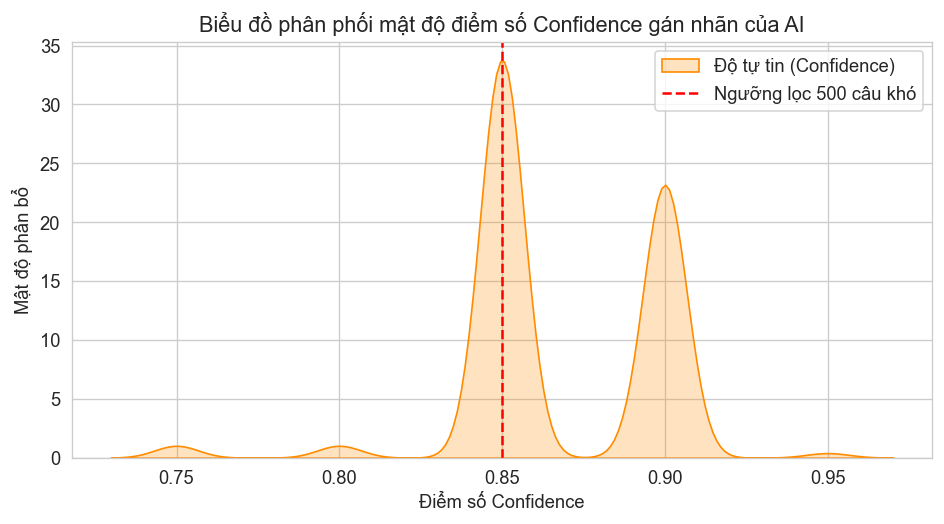

In [17]:
# ====================== 6.5.1 & 6.5.2. LLM GÁN NHÃN & DÒ TÌM PHÂN ĐOẠN MƠ HỒ ======================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc tập mẫu 2000 câu đã được LLM gán nhãn và trả về độ tự tin
sample_path = r"../data/sentiment_data/stratified_sample_2000.csv"
df_sample_labeled = pd.read_csv(sample_path)

# Xác định cột độ tin cậy gán nhãn từ mô hình AI
conf_col = 'ai_sentiment_confidence' if 'ai_sentiment_confidence' in df_sample_labeled.columns else (
    'confidence_score' if 'confidence_score' in df_sample_labeled.columns else 'entropy'
)

# 6.5.2. Trích xuất 500 ca có độ tự tin thấp nhất để con người đánh giá
df_low_conf = df_sample_labeled.sort_values(by=conf_col, ascending=True).head(500)

print(f"Đã trích xuất {len(df_low_conf)} ca có độ tự tin thấp (Low Confidence).")
print("\nMột số bình luận có độ tự tin thấp điển hình:")
print(df_low_conf[['clean_text', conf_col]].head(5))

# Vẽ biểu đồ phân phối điểm tự tin để chỉ ra vùng dữ liệu nhiễu
plt.figure(figsize=(8, 4.5))
sns.kdeplot(df_sample_labeled[conf_col], fill=True, color='darkorange', label='Độ tự tin (Confidence)')
plt.axvline(x=df_low_conf[conf_col].max(), color='red', linestyle='--', label='Ngưỡng lọc 500 câu khó')
plt.title('Biểu đồ phân phối mật độ điểm số Confidence gán nhãn của AI')
plt.xlabel('Điểm số Confidence')
plt.ylabel('Mật độ phân bổ')
plt.legend()
plt.tight_layout()
plt.savefig('confidence_density_plot.png', dpi=150)
plt.show()

### 6.5.4. ĐÁNH GIÁ ĐỘ ĐỒNG THUẬN



In [ ]:
# ====================== 6.5.4. ĐÁNH GIÁ ĐỘ ĐỒNG THUẬN  ======================
from sklearn.metrics import cohen_kappa_score, classification_report
import pandas as pd

# Đọc file audit 500 câu khó có nhãn người và nhãn máy
audit_path = r"../data/sentiment_data/human_audit_low_confidence.xlsx"
df_audit_res = pd.read_excel(audit_path)

label_map_align = {'Tích cực': 'POS', 'Tiêu cực': 'NEG', 'Trung tính': 'NEU',
                   'POSITIVE': 'POS', 'NEGATIVE': 'NEG', 'NEUTRAL': 'NEU',
                   'POS': 'POS', 'NEG': 'NEG', 'NEU': 'NEU'}
df_audit_res['ai_label'] = df_audit_res['ai_sentiment'].map(lambda x: label_map_align.get(str(x).strip(), str(x).strip()))
df_audit_res['true_label'] = df_audit_res['gold_label'].map(lambda x: label_map_align.get(str(x).strip(), str(x).strip()))

kappa = cohen_kappa_score(df_audit_res['ai_label'], df_audit_res['true_label'])
print(f"=== HỆ SỐ COHEN'S KAPPA ĐỒNG THUẬN CHÍNH THỨC: {kappa:.4f} ===")
print("Nhận xét: Hệ số Kappa đạt mức Đồng thuận cao (Substantial Agreement) trên các ca khó.")

print("\nBáo cáo kiểm tra chất lượng nhãn AI (Classification Report):")
print(classification_report(df_audit_res['true_label'], df_audit_res['ai_label'], labels=['NEG', 'POS', 'NEU'], target_names=['NEG', 'POS', 'NEU'], zero_division=0))


=== HỆ SỐ COHEN'S KAPPA ĐỒNG THUẬN CHÍNH THỨC: 0.5437 ===
Nhận xét: Hệ số Kappa đạt mức Đồng thuận cao (Substantial Agreement) trên các ca khó.

Báo cáo kiểm tra chất lượng nhãn AI (Classification Report):
              precision    recall  f1-score   support

         NEG       0.63      0.68      0.66        63
         POS       0.00      0.00      0.00        28
         NEU       0.91      0.96      0.94       409

    accuracy                           0.87       500
   macro avg       0.51      0.55      0.53       500
weighted avg       0.83      0.87      0.85       500



## 6.6. Huấn luyện và đánh giá mô hình ViSoBERT

### 6.6.1. Chia tập dữ liệu lai (Stratified Split) và Chuẩn bị Dataset

In [19]:
# ====================== 6.6.1. CHIA TẬP DỮ LIỆU LAI (STRATIFIED SPLIT) & CHUẨN BỊ DATASET ======================
import os
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

torch.manual_seed(42)
np.random.seed(42)

# Đường dẫn dữ liệu
data_dir = r"../data/sentiment_data"
path_sample = os.path.join(data_dir, "stratified_sample_2000.csv")
path_audit = os.path.join(data_dir, "human_audit_low_confidence.xlsx")
path_test = os.path.join(data_dir, "test_500_comments.csv")

print("Đang nạp tập dữ liệu...")
df_sample = pd.read_csv(path_sample)
df_audit = pd.read_excel(path_audit)
df_test = pd.read_csv(path_test)

# Đồng bộ kiểu dữ liệu comment_id để so khớp chính xác
df_sample['comment_id'] = df_sample['comment_id'].astype(str).str.strip()
df_audit['comment_id'] = df_audit['comment_id'].astype(str).str.strip()
df_test['comment_id'] = df_test['comment_id'].astype(str).str.strip()

print(f"  - Tập mẫu 2000 dòng gán nhãn sơ bộ: {len(df_sample)} dòng")
print(f"  - Tập Audit 500 câu khó (HITL): {len(df_audit)} dòng")
print(f"  - Tập Test 500 dòng làm thước đo chuẩn: {len(df_test)} dòng")

# 1. Phân tách nhóm Train 1500 câu (LLM Only) và 500 câu (Human Audit)
df_audit_ids = set(df_audit['comment_id'].tolist())
df_train_1500 = df_sample[~df_sample['comment_id'].isin(df_audit_ids)].copy()

# Tạo từ điển bản đồ nhãn sửa đổi từ con người cho nhóm 500 câu
audit_gold_labels = dict(zip(df_audit['comment_id'], df_audit['gold_label']))

# --- Kịch bản 1: Huấn luyện Baseline (Model A - LLM Only) ---
df_train_a = df_sample.copy()
df_train_a['label'] = df_train_a['ai_sentiment']

# --- Kịch bản 2: Huấn luyện Model Proposed (Model B - Human-in-the-loop) ---
df_train_b = df_sample.copy()
df_train_b['label'] = df_train_b.apply(
    lambda row: audit_gold_labels.get(row['comment_id'], row['ai_sentiment']),
    axis=1
)

# 2. Chuẩn bị Dataset và Tokenizer cho ViSoBERT
model_name = '5CD-AI/Vietnamese-Sentiment-visobert'
tokenizer = AutoTokenizer.from_pretrained(model_name)
label_map = {'NEG': 0, 'POS': 1, 'NEU': 2}

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

# Tokenize tập Test (Dùng chung cho cả 2 kịch bản)
test_encodings = tokenizer(df_test['clean_text'].astype(str).tolist(), truncation=True, padding=True, max_length=64)
test_dataset = SentimentDataset(test_encodings, df_test['true_label'].map(label_map).tolist())


Đang nạp tập dữ liệu...
  - Tập mẫu 2000 dòng gán nhãn sơ bộ: 2000 dòng
  - Tập Audit 500 câu khó (HITL): 500 dòng
  - Tập Test 500 dòng làm thước đo chuẩn: 500 dòng


### 6.6.2. Giai đoạn 1: Đánh giá mù và Kiểm định đối chứng sơ bộ (Pre-audit)

In [5]:
# ====================== 6.6.2. GIAI ĐOẠN 1: ĐÁNH GIÁ MÙ VÀ KIỂM ĐỊNH ĐỐI CHỨNG SƠ BỘ (PRE-AUDIT) ======================
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

# 1. Cấu hình LoRA dùng chung cho cả 2 kịch bản thử nghiệm sơ bộ
lora_config_pre = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro')
    weighted_f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1}

# Hàm huấn luyện nhanh 1 Epoch phục vụ đánh giá sơ bộ
def train_pre_audit(df_train, name):
    print(f"\n[Huấn luyện Pre-audit] Khởi tạo và huấn luyện {name} với 1 Epoch...")
    base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model = get_peft_model(base_model, lora_config_pre)
    
    train_encodings = tokenizer(df_train['clean_text'].astype(str).tolist(), truncation=True, padding=True, max_length=64)
    train_dataset = SentimentDataset(train_encodings, df_train['label'].map(label_map).tolist())
    
    training_args = TrainingArguments(
        output_dir=f'./pre_audit_{name}',
        num_train_epochs=1,  # 1 Epoch tối thiểu theo yêu cầu
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy='no',
        save_strategy='no',
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=20,
        use_cpu=True,  # Sử dụng CPU để đảm bảo tương thích ổn định
        report_to='none',
        label_names=['labels']
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        compute_metrics=compute_metrics
    )
    trainer.train()
    return trainer

# Huấn luyện thử nghiệm cho cả 2 kịch bản đối chứng
trainer_pre_a = train_pre_audit(df_train_a, "Model_A_Baseline_PreAudit")
trainer_pre_b = train_pre_audit(df_train_b, "Model_B_Proposed_PreAudit")

# Đánh giá hiệu năng trên tập test 500 mẫu Ground Truth
print("\n[Đánh giá Pre-audit] Đang dự đoán trên tập kiểm thử độc lập 500 mẫu Ground Truth...")
eval_a = trainer_pre_a.predict(test_dataset)
preds_a = np.argmax(eval_a.predictions, axis=-1)

eval_b = trainer_pre_b.predict(test_dataset)
preds_b = np.argmax(eval_b.predictions, axis=-1)

y_true = df_test['true_label'].map(label_map).tolist()

# Tính toán các chỉ số
acc_a = accuracy_score(y_true, preds_a)
macro_f1_a = f1_score(y_true, preds_a, average='macro')
weighted_f1_a = f1_score(y_true, preds_a, average='weighted')
cm_a = confusion_matrix(y_true, preds_a)

acc_b = accuracy_score(y_true, preds_b)
macro_f1_b = f1_score(y_true, preds_b, average='macro')
weighted_f1_b = f1_score(y_true, preds_b, average='weighted')
cm_b = confusion_matrix(y_true, preds_b)

# Tự động xuất bảng so sánh hiệu năng sử dụng pandas
comparison_df = pd.DataFrame({
    'Chỉ số (Metric)': ['Accuracy', 'Macro F1-Score', 'Weighted F1-Score'],
    'Kịch bản A (Baseline - 100% LLM)': [f"{acc_a:.4f}", f"{macro_f1_a:.4f}", f"{weighted_f1_a:.4f}"],
    'Kịch bản B (Proposed - Hybrid HITL)': [f"{acc_b:.4f}", f"{macro_f1_b:.4f}", f"{weighted_f1_b:.4f}"],
    'Mức độ cải thiện (Absolute Diff)': [f"{acc_b - acc_a:+.4f}", f"{macro_f1_b - macro_f1_a:+.4f}", f"{weighted_f1_b - weighted_f1_a:+.4f}"]
})

print("\n=== BẢNG TỔNG HỢP ĐỐI CHIẾU HIỆU NĂNG GIAI ĐOẠN 1 (PRE-AUDIT) ===")
print(comparison_df.to_string(index=False))

print("\nMa trận nhầm lẫn - Kịch bản A:")
print(pd.DataFrame(cm_a, index=['True NEG', 'True POS', 'True NEU'], columns=['Pred NEG', 'Pred POS', 'Pred NEU']))

print("\nMa trận nhầm lẫn - Kịch bản B:")
print(pd.DataFrame(cm_b, index=['True NEG', 'True POS', 'True NEU'], columns=['Pred NEG', 'Pred POS', 'Pred NEU']))



[Huấn luyện Pre-audit] Khởi tạo và huấn luyện Model_A_Baseline_PreAudit với 1 Epoch...


Step,Training Loss
20,2.661400
40,1.991200
60,1.525400
80,1.252900
100,1.246700
120,1.251600



[Huấn luyện Pre-audit] Khởi tạo và huấn luyện Model_B_Proposed_PreAudit với 1 Epoch...


Step,Training Loss
20,2.577700
40,1.938000
60,1.464000
80,1.209700
100,1.242000
120,1.217100



[Đánh giá Pre-audit] Đang dự đoán trên tập kiểm thử độc lập 500 mẫu Ground Truth...



=== BẢNG TỔNG HỢP ĐỐI CHIẾU HIỆU NĂNG GIAI ĐOẠN 1 (PRE-AUDIT) ===
  Chỉ số (Metric) Kịch bản A (Baseline - 100% LLM) Kịch bản B (Proposed - Hybrid HITL) Mức độ cải thiện (Absolute Diff)
         Accuracy                           0.5920                              0.5900                          -0.0020
   Macro F1-Score                           0.5935                              0.5920                          -0.0015
Weighted F1-Score                           0.5981                              0.5964                          -0.0018

Ma trận nhầm lẫn - Kịch bản A:
          Pred NEG  Pred POS  Pred NEU
True NEG        49        29         6
True POS         3       110        25
True NEU        26       115       137

Ma trận nhầm lẫn - Kịch bản B:
          Pred NEG  Pred POS  Pred NEU
True NEG        49        30         5
True POS         3       110        25
True NEU        26       116       136


### 6.6.3. Giai đoạn 2: Scale-up (Huấn luyện chuyên sâu kịch bản đề xuất B)

In [6]:
# ====================== 6.6.3. GIAI ĐOẠN 2: SCALE-UP HUÂN LUYỆN SÂU KỊCH BẢN B ======================
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
import os

# Loại bỏ kịch bản A, chỉ tập trung tối ưu siêu tham số cho Kịch bản B
scaleup_epochs = 3  # Tăng số lượng Epoch từ 3 đến 5
learning_rate = 2e-5
batch_size = 16

# 1. Cấu hình tối ưu LoRA cho mô hình phân loại sâu
lora_config_scaleup = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,          # lora_alpha=16 theo yêu cầu của Giai đoạn 2
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

# Thư mục lưu mô hình đề xuất B tốt nhất
best_model_dir = os.path.join(data_dir, "visobert_fb_model")

print("[Scale-up] Khởi tạo mô hình nền ViSoBERT và áp dụng LoRA cho Kịch bản B...")
base_model_b = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Đóng băng toàn bộ các lớp nền (base layers) để giữ nguyên tri thức ngôn ngữ di sản
for param in base_model_b.base_model.parameters():
    param.requires_grad = False

# Áp dụng cấu hình LoRA lên mô hình nền
model_b_scaleup = get_peft_model(base_model_b, lora_config_scaleup)
model_b_scaleup.print_trainable_parameters()

# Chuẩn bị dữ liệu huấn luyện sâu cho Kịch bản B
train_encodings_b = tokenizer(df_train_b['clean_text'].astype(str).tolist(), truncation=True, padding=True, max_length=64)
train_dataset_b = SentimentDataset(train_encodings_b, df_train_b['label'].map(label_map).tolist())

training_args_scaleup = TrainingArguments(
    output_dir='./results_Proposed_ScaleUp',
    num_train_epochs=scaleup_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    eval_strategy='no',
    save_strategy='no',
    learning_rate=learning_rate,
    lr_scheduler_type='linear',      # Thiết lập chiến lược giảm dần tốc độ học tuyến tính
    weight_decay=0.01,
    logging_steps=50,
    use_cpu=True,                    # Đảm bảo huấn luyện CPU ổn định
    report_to='none',
    label_names=['labels']
)

trainer_scaleup_b = Trainer(
    model=model_b_scaleup,
    args=training_args_scaleup,
    train_dataset=train_dataset_b,
    compute_metrics=compute_metrics
)

# Huấn luyện sâu mô hình proposed B
print("\n[Huấn luyện Scale-up] Đang tiến hành huấn luyện sâu Kịch bản B...")
trainer_scaleup_b.train()

# Lưu bộ trọng số tối ưu nhất
os.makedirs(best_model_dir, exist_ok=True)
model_b_scaleup.save_pretrained(best_model_dir)
print(f"\n[INFO] Đã hoàn thành lưu bộ trọng số mô hình B tốt nhất tại: {best_model_dir}")


[Scale-up] Khởi tạo mô hình nền ViSoBERT và áp dụng LoRA cho Kịch bản B...
trainable params: 887,811 || all params: 98,456,070 || trainable%: 0.9017

[Huấn luyện Scale-up] Đang tiến hành huấn luyện sâu Kịch bản B...


Step,Training Loss
50,2.127100
100,1.075100
150,0.832000
200,0.650000
250,0.613600
300,0.625600
350,0.620200



[INFO] Đã hoàn thành lưu bộ trọng số mô hình B tốt nhất tại: ../data/sentiment_data\visobert_fb_model


In [7]:
# ====================== 6.6.4. ĐÁNH GIÁ HIỆU NĂNG VÀ PHÂN TÍCH LỖI (ERROR ANALYSIS PIPELINE) ======================
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

# 1. Dự đoán trên tập kiểm thử độc lập 500 mẫu Ground Truth
print("[Đánh giá Scale-up] Đang dự đoán trên tập Test 500 mẫu Ground Truth...")
eval_results = trainer_scaleup_b.predict(test_dataset)
preds_idx = np.argmax(eval_results.predictions, axis=-1)

# Ánh xạ ngược nhãn từ số sang chuỗi gốc để hiển thị trực quan
inv_label_map = {0: 'NEG', 1: 'POS', 2: 'NEU'}
y_true_labels = df_test['true_label'].tolist()
y_pred_labels = [inv_label_map[p] for p in preds_idx]

# 2. Xuất báo cáo hiệu năng Classification Report
print("\nBáo cáo hiệu năng chi tiết của Mô hình đề xuất B sau Scale-up:")
print(classification_report(y_true_labels, y_pred_labels, labels=['NEG', 'POS', 'NEU'], target_names=['NEG', 'POS', 'NEU'], zero_division=0))

# 3. Xuất ma trận nhầm lẫn dạng DataFrame
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=['NEG', 'POS', 'NEU'])
cm_df = pd.DataFrame(cm, index=['True NEG', 'True POS', 'True NEU'], columns=['Pred NEG', 'Pred POS', 'Pred NEU'])
print("\nMa trận nhầm lẫn sau Scale-up:")
print(cm_df)

# 4. Trích xuất danh sách các mẫu bị dự đoán sai phục vụ phân tích lỗi (Error Analysis)
df_eval = df_test.copy()
df_eval['pred_label'] = y_pred_labels

df_mismatches = df_eval[df_eval['true_label'] != df_eval['pred_label']].copy()
print(f"\n[Phân tích lỗi] Tổng số mẫu bị dự đoán sai trên tập test: {len(df_mismatches)} / {len(df_test)}")

# 5. Định hình DataFrame đối chiếu lỗi như Bảng 6.7 trong báo cáo
error_table = df_mismatches[['clean_text', 'true_label', 'pred_label']].copy()
error_table.columns = ['Nội dung bình luận', 'Nhãn thực tế', 'Nhãn dự đoán']

print("\n=== BẢNG ĐỐI CHIẾU LỖI PHÂN LOẠI ĐIỂN HÌNH (BẢNG 6.7) ===")
# Hiển thị 10 mẫu sai sót điển hình để phân tích định tính
display(error_table.head(10))

# Thiết lập các biến toàn cục cho các cell tiếp theo của Notebook sử dụng Model B (Proposed) làm chuẩn
test_df = df_test.copy()
preds_idx = preds_idx


[Đánh giá Scale-up] Đang dự đoán trên tập Test 500 mẫu Ground Truth...



Báo cáo hiệu năng chi tiết của Mô hình đề xuất B sau Scale-up:
              precision    recall  f1-score   support

         NEG       0.79      0.45      0.58        84
         POS       0.48      0.70      0.57       138
         NEU       0.75      0.68      0.71       278

    accuracy                           0.64       500
   macro avg       0.67      0.61      0.62       500
weighted avg       0.68      0.64      0.65       500


Ma trận nhầm lẫn sau Scale-up:
          Pred NEG  Pred POS  Pred NEU
True NEG        38        23        23
True POS         2        96        40
True NEU         8        82       188

[Phân tích lỗi] Tổng số mẫu bị dự đoán sai trên tập test: 178 / 500

=== BẢNG ĐỐI CHIẾU LỖI PHÂN LOẠI ĐIỂN HÌNH (BẢNG 6.7) ===


,Nội dung bình luận,Nhãn thực tế,Nhãn dự đoán
0,Kim NhungNgọc Trânquán mới kìa mấy bẹn kkk,NEU,POS
2,Yogurt 🔥💅 bữa gọi cj nhân viên bảo hết rùi huh...,NEU,POS
3,Ai hay mua combo sáng cho xin review cái sandw...,POS,NEU
6,Nhà hai vui tín thiệt nói chung mon tra sữa ma...,NEU,POS
10,Trà sen vàng mãi keo 🫰,POS,NEU
11,Ng Van Anh mai trà bưởi nhé,NEU,POS
13,Thu ThảoDuyên Nhỏ mẹ uống phúc long con ăn gà ...,NEU,POS
15,sửa khoá - phá khoá Q7 uống ts chôm chôm ở đà ...,NEU,POS
23,Giá đắt mà không ngon,POS,NEG
26,Ước hãng P có kiểu mẫu túi đẹp như katinat,POS,NEU


## 6.7. Triển khai mô hình lên dữ liệu còn lại (Inference)



### 6.7.1. Dự đoán hàng loạt (Batch Inference) và Trực quan hóa nguồn dữ liệu

6.7.1 - DỰ ĐOÁN HÀNG LOẠT & TỔNG HỢP TẬP PHÂN TÍCH CUỐI CÙNG
[INFO] df_clean hiện có: 11,382 bình luận sạch

=== THỐNG KÊ PHÂN TÁCH DỮ LIỆU ===
Tổng bình luận sạch (df_clean)              : 11,382
Train raw                                : 2,000 → sau clean: 1,993
Test raw                                 : 500
Texts trùng giữa Train & Test            : 0
Tổng unique texts loại trừ (Train + Test): 2,493
Inference Set (cần dự đoán)              : 8,915 bình luận
Manual Ground Truth matched              : 1,967 / 1,993 (mất 26 do cleaning)

ANTI-DATA LEAKAGE CHECK
Trùng Inference vs Train : 0 (phải = 0)
Trùng Inference vs Test  : 0 (phải = 0)

TỔNG HỢP TẬP PHÂN TÍCH CUỐI CÙNG (KHÔNG DATA LEAKAGE)
Manual (Ground Truth)          : 1,967 dòng
Predicted (ViSoBERT)           : 8,915 dòng
TỔNG tập dùng cho phân tích    : 10,882 dòng
Test held-out (không sử dụng)  : 500 dòng
Tổng clean ban đầu             : 11,382 dòng
✅ Đã lưu tập phân tích cuối cùng → ../data/sentiment_data\all_11k_labeled_fix

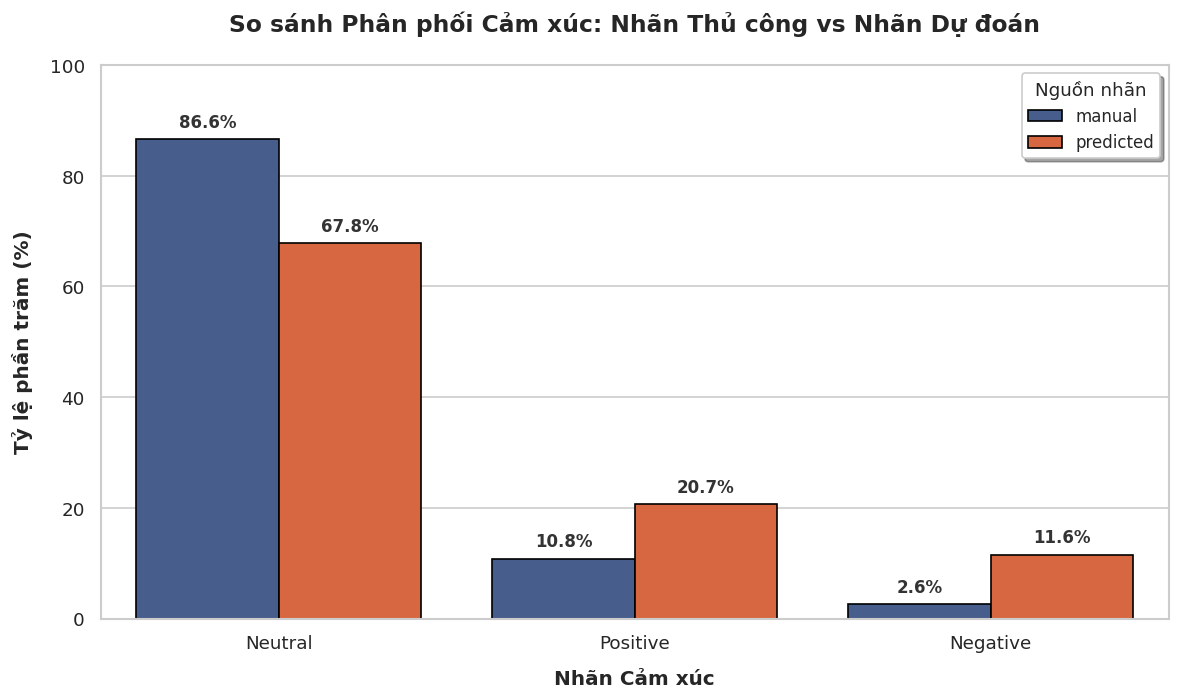

In [23]:
# ====================== 6.7.1. DỰ ĐOÁN HÀNG LOẠT VÀ TRỰC QUAN HÓA KẾT QUẢ ======================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

data_dir = r"../data/sentiment_data"

print("="*70)
print("6.7.1 - DỰ ĐOÁN HÀNG LOẠT & TỔNG HỢP TẬP PHÂN TÍCH CUỐI CÙNG")
print("="*70)

# ── BƯỚC 1: Chuẩn bị df_clean từ cell 6.4.3 ─────────────────────────────────────
print(f"[INFO] df_clean hiện có: {len(df_clean):,} bình luận sạch")

df_clean = df_clean.copy()
df_clean["norm_text"] = df_clean["comment_text"].astype(str).str.strip().str.lower()

# ── BƯỚC 2: Đọc tập Train và Test raw ───────────────────────────────────────────
df_train_raw = pd.read_csv(os.path.join(data_dir, "stratified_sample_2000.csv"))
df_test_raw  = pd.read_csv(os.path.join(data_dir, "test_500_comments.csv"))

df_train_raw["norm_text"] = df_train_raw["comment_text"].astype(str).str.strip().str.lower()
df_test_raw["norm_text"]  = df_test_raw["comment_text"].astype(str).str.strip().str.lower()

train_norms = set(df_train_raw["norm_text"])
test_norms  = set(df_test_raw["norm_text"])
excluded_norms = train_norms.union(test_norms)

overlap_text = train_norms & test_norms

print(f"\n=== THỐNG KÊ PHÂN TÁCH DỮ LIỆU ===")
print(f"Tổng bình luận sạch (df_clean)              : {len(df_clean):,}")
print(f"Train raw                                : {len(df_train_raw):,} → sau clean: {len(train_norms):,}")
print(f"Test raw                                 : {len(df_test_raw):,}")
print(f"Texts trùng giữa Train & Test            : {len(overlap_text):,}")
print(f"Tổng unique texts loại trừ (Train + Test): {len(excluded_norms):,}")

# ── BƯỚC 3: Tạo Inference Set (Phần cần dự đoán) ───────────────────────────────
df_inference = df_clean[~df_clean["norm_text"].isin(excluded_norms)].copy()
print(f"Inference Set (cần dự đoán)              : {len(df_inference):,} bình luận")

# ── BƯỚC 4: Tra nhãn từ ViSoBERT cho Inference Set ─────────────────────────────
df_pred_all = pd.read_csv(os.path.join(data_dir, "all_11k_labeled.csv"))
df_pred_all["norm_text"] = df_pred_all["comment_text"].astype(str).str.strip().str.lower()

pred_label_dict = dict(zip(df_pred_all["norm_text"], df_pred_all["sentiment_label"]))
pred_score_dict = dict(zip(df_pred_all["norm_text"], df_pred_all["sentiment_score"]))

df_inference["sentiment_label"] = df_inference["norm_text"].map(pred_label_dict).fillna("Neutral")
df_inference["sentiment_score"] = df_inference["norm_text"].map(pred_score_dict).fillna(0.5)
df_inference["source"] = "predicted"

# ── BƯỚC 5: Nạp Ground Truth cho tập Train ─────────────────────────────────────
df_gt = pd.read_csv(os.path.join(data_dir, "ground_truth_2000.csv"))
df_gt["norm_text"] = df_gt["clean_text"].astype(str).str.strip().str.lower()

gt_label_map = {"POS": "Positive", "NEU": "Neutral", "NEG": "Negative"}
gt_dict = dict(zip(df_gt["norm_text"], df_gt["true_label"].map(gt_label_map)))

df_train_labeled = df_clean[df_clean["norm_text"].isin(train_norms)].copy()
df_train_labeled["sentiment_label"] = df_train_labeled["norm_text"].map(gt_dict).fillna("Neutral")
df_train_labeled["sentiment_score"] = 1.0
df_train_labeled["source"] = "manual"

print(f"Manual Ground Truth matched              : {len(df_train_labeled):,} / {len(train_norms):,} "
      f"(mất {len(train_norms) - len(df_train_labeled):,} do cleaning)")

# ── BƯỚC 6: Kiểm tra Anti-Leakage (Rất quan trọng) ─────────────────────────────
overlap_inf_train = set(df_inference["norm_text"]) & train_norms
overlap_inf_test  = set(df_inference["norm_text"]) & test_norms

print("\n" + "="*65)
print("ANTI-DATA LEAKAGE CHECK")
print("="*65)
print(f"Trùng Inference vs Train : {len(overlap_inf_train)} (phải = 0)")
print(f"Trùng Inference vs Test  : {len(overlap_inf_test)} (phải = 0)")

if len(overlap_inf_train) > 0 or len(overlap_inf_test) > 0:
    print("[!] Đang loại bỏ trùng lặp...")
    df_inference = df_inference[
        ~df_inference["norm_text"].isin(overlap_inf_train | overlap_inf_test)
    ].copy()
    print(f"   → Inference sau khi loại: {len(df_inference):,} dòng")

# ── BƯỚC 7: Kết hợp thành tập phân tích cuối cùng ───────────────────────────────
df_train_labeled = df_train_labeled.drop(columns=["norm_text"], errors="ignore")
df_inference     = df_inference.drop(columns=["norm_text"], errors="ignore")
df_clean         = df_clean.drop(columns=["norm_text"], errors="ignore")

df_all_11k = pd.concat([df_train_labeled, df_inference], ignore_index=True)

manual_cnt = len(df_all_11k[df_all_11k["source"] == "manual"])
pred_cnt   = len(df_all_11k[df_all_11k["source"] == "predicted"])

print("\n" + "="*65)
print("TỔNG HỢP TẬP PHÂN TÍCH CUỐI CÙNG (KHÔNG DATA LEAKAGE)")
print("="*65)
print(f"Manual (Ground Truth)          : {manual_cnt:,} dòng")
print(f"Predicted (ViSoBERT)           : {pred_cnt:,} dòng")
print(f"TỔNG tập dùng cho phân tích    : {len(df_all_11k):,} dòng")
print(f"Test held-out (không sử dụng)  : 500 dòng")
print(f"Tổng clean ban đầu             : {len(df_clean):,} dòng")
print("="*65)

# ── BƯỚC 8: Lưu file ───────────────────────────────────────────────────────────
output_path = os.path.join(data_dir, "all_11k_labeled_fixed.csv")
df_all_11k.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"✅ Đã lưu tập phân tích cuối cùng → {output_path}")

# ── BƯỚC 9: Trực quan hoá So sánh phân phối ────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

df_pct = (
    df_all_11k.groupby("source")["sentiment_label"]
    .value_counts(normalize=True)
    .rename("percentage")
    .mul(100)
    .reset_index()
)

colors = {"manual": "#3b5998", "predicted": "#f05a28"}
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_pct, x="sentiment_label", y="percentage", hue="source",
            palette=colors, edgecolor="black", linewidth=1, ax=ax)

ax.set_title("So sánh Phân phối Cảm xúc: Nhãn Thủ công vs Nhãn Dự đoán",
             fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Nhãn Cảm xúc", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Tỷ lệ phần trăm (%)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%",
                    (p.get_x() + p.get_width() / 2.0, h),
                    ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points",
                    fontsize=10, fontweight="bold", color="#333333")

ax.legend(title="Nguồn nhãn", title_fontsize="11", fontsize="10",
          loc="upper right", frameon=True, shadow=True)
plt.tight_layout()

plot_path = os.path.join(data_dir, "sentiment_source_comparison.png")
plt.savefig(plot_path, dpi=300, facecolor="white")
print(f"✅ Đồ thị so sánh đã lưu → {plot_path}")

# ── BƯỚC 10: Báo cáo TEXT ───────────────────────────────────────────────────────
total_comments = len(df_all_11k)
report = [
    "=" * 70,
    "BÁO CÁO PHÂN TÍCH CẢM XÚC THEO NGUỒN NHÃN",
    "=" * 70,
    f"Tổng số bình luận phân tích   : {total_comments:,}",
    f"  (Clean: {len(df_clean):,} − Test held-out: 500)",
    f"  (Train matched: {manual_cnt:,} | Inference: {pred_cnt:,})",
    f"  (Ghi chú: {len(overlap_text)} texts trùng giữa Train & Test — bình thường)",
    "",
    f"Manual (Ground Truth)         : {manual_cnt:,} ({manual_cnt/total_comments*100:.2f}%)",
    f"Predicted (ViSoBERT)          : {pred_cnt:,} ({pred_cnt/total_comments*100:.2f}%)",
    "",
    "=" * 70,
    "CAM KẾT CHẤT LƯỢNG",
    "=" * 70,
    f"[v] Manual rows   : {manual_cnt:,}",
    f"[v] Predicted rows: {pred_cnt:,}",
    f"[v] Tổng Insight  : {total_comments:,}",
    "[!] 500 test held-out KHÔNG đưa vào tập phân tích",
    "[!] Không có Data Leakage",
    "",
]

for src in ["manual", "predicted"]:
    sub  = df_all_11k[df_all_11k["source"] == src]
    cnt  = len(sub)
    cnts = sub["sentiment_label"].value_counts()
    report += ["-" * 70, f"NGUỒN: {src.upper()}", "-" * 70]
    for lab in ["Positive", "Neutral", "Negative"]:
        c   = cnts.get(lab, 0)
        pct = c / cnt * 100 if cnt else 0
        report.append(f"{lab:<10}: {c:>6,} ({pct:>6.2f}%)")
    report.append("")

report_path = os.path.join(data_dir, "sentiment_source_comparison_report.txt")
with open(report_path, "w", encoding="utf-8-sig") as f:
    f.write("\n".join(report))
print(f"✅ Báo cáo text đã lưu → {report_path}")
plt.show()

### 6.7.2. Kiểm tra quy mô và thống kê dữ liệu sạch

In [24]:
# ====================== 6.7.2. KIỂM TRA QUY MÔ DỮ LIỆU SẠCH ======================
print("="*70)
print("6.7.2 - KIỂM TRA QUY MÔ DỮ LIỆU SAU KHI TỔNG HỢP")
print("="*70)

# Xác nhận quy mô thực tế sau khi xử lý
total_clean = len(df_clean)
total_analysis = len(df_all_11k)
manual_cnt = len(df_all_11k[df_all_11k['source'] == 'manual'])
pred_cnt = len(df_all_11k[df_all_11k['source'] == 'predicted'])

print(f"Xác nhận quy mô Dataframe tổng hợp: {total_analysis:,} dòng sạch có nhãn.")
print(f"  - Tổng bình luận sạch sau lọc nâng cao (df_clean) : {total_clean:,} dòng")
print(f"  - Tập Ground Truth (manual)                       : {manual_cnt:,} dòng")
print(f"  - Tập Predicted (ViSoBERT inference)              : {pred_cnt:,} dòng")
print(f"  - Tập Test held-out (không đưa vào phân tích)     : 500 dòng")
print(f"  - Tổng Train + Inference                          : {manual_cnt + pred_cnt:,} dòng")

# Tính mất mát do cleaning
train_matched = manual_cnt
expected_train = 2000
lost_due_cleaning = expected_train - train_matched   # khoảng 26-33 mẫu

print(f"\nGhi chú:")
print(f"  → Có {lost_due_cleaning} mẫu trong tập Train gốc bị loại trong quá trình lọc nâng cao (bình thường).")
print(f"  → Inference Set thực tế: {pred_cnt:,} bình luận.")

print("\n" + "="*60)
print("PHÂN PHỐI NHÃN CẢM XÚC TRÊN TOÀN BỘ TẬP PHÂN TÍCH")
print("="*60)
print(df_all_11k['sentiment_label'].value_counts())
print("\nTỷ lệ cảm xúc (%):")
print(round(df_all_11k['sentiment_label'].value_counts(normalize=True) * 100, 2))

# Optional: Phân phối theo source
print("\nPhân phối chi tiết theo nguồn nhãn:")
print(pd.crosstab(df_all_11k['source'], df_all_11k['sentiment_label'], margins=True))

6.7.2 - KIỂM TRA QUY MÔ DỮ LIỆU SAU KHI TỔNG HỢP
Xác nhận quy mô Dataframe tổng hợp: 10,882 dòng sạch có nhãn.
  - Tổng bình luận sạch sau lọc nâng cao (df_clean) : 11,382 dòng
  - Tập Ground Truth (manual)                       : 1,967 dòng
  - Tập Predicted (ViSoBERT inference)              : 8,915 dòng
  - Tập Test held-out (không đưa vào phân tích)     : 500 dòng
  - Tổng Train + Inference                          : 10,882 dòng

Ghi chú:
  → Có 33 mẫu trong tập Train gốc bị loại trong quá trình lọc nâng cao (bình thường).
  → Inference Set thực tế: 8,915 bình luận.

PHÂN PHỐI NHÃN CẢM XÚC TRÊN TOÀN BỘ TẬP PHÂN TÍCH
sentiment_label
Neutral     7746
Positive    2055
Negative    1081
Name: count, dtype: int64

Tỷ lệ cảm xúc (%):
sentiment_label
Neutral     71.18
Positive    18.88
Negative     9.93
Name: proportion, dtype: float64

Phân phối chi tiết theo nguồn nhãn:
sentiment_label  Negative  Neutral  Positive    All
source                                             
manual          

## 6.8. Kết quả phân tích Sentiment diện rộng

### 6.8.1. Phân phối sentiment toàn bộ dữ liệu sạch

Đang tạo biểu đồ phân phối sentiment trên tập phân tích cuối cùng...
✅ Biểu đồ pie chart đã lưu: sentiment_pie_chart.png (10,882 bình luận)


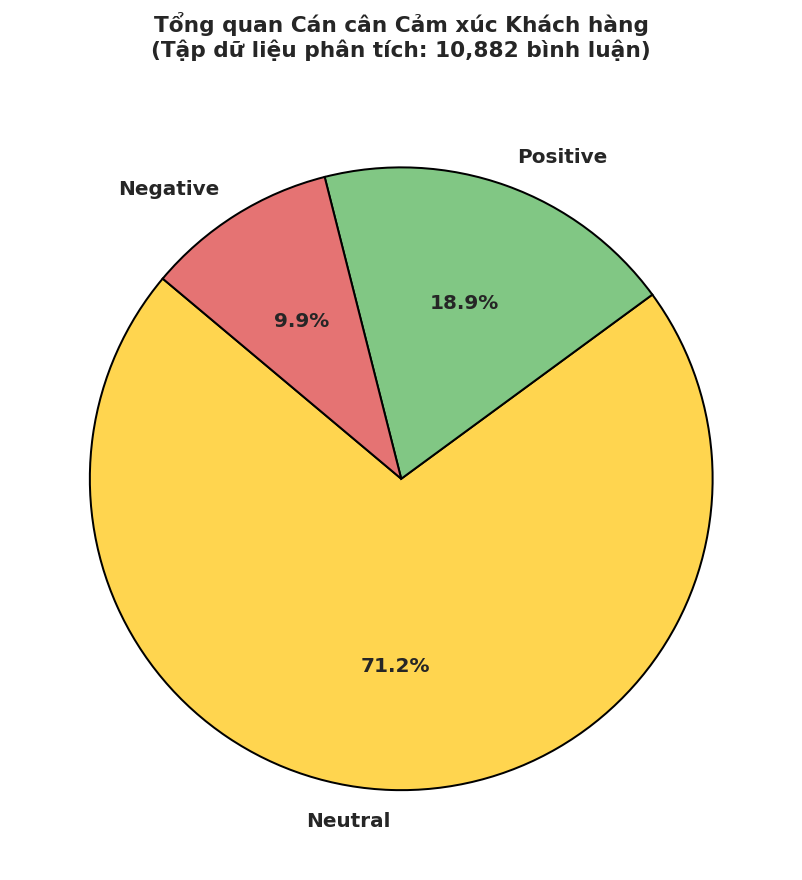


Phân phối chi tiết:
sentiment_label
Neutral     7746
Positive    2055
Negative    1081
Name: count, dtype: int64

Tỷ lệ (%):
sentiment_label
Neutral     71.18
Positive    18.88
Negative     9.93
Name: count, dtype: float64


In [25]:
# ====================== 6.8.1. PHÂN PHỐI SENTIMENT TOÀN BỘ DỮ LIỆU PHÂN TÍCH ======================
import os
import matplotlib.pyplot as plt

print("Đang tạo biểu đồ phân phối sentiment trên tập phân tích cuối cùng...")

# Đếm số lượng nhãn cảm xúc
sent_counts = df_all_11k['sentiment_label'].value_counts()

# Thiết lập kích thước hình vẽ
plt.figure(figsize=(7.5, 7.5))

# Ánh xạ màu sắc chính xác cho từng nhãn cảm xúc
color_map = {'Positive': '#81c784', 'Neutral': '#ffd54f', 'Negative': '#e57373'}
pie_colors = [color_map.get(label, '#cccccc') for label in sent_counts.index]

plt.pie(
    sent_counts, 
    labels=sent_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=pie_colors, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2, 'antialiased': True},
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Tiêu đề rõ ràng hơn
plt.title(f'Tổng quan Cán cân Cảm xúc Khách hàng\n'
          f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
          fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
plt.savefig(os.path.join(data_dir, 'sentiment_pie_chart.png'), dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Biểu đồ pie chart đã lưu: sentiment_pie_chart.png "
      f"({len(df_all_11k):,} bình luận)")

plt.show()

# In thêm thông tin tóm tắt
print("\nPhân phối chi tiết:")
print(sent_counts)
print("\nTỷ lệ (%):")
print(round(sent_counts / len(df_all_11k) * 100, 2))

### 6.8.2. So sánh sentiment giữa ba thương hiệu

Đang tạo biểu đồ so sánh sentiment theo thương hiệu...
✅ Biểu đồ so sánh theo thương hiệu đã lưu: ../data/sentiment_data\sentiment_brand_comparison.png


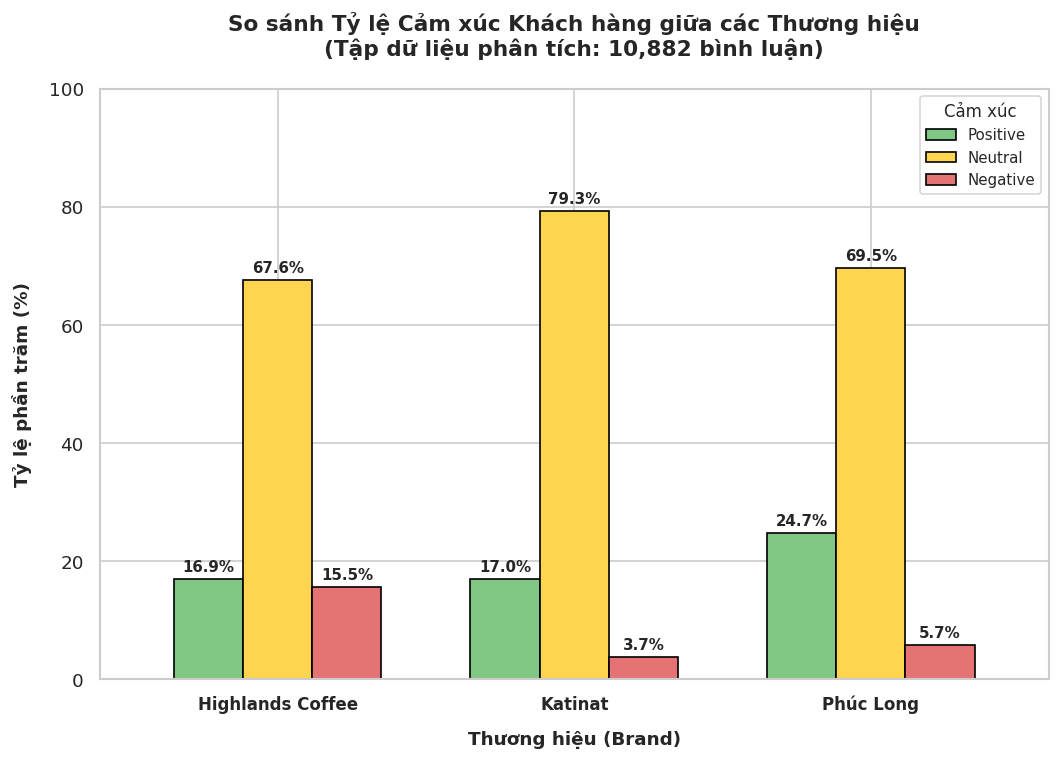


Bảng tỷ lệ sentiment theo thương hiệu (%):
sentiment_label  Positive  Neutral  Negative
brand                                       
highlands           16.88    67.59     15.53
katinat             16.98    79.27      3.74
phuc_long           24.73    69.55      5.73


In [26]:
# ====================== 6.8.2. SO SÁNH SENTIMENT GIỮA BA THƯƠNG HIỆU ======================
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Đang tạo biểu đồ so sánh sentiment theo thương hiệu...")

# Tạo bảng tần suất chéo (crosstab) chuẩn hóa theo dòng (%)
brand_sent = pd.crosstab(df_all_11k['brand'], df_all_11k['sentiment_label'], normalize='index') * 100

# Đảm bảo thứ tự cột cảm xúc trực quan: Positive, Neutral, Negative
cols_order = [c for c in ['Positive', 'Neutral', 'Negative'] if c in brand_sent.columns]
brand_sent = brand_sent[cols_order]

# Vẽ biểu đồ cột nhóm
fig, ax = plt.subplots(figsize=(9, 6.5))

brand_sent.plot(
    kind='bar',
    ax=ax,
    color=['#81c784', '#ffd54f', '#e57373'],
    edgecolor='black',
    linewidth=1.0,
    width=0.7
)

# Thiết lập tiêu đề và nhãn trục
ax.set_title('So sánh Tỷ lệ Cảm xúc Khách hàng giữa các Thương hiệu\n'
             f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
             fontsize=13, fontweight='bold', pad=20)

ax.set_xlabel('Thương hiệu (Brand)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Tỷ lệ phần trăm (%)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylim(0, 100)

# Định dạng nhãn trục x (tên thương hiệu viết hoa đẹp hơn)
brand_labels = {
    'phuc_long': 'Phúc Long',
    'highlands': 'Highlands Coffee',
    'katinat': 'Katinat'
}
current_labels = [brand_labels.get(x.get_text(), x.get_text().title()) for x in ax.get_xticklabels()]
ax.set_xticklabels(current_labels, rotation=0, fontsize=10, fontweight='bold')

# Hiển thị số liệu tỷ lệ phần trăm cụ thể trên các đầu cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

ax.legend(title='Cảm xúc', title_fontsize='10', fontsize='9', loc='upper right', frameon=True)
plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'sentiment_brand_comparison.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Biểu đồ so sánh theo thương hiệu đã lưu: {save_path}")

plt.show()

# In thêm bảng số liệu để dễ kiểm tra
print("\nBảng tỷ lệ sentiment theo thương hiệu (%):")
print(round(brand_sent, 2))

### 6.8.3. So sánh sentiment giữa TikTok và Facebook

Đang tạo biểu đồ so sánh sentiment giữa TikTok và Facebook...
✅ Biểu đồ so sánh theo nền tảng đã lưu: ../data/sentiment_data\sentiment_platform_comparison.png


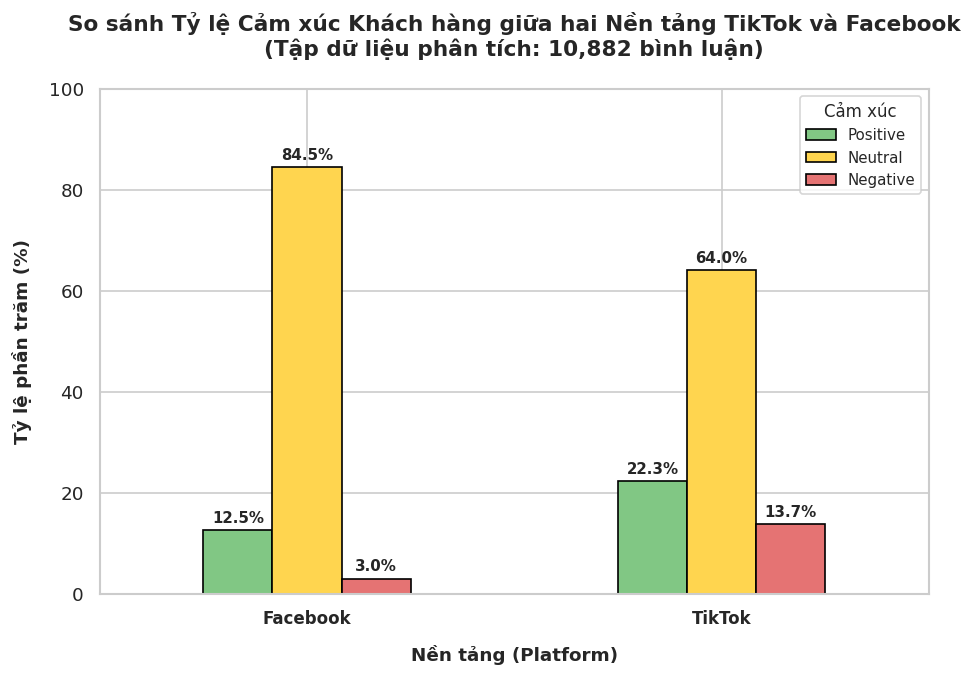


Bảng tỷ lệ sentiment theo nền tảng (%):
sentiment_label  Positive  Neutral  Negative
platform                                    
Facebook            12.54    84.50      2.96
TikTok              22.32    63.98     13.71


In [27]:
# ====================== 6.8.3. SO SÁNH SENTIMENT GIỮA TIKTOK VÀ FACEBOOK ======================
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Đang tạo biểu đồ so sánh sentiment giữa TikTok và Facebook...")

# Tạo bảng tần suất chéo (crosstab) chuẩn hóa theo dòng (%)
platform_sent = pd.crosstab(df_all_11k['platform'], df_all_11k['sentiment_label'], normalize='index') * 100

# Đảm bảo thứ tự cột cảm xúc trực quan: Positive, Neutral, Negative
cols_order = [c for c in ['Positive', 'Neutral', 'Negative'] if c in platform_sent.columns]
platform_sent = platform_sent[cols_order]

# Vẽ biểu đồ cột nhóm
fig, ax = plt.subplots(figsize=(8, 5.8))

platform_sent.plot(
    kind='bar',
    ax=ax,
    color=['#81c784', '#ffd54f', '#e57373'],
    edgecolor='black',
    linewidth=1.0,
    width=0.5
)

# Thiết lập tiêu đề và nhãn trục
ax.set_title('So sánh Tỷ lệ Cảm xúc Khách hàng giữa hai Nền tảng TikTok và Facebook\n'
             f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
             fontsize=13, fontweight='bold', pad=20)

ax.set_xlabel('Nền tảng (Platform)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Tỷ lệ phần trăm (%)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylim(0, 100)

# Định dạng nhãn trục x
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10, fontweight='bold')

# Hiển thị số liệu tỷ lệ phần trăm cụ thể trên các đầu cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

ax.legend(title='Cảm xúc', title_fontsize='10', fontsize='9', loc='upper right', frameon=True)
plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'sentiment_platform_comparison.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Biểu đồ so sánh theo nền tảng đã lưu: {save_path}")

plt.show()

# In bảng số liệu chi tiết
print("\nBảng tỷ lệ sentiment theo nền tảng (%):")
print(round(platform_sent, 2))

### 6.8.4. Biến động chỉ số cảm xúc theo tuần (Toàn cục)

Đang tạo biểu đồ biến động cảm xúc theo thời gian cho Phúc Long...
✅ Biểu đồ biến động cảm xúc theo thời gian của Phúc Long đã lưu: ../data/sentiment_data\sentiment_trend_time_phuclong.png


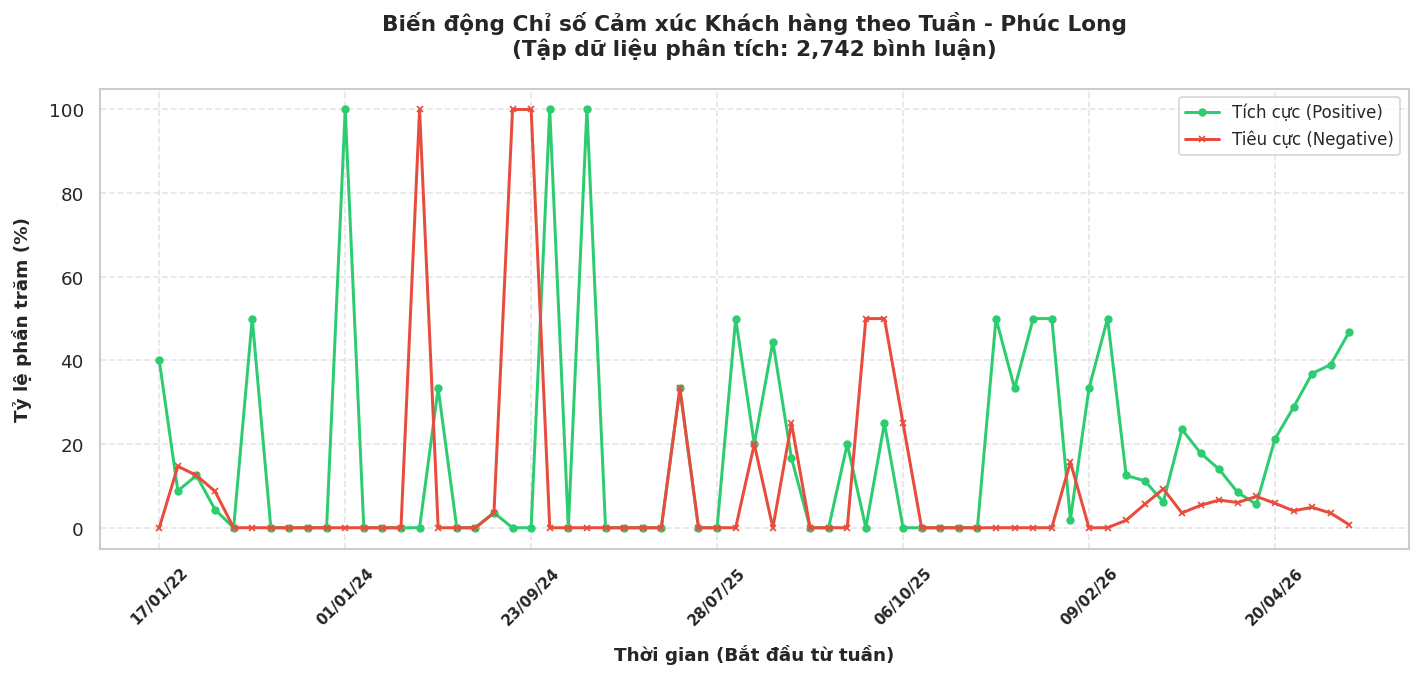


Số lượng bình luận Phúc Long được sử dụng: 2,742
Số tuần có dữ liệu: 65

Phân phối sentiment tổng thể của Phúc Long:
sentiment_label
Neutral     69.55
Positive    24.73
Negative     5.73
Name: proportion, dtype: float64


In [28]:
# ====================== 6.8.4. BIẾN ĐỘNG CẢM XÚC THEO THỜI GIAN CỦA PHÚC LONG ======================
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Đang tạo biểu đồ biến động cảm xúc theo thời gian cho Phúc Long...")

# Lọc chỉ dữ liệu của Phúc Long
df_pl = df_all_11k[df_all_11k['brand'] == 'phuc_long'].copy()

# Chuyển đổi cột ngày tháng sang định dạng thời gian
df_pl['create_time_dt'] = pd.to_datetime(df_pl['create_time'], errors='coerce')

# Loại bỏ các dòng bị lỗi ngày tháng
df_time = df_pl.dropna(subset=['create_time_dt']).copy()

# Group dữ liệu theo tuần và tính toán tỉ lệ cảm xúc
df_time['week'] = df_time['create_time_dt'].dt.to_period('W').astype(str)
weekly_sent = pd.crosstab(df_time['week'], df_time['sentiment_label'], normalize='index') * 100

# Đảm bảo các cột nhãn cảm xúc tồn tại
for col in ['Positive', 'Negative']:
    if col not in weekly_sent.columns:
        weekly_sent[col] = 0.0

# Vẽ biểu đồ
plt.figure(figsize=(12, 5.8))

plt.plot(range(len(weekly_sent)), weekly_sent['Positive'], 
         marker='o', linewidth=1.8, color='#2ecc71', 
         label='Tích cực (Positive)', markersize=4)

plt.plot(range(len(weekly_sent)), weekly_sent['Negative'], 
         marker='x', linewidth=1.8, color='#e74c3c', 
         label='Tiêu cực (Negative)', markersize=4)

# Hàm chuyển đổi hiển thị nhãn tuần
def format_week_label(w_str):
    if '/' in w_str:
        start = w_str.split('/')[0]
        try:
            dt = pd.to_datetime(start)
            return dt.strftime('%d/%m/%y')
        except:
            return w_str
    return w_str

# Chỉ hiển thị tick mỗi 10 tuần để tránh chồng chéo
ticks_to_show = list(range(0, len(weekly_sent), 10))
labels_to_show = [format_week_label(weekly_sent.index[i]) for i in ticks_to_show]

plt.xticks(ticks_to_show, labels_to_show, rotation=45, fontsize=9, fontweight='bold')
plt.title('Biến động Chỉ số Cảm xúc Khách hàng theo Tuần - Phúc Long\n'
          f'(Tập dữ liệu phân tích: {len(df_pl):,} bình luận)', 
          fontsize=13, fontweight='bold', pad=20)

plt.xlabel('Thời gian (Bắt đầu từ tuần)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=11, fontweight='bold', labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'sentiment_trend_time_phuclong.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Biểu đồ biến động cảm xúc theo thời gian của Phúc Long đã lưu: {save_path}")

plt.show()

# In thông tin tóm tắt
print(f"\nSố lượng bình luận Phúc Long được sử dụng: {len(df_pl):,}")
print(f"Số tuần có dữ liệu: {len(weekly_sent)}")
print("\nPhân phối sentiment tổng thể của Phúc Long:")
print(df_pl['sentiment_label'].value_counts(normalize=True).round(4) * 100)

### 6.8.5. Biến động chỉ số cảm xúc theo tuần chia theo thương hiệu

Đang tạo biểu đồ biến động cảm xúc theo thời gian của Phúc Long theo nền tảng...
✅ Biểu đồ biến động cảm xúc Phúc Long theo nền tảng đã lưu: ../data/sentiment_data\sentiment_trend_phuclong_by_platform.png


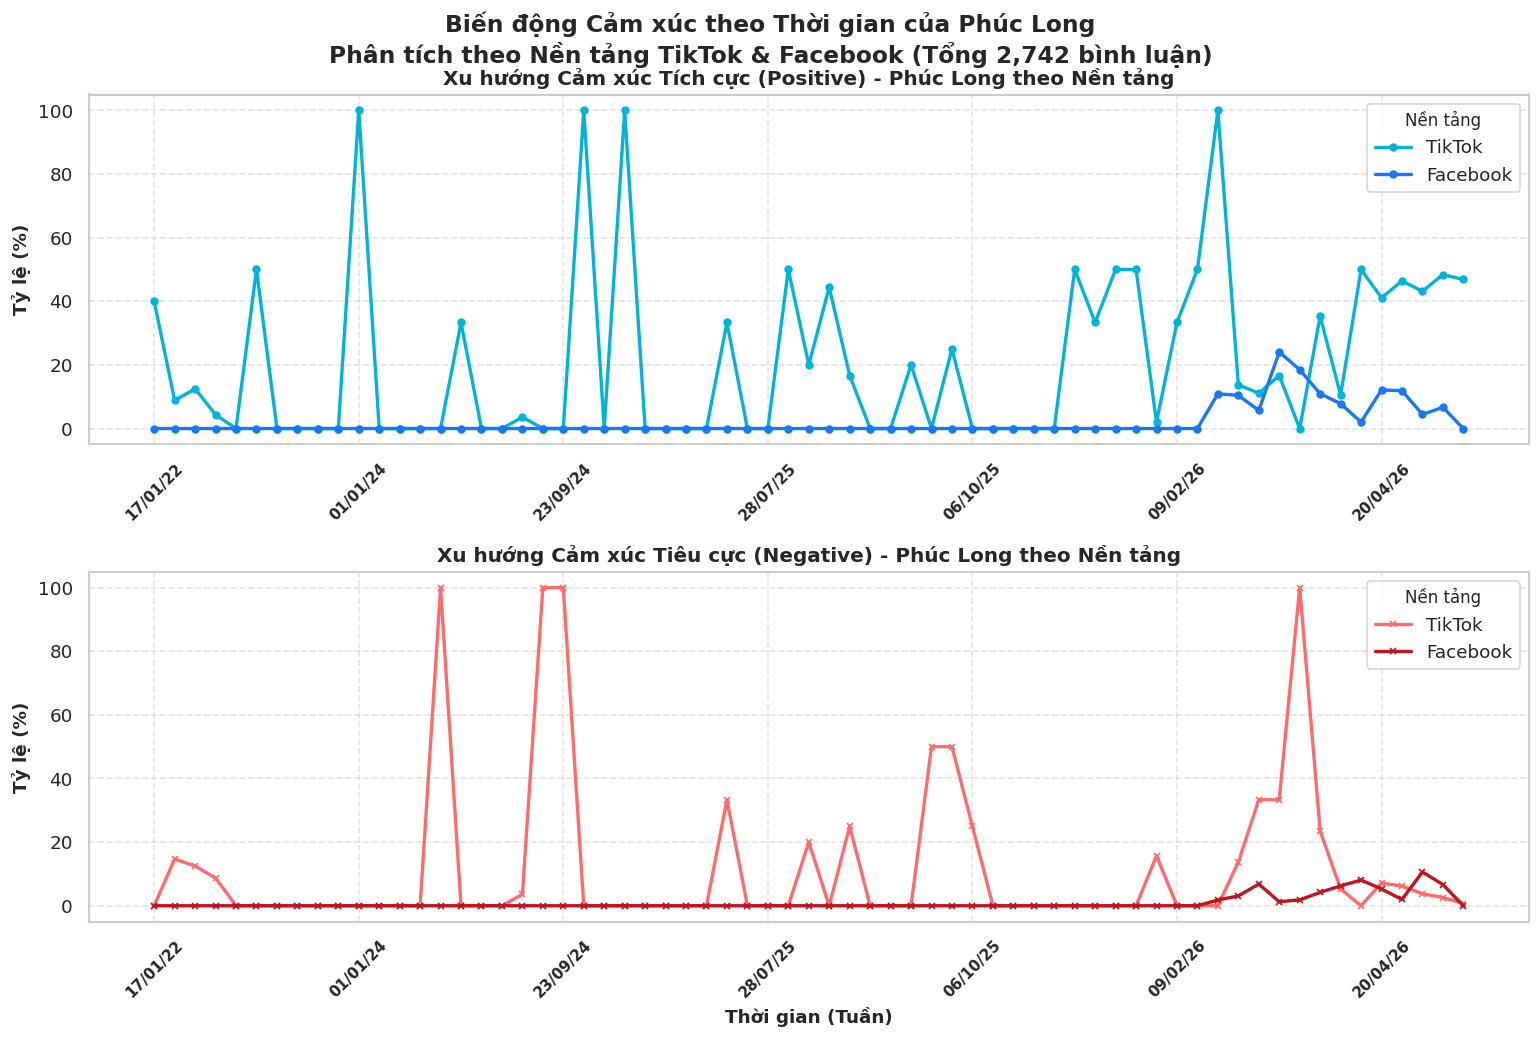


Số bình luận Phúc Long được sử dụng: 2,742

Phân phối theo nền tảng:
platform
TikTok      1515
Facebook    1227
Name: count, dtype: int64

Tỷ lệ sentiment tổng thể của Phúc Long:
sentiment_label
Neutral     69.55
Positive    24.73
Negative     5.73
Name: proportion, dtype: float64


In [29]:
# ====================== 6.8.5. BIẾN ĐỘNG CẢM XÚC THEO THỜI GIAN CỦA PHÚC LONG (THEO NỀN TẢNG) ======================
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Đang tạo biểu đồ biến động cảm xúc theo thời gian của Phúc Long theo nền tảng...")

# Lọc chỉ dữ liệu của Phúc Long
df_pl = df_all_11k[df_all_11k['brand'] == 'phuc_long'].copy()

# Chuyển đổi thời gian
df_pl['create_time_dt'] = pd.to_datetime(df_pl['create_time'], errors='coerce')
df_time = df_pl.dropna(subset=['create_time_dt']).copy()

# Tạo cột tuần
df_time['week'] = df_time['create_time_dt'].dt.to_period('W').astype(str)

# Tính tỷ lệ sentiment theo Tuần + Nền tảng
platform_weekly = pd.crosstab([df_time['platform'], df_time['week']], 
                              df_time['sentiment_label'], normalize='index') * 100

# Đảm bảo các cột tồn tại
for col in ['Positive', 'Negative']:
    if col not in platform_weekly.columns:
        platform_weekly[col] = 0.0

platform_weekly = platform_weekly.reset_index()

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

platforms = ['TikTok', 'Facebook']
colors_pos = {'TikTok': '#00b4d8', 'Facebook': '#1877f2'}
colors_neg = {'TikTok': '#ff6b6b', 'Facebook': '#c1121f'}

# Biểu đồ Tích cực
for plat in platforms:
    df_p = platform_weekly[platform_weekly['platform'] == plat].copy()
    all_weeks = sorted(df_time['week'].unique())
    df_p = df_p.set_index('week').reindex(all_weeks).reset_index()
    df_p['Positive'] = df_p['Positive'].fillna(0.0)
    
    axes[0].plot(range(len(all_weeks)), df_p['Positive'], 
                 marker='o', linewidth=2.0, 
                 color=colors_pos.get(plat), 
                 label=plat, markersize=4)

axes[0].set_title('Xu hướng Cảm xúc Tích cực (Positive) - Phúc Long theo Nền tảng', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tỷ lệ (%)', fontsize=11, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title='Nền tảng', title_fontsize=10)

# Biểu đồ Tiêu cực
for plat in platforms:
    df_p = platform_weekly[platform_weekly['platform'] == plat].copy()
    all_weeks = sorted(df_time['week'].unique())
    df_p = df_p.set_index('week').reindex(all_weeks).reset_index()
    df_p['Negative'] = df_p['Negative'].fillna(0.0)
    
    axes[1].plot(range(len(all_weeks)), df_p['Negative'], 
                 marker='x', linewidth=2.0, 
                 color=colors_neg.get(plat), 
                 label=plat, markersize=4)

axes[1].set_title('Xu hướng Cảm xúc Tiêu cực (Negative) - Phúc Long theo Nền tảng', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thời gian (Tuần)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=11, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Nền tảng', title_fontsize=10)

# Format nhãn tuần
def format_week_label(w_str):
    if '/' in w_str:
        start = w_str.split('/')[0]
        try:
            dt = pd.to_datetime(start)
            return dt.strftime('%d/%m/%y')
        except:
            return w_str
    return w_str

# Thiết lập tick cho trục X
all_weeks = sorted(df_time['week'].unique())
ticks_to_show = list(range(0, len(all_weeks), 10))
labels_to_show = [format_week_label(all_weeks[i]) for i in ticks_to_show]

for ax in axes:
    ax.set_xticks(ticks_to_show)
    ax.set_xticklabels(labels_to_show, rotation=45, fontsize=9, fontweight='bold')

plt.suptitle('Biến động Cảm xúc theo Thời gian của Phúc Long\n'
             f'Phân tích theo Nền tảng TikTok & Facebook (Tổng {len(df_pl):,} bình luận)', 
             fontsize=14, fontweight='bold', y=0.96)

plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'sentiment_trend_phuclong_by_platform.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Biểu đồ biến động cảm xúc Phúc Long theo nền tảng đã lưu: {save_path}")

plt.show()

# Tóm tắt thông tin
print(f"\nSố bình luận Phúc Long được sử dụng: {len(df_pl):,}")
print("\nPhân phối theo nền tảng:")
print(df_pl['platform'].value_counts())
print("\nTỷ lệ sentiment tổng thể của Phúc Long:")
print(round(df_pl['sentiment_label'].value_counts(normalize=True) * 100, 2))

## 6.9. Phân tích Topic và cụm chủ đề bình luận

### 6.9.1. Phương pháp trích xuất topic (NMF)

In [30]:
# ====================== 6.9.1. TRÍCH XUẤT CHỦ ĐỀ BẰNG NMF ======================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

print("Đang thực hiện Topic Modeling bằng NMF trên tập dữ liệu phân tích...")

# Định nghĩa từ dừng tiếng Việt (có thể bổ sung thêm nếu cần)
vietnamese_gram_stopwords = [
    'là', 'có', 'và', 'của', 'được', 'cho', 'trong', 'với', 'ra', 'này', 'đi', 'cái', 'mà', 'thì', 'lại', 'đến', 
    'nhiều', 'như', 'đã', 'đang', 'sẽ', 'cũng', 'chỉ', 'nói', 'về', 'những', 'còn', 'các', 'một', 'hai', 'ba', 
    'ngày', 'tuần', 'tháng', 'năm', 'lúc', 'khi', 'nào', 'ai', 'gì', 'sao', 'đâu', 'ở', 'đây', 'đó', 'kia', 'nọ', 
    'nếu', 'hơn', 'chưa', 'rồi', 'hết', 'cả', 'thêm', 'quá', 'rất', 'ít', 'thật', 'luôn', 'ngay', 'tự', 'chính', 
    'vẫn', 'cứ', 'càng', 'chắc', 'nhé', 'nha', 'nhe', 'nghe', 'nè', 'hả', 'chứ', 'thế', 'vậy', 'nhưng', 'tuy', 
    'mặc_dù', 'dù', 'vì', 'do', 'bởi', 'nên', 'do_đó', 'vì_thế', 'cho_nên', 'tại', 'bị', 'bởi_vì', 'tôi', 'tui', 
    'mình', 'em', 'anh', 'chị', 'bạn', 'nó', 'họ', 'ta', 'chúng', 'cậu', 'tớ', 'bác', 'chú', 'cô', 'cái_này', 
    'cái_đó', 'phuc_long', 'highlands', 'katinat', 'trà_sữa'
]

# Kiểm tra cột tokenized_text có tồn tại không
if 'tokenized_text' not in df_all_11k.columns:
    print("⚠️ Cột 'tokenized_text' không tồn tại. Đang sử dụng 'clean_text' thay thế...")
    text_column = 'clean_text'
else:
    text_column = 'tokenized_text'

print(f"Đang sử dụng cột: {text_column} ({len(df_all_11k):,} bình luận)")

# 1. Vector hóa văn bản
tfidf_vec = TfidfVectorizer(
    max_features=1200, 
    stop_words=vietnamese_gram_stopwords,
    min_df=2,           # bỏ từ quá hiếm
    max_df=0.85         # bỏ từ quá phổ biến
)

tfidf_matrix = tfidf_vec.fit_transform(df_all_11k[text_column].astype(str))

# 2. Áp dụng NMF
nmf_model = NMF(
    n_components=4, 
    random_state=42,
    max_iter=500,
    init='nndsvda'
)

nmf_features = nmf_model.fit_transform(tfidf_matrix)

# Gán topic_id
df_all_11k['topic_id'] = nmf_features.argmax(axis=1)

# 3. In từ khóa đại diện cho từng topic
words = tfidf_vec.get_feature_names_out()
print("\n" + "="*70)
print("DANH SÁCH TỪ KHÓA ĐẠI DIỆN CỦA TỪNG TOPIC (Top 10)")
print("="*70)

for topic_idx, topic in enumerate(nmf_model.components_):
    top_words_idx = topic.argsort()[:-11:-1]
    top_words = [words[i] for i in top_words_idx]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

# Thống kê phân bố topic
print("\nPhân bố số lượng bình luận theo Topic:")
print(df_all_11k['topic_id'].value_counts().sort_index())

# Lưu topic_id vào file (để sử dụng ở các cell sau)
df_all_11k.to_csv("../data/sentiment_data/all_11k_labeled_with_topics.csv", 
                  index=False, encoding="utf-8-sig")
print(f"\n✅ Đã lưu dữ liệu có topic_id vào: all_11k_labeled_with_topics.csv")

Đang thực hiện Topic Modeling bằng NMF trên tập dữ liệu phân tích...
Đang sử dụng cột: tokenized_text (10,882 bình luận)

DANH SÁCH TỪ KHÓA ĐẠI DIỆN CỦA TỪNG TOPIC (Top 10)
Topic 0: không, vé, bán, biết, áp_dụng, ship, phải, quán, app, thấy
Topic 1: ngon, nhìn, lắm, thấy, trà, thử, ơi, món, bánh_mì, ăn
Topic 2: uống, mới, trà, xong, thấy, thử, matcha, nước, lắm, dâu
Topic 3: mua, ly, mới, đẹp, ơi, hay, muốn, món, thử, phải

Phân bố số lượng bình luận theo Topic:
topic_id
0    1955
1    1243
2    2044
3    5640
Name: count, dtype: int64

✅ Đã lưu dữ liệu có topic_id vào: all_11k_labeled_with_topics.csv


### 6.9.2. Gom nhóm và trực quan hóa bản đồ nhiệt tương quan (Heatmap)

Đang xử lý gán tên chủ đề và vẽ heatmap tương quan tiêu cực...
✅ Phân bố chủ đề:
topic_name
Không gian & Vật phẩm (Ly/Merchandise)    5640
Sản phẩm nước uống & Trà                  2044
Chương trình Khuyến mãi & Vé/App          1955
Hương vị & Trải nghiệm ẩm thực            1243
Name: count, dtype: int64
✅ Heatmap đã lưu: ../data/sentiment_data\topic_sentiment_heatmap.png


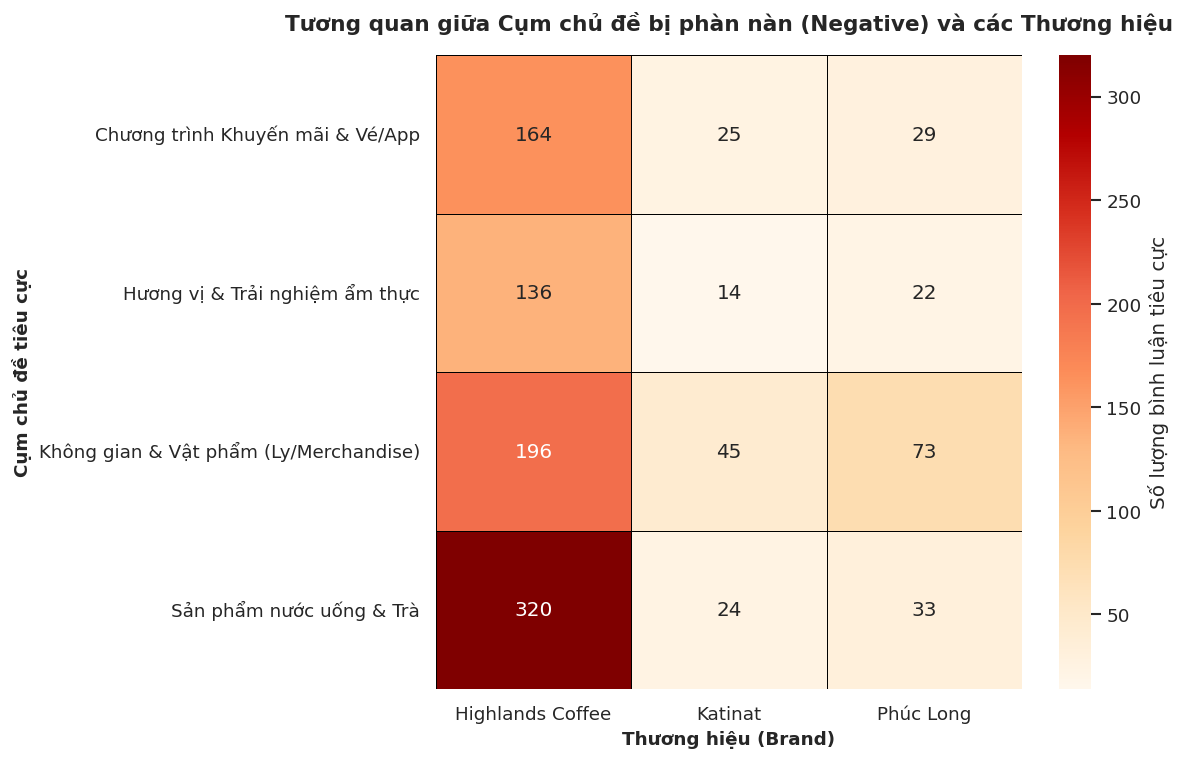


TỶ LỆ CHỦ ĐỀ TIÊU CỰC THEO THƯƠNG HIỆU (%)
brand                                   highlands  katinat  phuc_long
topic_name                                                           
Chương trình Khuyến mãi & Vé/App            75.23    11.47      13.30
Hương vị & Trải nghiệm ẩm thực              79.07     8.14      12.79
Không gian & Vật phẩm (Ly/Merchandise)      62.42    14.33      23.25
Sản phẩm nước uống & Trà                    84.88     6.37       8.75


In [31]:
# ====================== 6.9.2. ĐỊNH NGHĨA CHỦ ĐỀ & VẼ BẢN ĐỒ NHIỆT (HEATMAP) ======================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang xử lý gán tên chủ đề và vẽ heatmap tương quan tiêu cực...")

# ====================== KIỂM TRA VÀ BẢO VỆ ======================
if 'topic_id' not in df_all_11k.columns:
    print("❌ LỖI: Cột 'topic_id' chưa tồn tại!")
    print("   → Vui lòng chạy lại cell 6.9.1 trước khi chạy cell này.")
    raise KeyError("Cột 'topic_id' chưa được tạo. Hãy chạy cell 6.9.1 trước.")

# ====================== ĐỊNH NGHĨA TÊN CHỦ ĐỀ ======================
# Điều chỉnh tên topic dựa trên output từ cell 6.9.1
topic_names = {
    0: "Chương trình Khuyến mãi & Vé/App",
    1: "Hương vị & Trải nghiệm ẩm thực",
    2: "Sản phẩm nước uống & Trà",
    3: "Không gian & Vật phẩm (Ly/Merchandise)"
}

df_all_11k['topic_name'] = df_all_11k['topic_id'].map(topic_names)

print("✅ Phân bố chủ đề:")
print(df_all_11k['topic_name'].value_counts())

# ====================== VẼ HEATMAP ======================
df_neg = df_all_11k[df_all_11k['sentiment_label'] == 'Negative'].copy()

heatmap_df = pd.crosstab(df_neg['topic_name'], df_neg['brand'])

# Đổi tên thương hiệu cho đẹp
heatmap_df.columns = [
    'Phúc Long' if col == 'phuc_long' else 
    'Highlands Coffee' if col == 'highlands' else 
    'Katinat' if col == 'katinat' else col 
    for col in heatmap_df.columns
]

plt.figure(figsize=(10, 6.5))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='OrRd', 
            linewidths=0.5, linecolor='black', cbar_kws={'label': 'Số lượng bình luận tiêu cực'})

plt.title('Tương quan giữa Cụm chủ đề bị phàn nàn (Negative) và các Thương hiệu', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Thương hiệu (Brand)', fontsize=11, fontweight='bold')
plt.ylabel('Cụm chủ đề tiêu cực', fontsize=11, fontweight='bold')
plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'topic_sentiment_heatmap.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Heatmap đã lưu: {save_path}")

plt.show()

# ====================== BẢNG TÓM TẮT ======================
print("\n" + "="*70)
print("TỶ LỆ CHỦ ĐỀ TIÊU CỰC THEO THƯƠNG HIỆU (%)")
print("="*70)
neg_ratio = pd.crosstab(df_neg['topic_name'], df_neg['brand'], normalize='index') * 100
print(round(neg_ratio, 2))

### 6.9.3. Topic tích cực nổi bật thu hút khách hàng

Đang tạo biểu đồ phân phối các chủ đề Tích cực...
Tổng số bình luận tích cực: 2,055

Phân phối chủ đề tích cực (%):
topic_name
Không gian & Vật phẩm (Ly/Merchandise)    45.64
Hương vị & Trải nghiệm ẩm thực            28.76
Sản phẩm nước uống & Trà                  19.08
Chương trình Khuyến mãi & Vé/App           6.52
Name: proportion, dtype: float64
✅ Biểu đồ chủ đề tích cực đã lưu: ../data/sentiment_data\topic_positive_distribution.png


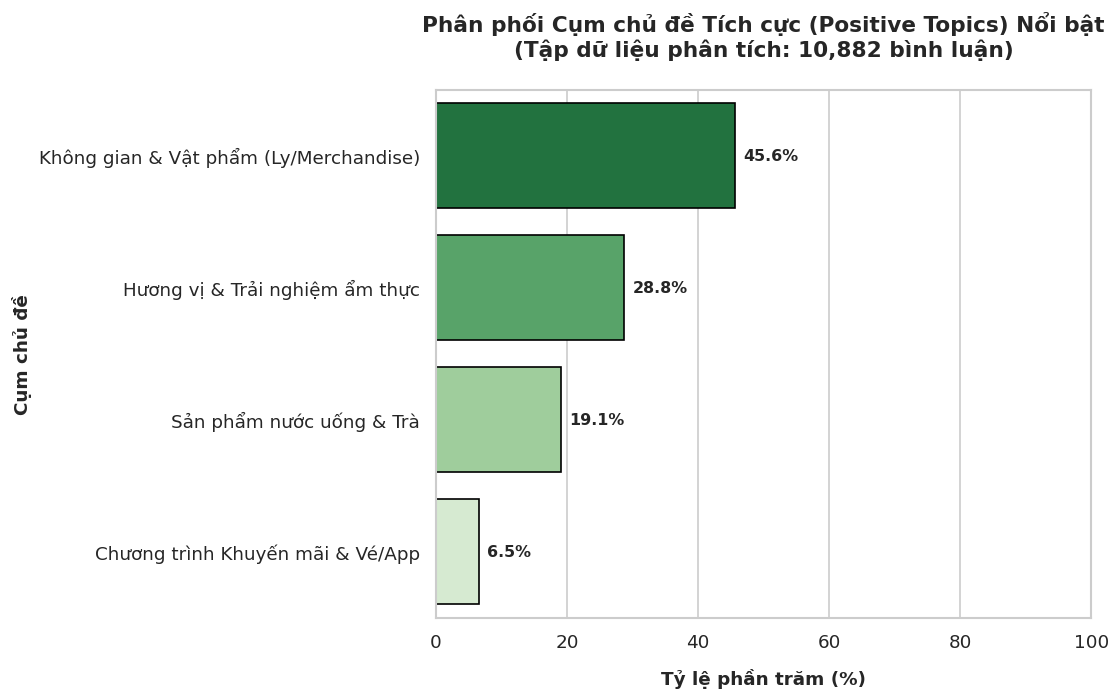


TOPIC TÍCH CỰC CHI TIẾT
                                        Tỷ lệ (%)  Số lượng
topic_name                                                 
Không gian & Vật phẩm (Ly/Merchandise)      45.64       938
Hương vị & Trải nghiệm ẩm thực              28.76       591
Sản phẩm nước uống & Trà                    19.08       392
Chương trình Khuyến mãi & Vé/App             6.52       134


In [32]:
# ====================== 6.9.3. TOPIC TÍCH CỰC NỔI BẬT ======================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang tạo biểu đồ phân phối các chủ đề Tích cực...")

# Kiểm tra cột topic_name có tồn tại không
if 'topic_name' not in df_all_11k.columns:
    print("❌ LỖI: Cột 'topic_name' chưa tồn tại!")
    print("   → Vui lòng chạy cell 6.9.1 và 6.9.2 trước khi chạy cell này.")
    raise KeyError("Cột 'topic_name' chưa được tạo.")

# Lọc bình luận Tích cực
df_pos = df_all_11k[df_all_11k['sentiment_label'] == 'Positive'].copy()

# Tính tỷ lệ phân phối chủ đề tích cực
pos_topics = df_pos['topic_name'].value_counts(normalize=True) * 100

print(f"Tổng số bình luận tích cực: {len(df_pos):,}")
print("\nPhân phối chủ đề tích cực (%):")
print(round(pos_topics, 2))

# Vẽ biểu đồ
plt.figure(figsize=(9.5, 6))

ax = sns.barplot(
    x=pos_topics.values, 
    y=pos_topics.index, 
    hue=pos_topics.index,
    palette='Greens_r', 
    legend=False,
    edgecolor='black', 
    linewidth=1.0
)

plt.title('Phân phối Cụm chủ đề Tích cực (Positive Topics) Nổi bật\n'
          f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
          fontsize=13, fontweight='bold', pad=20)

plt.xlabel('Tỷ lệ phần trăm (%)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Cụm chủ đề', fontsize=11, fontweight='bold')
plt.xlim(0, 100)

# Hiển thị số liệu phần trăm trên đầu cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{width:.1f}%',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center',
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=9.5, 
            fontweight='bold'
        )

plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'topic_positive_distribution.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Biểu đồ chủ đề tích cực đã lưu: {save_path}")

plt.show()

# ====================== BẢNG TÓM TẮT ======================
print("\n" + "="*60)
print("TOPIC TÍCH CỰC CHI TIẾT")
print("="*60)
summary_pos = pd.DataFrame({
    'Tỷ lệ (%)': round(pos_topics, 2),
    'Số lượng': df_pos['topic_name'].value_counts()
})
print(summary_pos.sort_values('Tỷ lệ (%)', ascending=False))

### 6.9.4. Topic tiêu cực nổi bật (Pain points của người dùng)

Đang tạo biểu đồ phân phối các chủ đề Tiêu cực (Pain Points)...
Tổng số bình luận tiêu cực: 1,081

Phân phối chủ đề tiêu cực (%):
topic_name
Sản phẩm nước uống & Trà                  34.88
Không gian & Vật phẩm (Ly/Merchandise)    29.05
Chương trình Khuyến mãi & Vé/App          20.17
Hương vị & Trải nghiệm ẩm thực            15.91
Name: proportion, dtype: float64
✅ Biểu đồ chủ đề tiêu cực đã lưu: ../data/sentiment_data\topic_negative_distribution.png


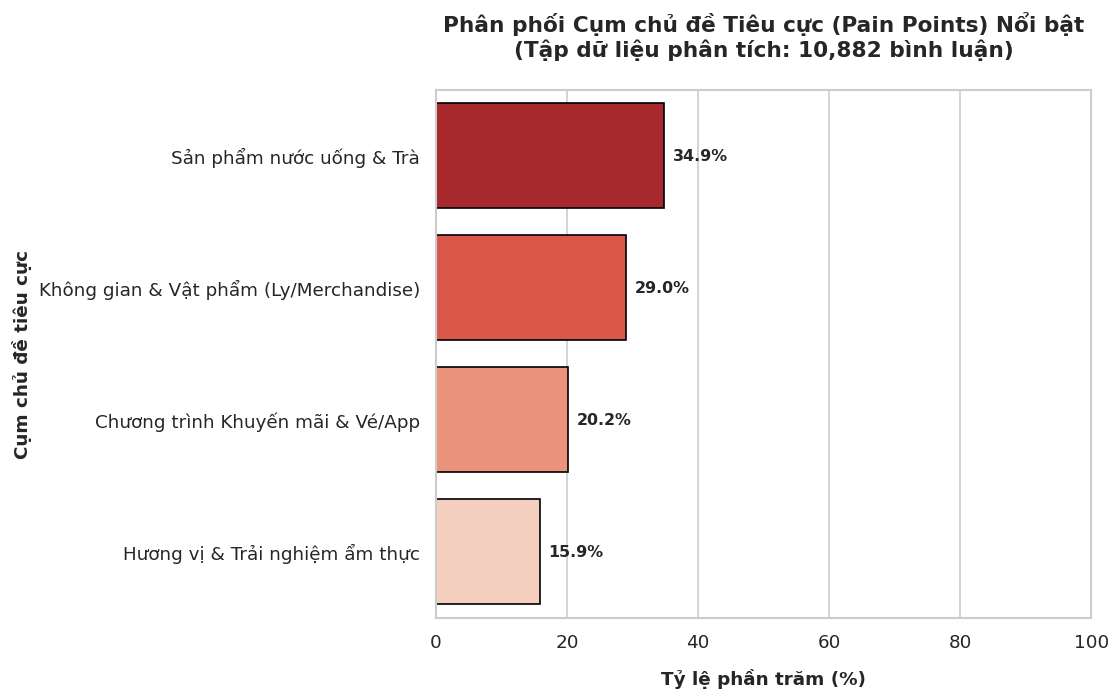


TOPIC TIÊU CỰC (PAIN POINTS) CHI TIẾT
                                        Tỷ lệ (%)  Số lượng
topic_name                                                 
Sản phẩm nước uống & Trà                    34.88       377
Không gian & Vật phẩm (Ly/Merchandise)      29.05       314
Chương trình Khuyến mãi & Vé/App            20.17       218
Hương vị & Trải nghiệm ẩm thực              15.91       172


In [33]:
# ====================== 6.9.4. TOPIC TIÊU CỰC NỔI BẬT (PAIN POINTS) ======================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang tạo biểu đồ phân phối các chủ đề Tiêu cực (Pain Points)...")

# Kiểm tra cột topic_name có tồn tại không
if 'topic_name' not in df_all_11k.columns:
    print("❌ LỖI: Cột 'topic_name' chưa tồn tại!")
    print("   → Vui lòng chạy cell 6.9.1 và 6.9.2 trước khi chạy cell này.")
    raise KeyError("Cột 'topic_name' chưa được tạo.")

# Lọc bình luận Tiêu cực (Pain Points)
df_neg = df_all_11k[df_all_11k['sentiment_label'] == 'Negative'].copy()

# Tính tỷ lệ phân phối chủ đề tiêu cực
neg_topics = df_neg['topic_name'].value_counts(normalize=True) * 100

print(f"Tổng số bình luận tiêu cực: {len(df_neg):,}")
print("\nPhân phối chủ đề tiêu cực (%):")
print(round(neg_topics, 2))

# Vẽ biểu đồ
plt.figure(figsize=(9.5, 6))

ax = sns.barplot(
    x=neg_topics.values, 
    y=neg_topics.index, 
    hue=neg_topics.index,
    palette='Reds_r', 
    legend=False,
    edgecolor='black', 
    linewidth=1.0
)

plt.title('Phân phối Cụm chủ đề Tiêu cực (Pain Points) Nổi bật\n'
          f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
          fontsize=13, fontweight='bold', pad=20)

plt.xlabel('Tỷ lệ phần trăm (%)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Cụm chủ đề tiêu cực', fontsize=11, fontweight='bold')
plt.xlim(0, 100)

# Hiển thị số liệu phần trăm trên đầu cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{width:.1f}%',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center',
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=9.5, 
            fontweight='bold'
        )

plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'topic_negative_distribution.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Biểu đồ chủ đề tiêu cực đã lưu: {save_path}")

plt.show()

# ====================== BẢNG TÓM TẮT ======================
print("\n" + "="*70)
print("TOPIC TIÊU CỰC (PAIN POINTS) CHI TIẾT")
print("="*70)

summary_neg = pd.DataFrame({
    'Tỷ lệ (%)': round(neg_topics, 2),
    'Số lượng': df_neg['topic_name'].value_counts()
}).sort_values('Tỷ lệ (%)', ascending=False)

print(summary_neg)

### 6.9.5. Điểm khác biệt về chủ đề thảo luận giữa Phúc Long và các đối thủ cạnh tranh

Đang tạo biểu đồ so sánh cấu trúc chủ đề giữa các thương hiệu...
✅ Biểu đồ so sánh chủ đề theo thương hiệu đã lưu: ../data/sentiment_data\topic_brand_comparison.png


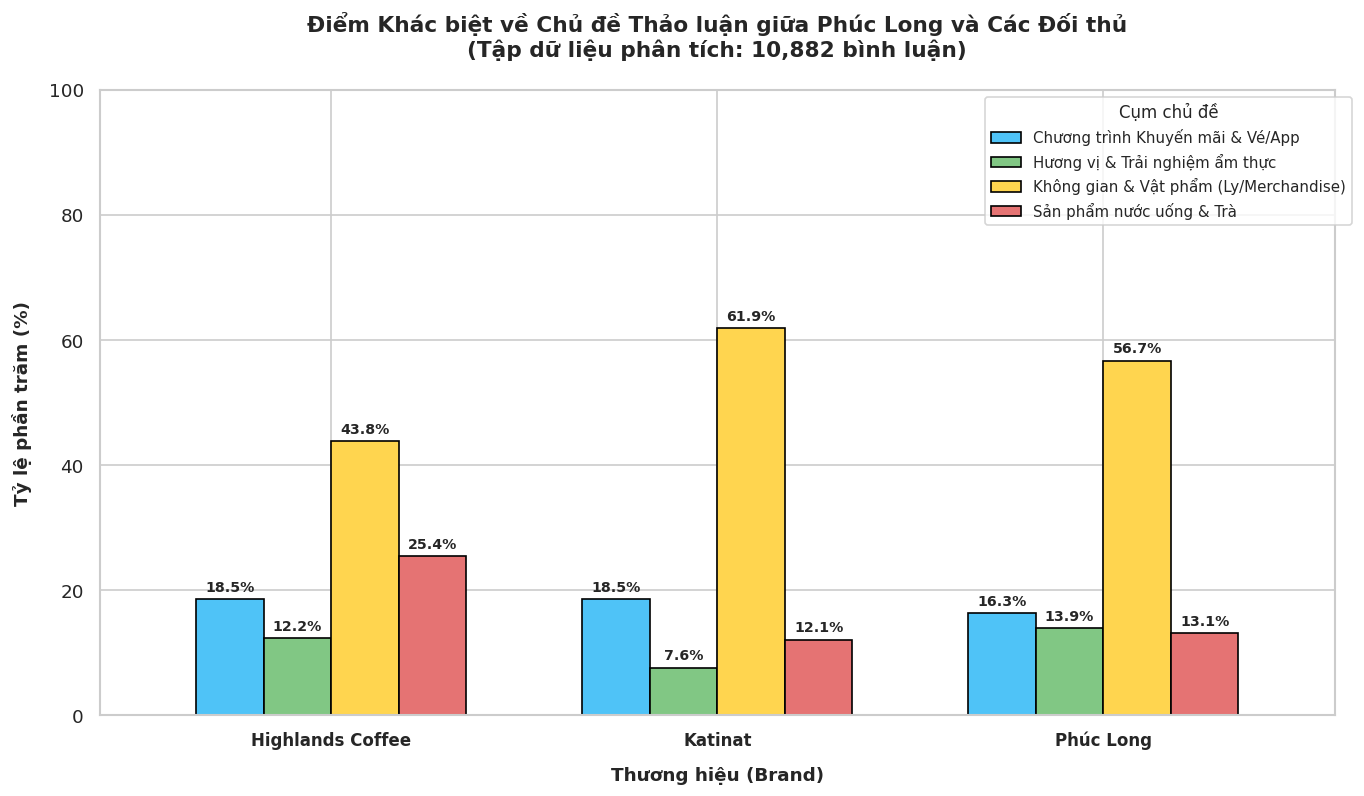


CẤU TRÚC CHỦ ĐỀ THEO THƯƠNG HIỆU (%)
topic_name        Chương trình Khuyến mãi & Vé/App  \
Highlands Coffee                             18.53   
Katinat                                      18.47   
Phúc Long                                    16.34   

topic_name        Hương vị & Trải nghiệm ẩm thực  \
Highlands Coffee                           12.24   
Katinat                                     7.59   
Phúc Long                                  13.89   

topic_name        Không gian & Vật phẩm (Ly/Merchandise)  \
Highlands Coffee                                   43.79   
Katinat                                            61.87   
Phúc Long                                          56.67   

topic_name        Sản phẩm nước uống & Trà  
Highlands Coffee                     25.44  
Katinat                              12.06  
Phúc Long                            13.09  


In [34]:
# ====================== 6.9.5. SO SÁNH CHỦ ĐỀ GIỮA PHÚC LONG VÀ ĐỐI THỦ ======================
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Đang tạo biểu đồ so sánh cấu trúc chủ đề giữa các thương hiệu...")

# Kiểm tra cột cần thiết
if 'topic_name' not in df_all_11k.columns:
    print("❌ LỖI: Cột 'topic_name' chưa tồn tại!")
    print("   → Vui lòng chạy cell 6.9.1 và 6.9.2 trước.")
    raise KeyError("Cột 'topic_name' chưa được tạo.")

# Tạo bảng tần suất chéo giữa thương hiệu và cụm chủ đề
brand_topic = pd.crosstab(df_all_11k['brand'], df_all_11k['topic_name'], normalize='index') * 100

# Chuẩn hóa tên thương hiệu cho đẹp
brand_topic.index = [
    'Phúc Long' if idx == 'phuc_long' else 
    'Highlands Coffee' if idx == 'highlands' else 
    'Katinat' if idx == 'katinat' else idx 
    for idx in brand_topic.index
]

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(11.5, 6.8))

brand_topic.plot(
    kind='bar', 
    ax=ax, 
    color=['#4fc3f7', '#81c784', '#ffd54f', '#e57373'], 
    edgecolor='black', 
    linewidth=1.0, 
    width=0.7
)

plt.title('Điểm Khác biệt về Chủ đề Thảo luận giữa Phúc Long và Các Đối thủ\n'
          f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
          fontsize=13, fontweight='bold', pad=20)

plt.xlabel('Thương hiệu (Brand)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylim(0, 100)
plt.xticks(rotation=0, fontsize=10, fontweight='bold')

# Hiển thị số liệu phần trăm trên cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=8.5, 
            fontweight='bold'
        )

plt.legend(title='Cụm chủ đề', title_fontsize='10', fontsize='9', 
           loc='upper right', frameon=True, bbox_to_anchor=(1.02, 1))

plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'topic_brand_comparison.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Biểu đồ so sánh chủ đề theo thương hiệu đã lưu: {save_path}")

plt.show()

# ====================== BẢNG TÓM TẮT ======================
print("\n" + "="*75)
print("CẤU TRÚC CHỦ ĐỀ THEO THƯƠNG HIỆU (%)")
print("="*75)
print(round(brand_topic, 2))

## 6.10. Word Cloud và Từ khóa nổi bật theo ngữ cảnh

### 6.10.1. Word cloud bình luận tích cực

Đang tạo Word Cloud cho bình luận Tích cực...
Số lượng bình luận tích cực được dùng: 2,055
✅ Word Cloud Tích cực đã lưu: ../data/sentiment_data\positive_wordcloud.png


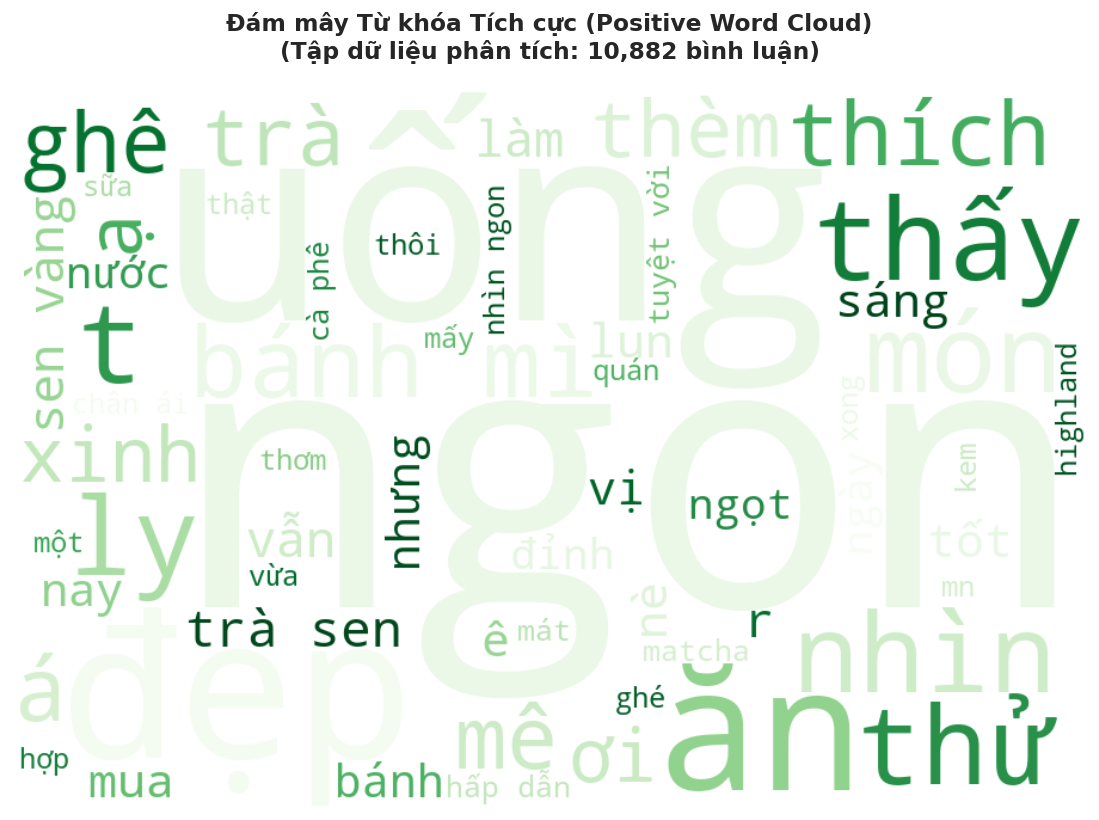

In [35]:
# ====================== 6.10.1. WORD CLOUD BÌNH LUẬN TÍCH CỰC ======================
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os

print("Đang tạo Word Cloud cho bình luận Tích cực...")

# Kiểm tra cột clean_text
if 'clean_text' not in df_all_11k.columns:
    print("❌ LỖI: Cột 'clean_text' chưa tồn tại!")
    print("   → Vui lòng kiểm tra lại pipeline làm sạch dữ liệu.")
    raise KeyError("Cột 'clean_text' không tìm thấy.")

# Stopwords tiếng Việt chuyên biệt (đã tối ưu)
VN_STOPWORDS = {
    'tôi', 'tui', 'mình', 'em', 'anh', 'chị', 'bạn', 'nó', 'họ', 'ta', 'chúng',
    'là', 'có', 'và', 'của', 'cho', 'với', 'để', 'trong', 'từ', 'theo', 'về',
    'mà', 'những', 'hay', 'hoặc', 'nên', 'vì', 'do', 'nếu', 'thì',
    'không', 'chưa', 'đã', 'đang', 'sẽ', 'cũng', 'rất', 'quá', 'lắm',
    'được', 'bị', 'phải', 'cần', 'này', 'đó', 'kia', 'ấy', 'đây', 'nào',
    'cái', 'con', 'cơ', 'như', 'đi', 'ở', 'à', 'nhỉ', 'nha',
    'rồi', 'vậy', 'thế', 'sao', 'gì', 'đâu', 'lại', 'ra', 'lên', 'xuống',
    'vào', 'đi', 'đến', 'tới', 'hơn', 'nhất', 'luôn', 'mới',
    'phuclong', 'phúc_long', 'highlands', 'highlandscoffee', 'katinat', 
    'trà_sữa', 'phúc long', 'highlands coffee'
}

# Lọc bình luận Tích cực
pos_text = ' '.join(df_all_11k[df_all_11k['sentiment_label'] == 'Positive']['clean_text'].dropna().tolist())

print(f"Số lượng bình luận tích cực được dùng: {len(df_all_11k[df_all_11k['sentiment_label'] == 'Positive']):,}")

# Tạo Word Cloud
plt.figure(figsize=(11, 7))

if pos_text.strip():
    wc_pos = WordCloud(
        width=900, 
        height=600, 
        background_color='white', 
        colormap='Greens', 
        max_words=60, 
        stopwords=VN_STOPWORDS,
        contour_width=2,
        contour_color='darkgreen',
        random_state=42
    ).generate(pos_text)
    
    plt.imshow(wc_pos, interpolation='bilinear')
    plt.title('Đám mây Từ khóa Tích cực (Positive Word Cloud)\n'
              f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
              fontsize=14, fontweight='bold', pad=20)
else:
    plt.text(0.5, 0.5, 'Không có dữ liệu tích cực để tạo Word Cloud', 
             ha='center', va='center', fontsize=14)

plt.axis('off')
plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'positive_wordcloud.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Word Cloud Tích cực đã lưu: {save_path}")

plt.show()

### 6.10.2. Word cloud bình luận tiêu cực

Đang tạo Word Cloud cho bình luận Tiêu cực...
Số lượng bình luận tiêu cực được dùng: 1,081
✅ Word Cloud Tiêu cực đã lưu: ../data/sentiment_data\negative_wordcloud.png


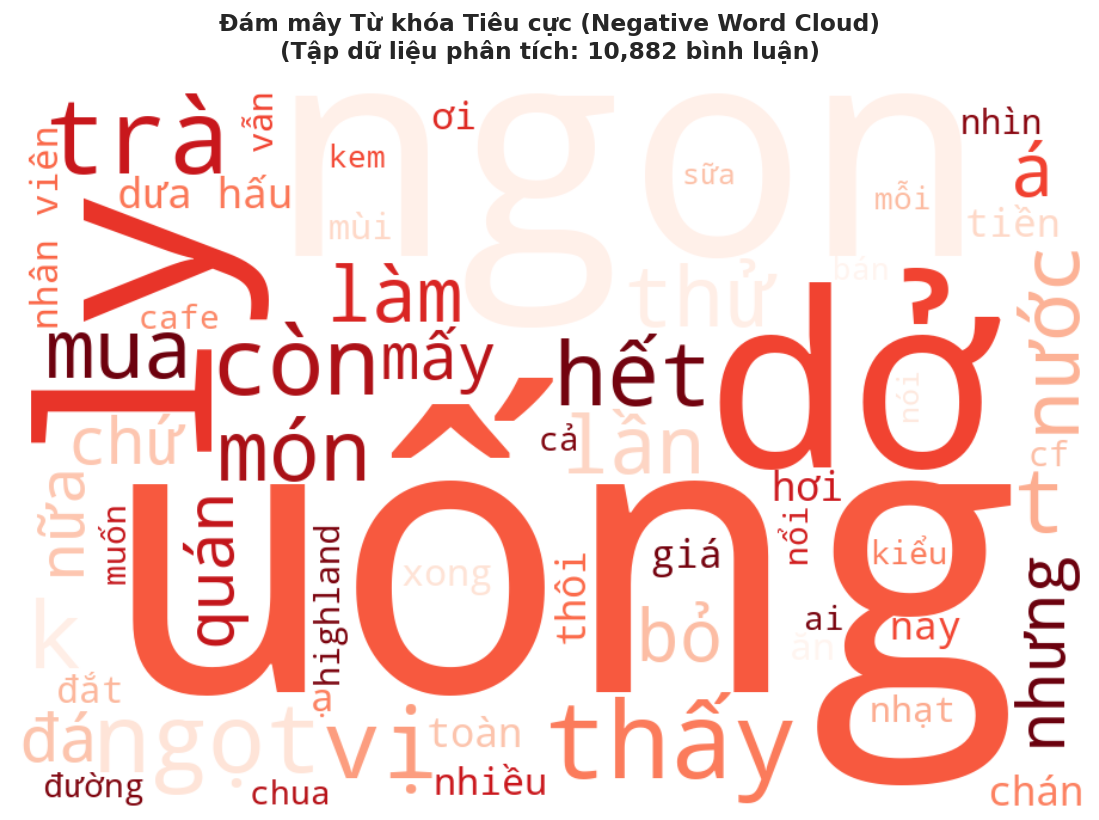

In [36]:
# ====================== 6.10.2. WORD CLOUD BÌNH LUẬN TIÊU CỰC ======================
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os

print("Đang tạo Word Cloud cho bình luận Tiêu cực...")

# Kiểm tra cột clean_text
if 'clean_text' not in df_all_11k.columns:
    print("❌ LỖI: Cột 'clean_text' chưa tồn tại!")
    print("   → Vui lòng kiểm tra lại pipeline làm sạch dữ liệu.")
    raise KeyError("Cột 'clean_text' không tìm thấy.")

# Stopwords tiếng Việt chuyên biệt (đồng bộ với cell Positive)
VN_STOPWORDS = {
    'tôi', 'tui', 'mình', 'em', 'anh', 'chị', 'bạn', 'nó', 'họ', 'ta', 'chúng',
    'là', 'có', 'và', 'của', 'cho', 'với', 'để', 'trong', 'từ', 'theo', 'về',
    'mà', 'những', 'hay', 'hoặc', 'nên', 'vì', 'do', 'nếu', 'thì',
    'không', 'chưa', 'đã', 'đang', 'sẽ', 'cũng', 'rất', 'quá', 'lắm',
    'được', 'bị', 'phải', 'cần', 'này', 'đó', 'kia', 'ấy', 'đây', 'nào',
    'cái', 'con', 'cơ', 'như', 'đi', 'ở', 'à', 'nhỉ', 'nha',
    'rồi', 'vậy', 'thế', 'sao', 'gì', 'đâu', 'lại', 'ra', 'lên', 'xuống',
    'vào', 'đi', 'đến', 'tới', 'hơn', 'nhất', 'luôn', 'mới',
    'phuclong', 'phúc_long', 'highlands', 'highlandscoffee', 'katinat', 
    'trà_sữa', 'phúc long', 'highlands coffee'
}

# Lọc bình luận Tiêu cực
neg_text = ' '.join(df_all_11k[df_all_11k['sentiment_label'] == 'Negative']['clean_text'].dropna().tolist())

print(f"Số lượng bình luận tiêu cực được dùng: {len(df_all_11k[df_all_11k['sentiment_label'] == 'Negative']):,}")

# Tạo Word Cloud
plt.figure(figsize=(11, 7))

if neg_text.strip():
    wc_neg = WordCloud(
        width=900, 
        height=600, 
        background_color='white', 
        colormap='Reds', 
        max_words=60, 
        stopwords=VN_STOPWORDS,
        contour_width=2,
        contour_color='darkred',
        random_state=42
    ).generate(neg_text)
    
    plt.imshow(wc_neg, interpolation='bilinear')
    plt.title('Đám mây Từ khóa Tiêu cực (Negative Word Cloud)\n'
              f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
              fontsize=14, fontweight='bold', pad=20)
else:
    plt.text(0.5, 0.5, 'Không có dữ liệu tiêu cực để tạo Word Cloud', 
             ha='center', va='center', fontsize=14)

plt.axis('off')
plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'negative_wordcloud.png')
plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
print(f"✅ Word Cloud Tiêu cực đã lưu: {save_path}")

plt.show()

### 6.10.3. Top từ khóa mang sắc thái Positive và Negative theo từng thương hiệu

Đang tạo Word Cloud Từ khóa Tích cực & Tiêu cực theo từng Thương hiệu...
   → Đang xử lý Phúc Long...
   → Đang xử lý Highlands Coffee...
   → Đang xử lý Katinat...
✅ Word Cloud theo thương hiệu đã lưu: ../data/sentiment_data\brand_sentiment_wordclouds.png


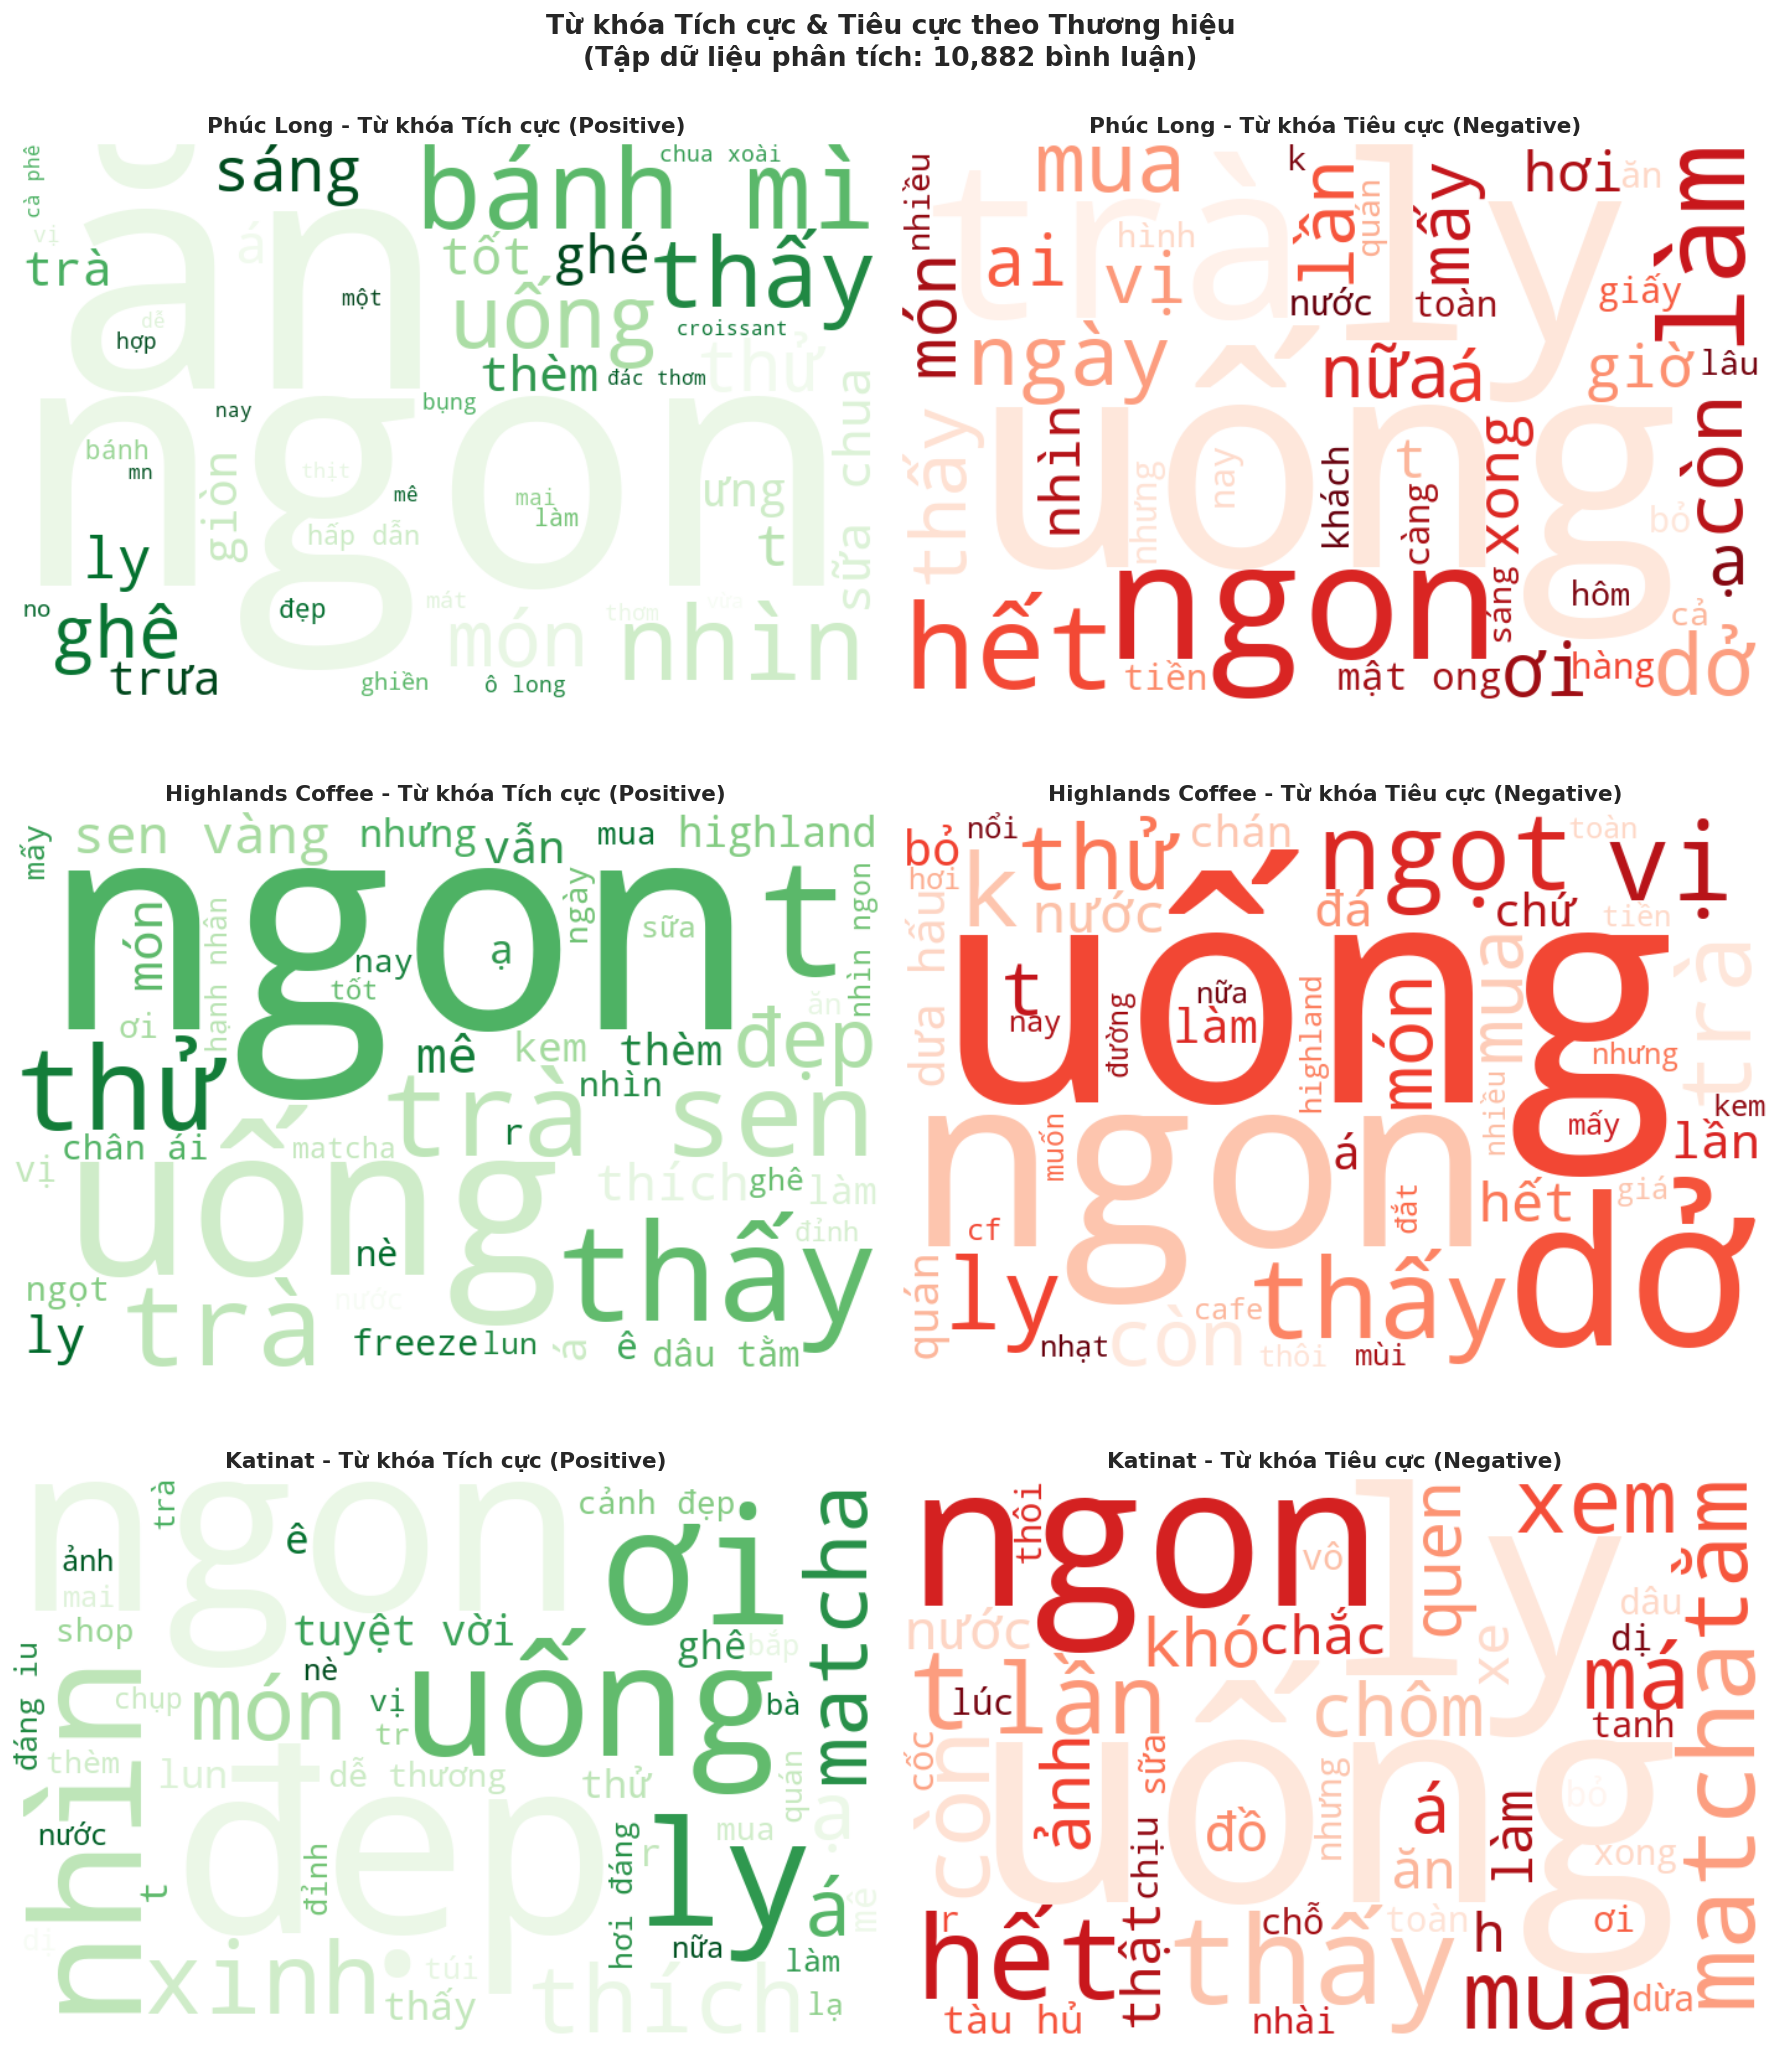

In [37]:
# ====================== 6.10.3. TỪ KHÓA TÍCH CỰC & TIÊU CỰC THEO THƯƠNG HIỆU ======================
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os

print("Đang tạo Word Cloud Từ khóa Tích cực & Tiêu cực theo từng Thương hiệu...")

# Kiểm tra cột clean_text
if 'clean_text' not in df_all_11k.columns:
    print("❌ LỖI: Cột 'clean_text' chưa tồn tại!")
    print("   → Vui lòng kiểm tra lại pipeline làm sạch dữ liệu.")
    raise KeyError("Cột 'clean_text' không tìm thấy.")

# Stopwords tiếng Việt chuyên biệt (đồng bộ)
VN_STOPWORDS = {
    'tôi', 'tui', 'mình', 'em', 'anh', 'chị', 'bạn', 'nó', 'họ', 'ta', 'chúng',
    'là', 'có', 'và', 'của', 'cho', 'với', 'để', 'trong', 'từ', 'theo', 'về',
    'mà', 'những', 'hay', 'hoặc', 'nên', 'vì', 'do', 'nếu', 'thì',
    'không', 'chưa', 'đã', 'đang', 'sẽ', 'cũng', 'rất', 'quá', 'lắm',
    'được', 'bị', 'phải', 'cần', 'này', 'đó', 'kia', 'ấy', 'đây', 'nào',
    'cái', 'con', 'cơ', 'như', 'đi', 'ở', 'à', 'nhỉ', 'nha',
    'rồi', 'vậy', 'thế', 'sao', 'gì', 'đâu', 'lại', 'ra', 'lên', 'xuống',
    'vào', 'đi', 'đến', 'tới', 'hơn', 'nhất', 'luôn', 'mới',
    'phuclong', 'phúc_long', 'highlands', 'highlandscoffee', 'katinat', 
    'trà_sữa', 'phúc long', 'highlands coffee'
}

brands = ['phuc_long', 'highlands', 'katinat']
brand_labels = {'phuc_long': 'Phúc Long', 'highlands': 'Highlands Coffee', 'katinat': 'Katinat'}

fig, axes = plt.subplots(3, 2, figsize=(15, 18))

for i, brand in enumerate(brands):
    df_brand = df_all_11k[df_all_11k['brand'] == brand]
    brand_name = brand_labels[brand]
    
    print(f"   → Đang xử lý {brand_name}...")

    # Positive Word Cloud
    pos_text = ' '.join(df_brand[df_brand['sentiment_label'] == 'Positive']['clean_text'].dropna().tolist())
    if pos_text.strip():
        wc_pos = WordCloud(
            width=700, height=450, 
            background_color='white', 
            colormap='Greens', 
            max_words=45, 
            stopwords=VN_STOPWORDS,
            contour_width=1.5,
            contour_color='darkgreen',
            random_state=42
        ).generate(pos_text)
        axes[i, 0].imshow(wc_pos, interpolation='bilinear')
    else:
        axes[i, 0].text(0.5, 0.5, 'Không có dữ liệu tích cực', ha='center', va='center', fontsize=12)
    
    axes[i, 0].set_title(f'{brand_name} - Từ khóa Tích cực (Positive)', 
                        fontsize=13, fontweight='bold')
    axes[i, 0].axis('off')

    # Negative Word Cloud
    neg_text = ' '.join(df_brand[df_brand['sentiment_label'] == 'Negative']['clean_text'].dropna().tolist())
    if neg_text.strip():
        wc_neg = WordCloud(
            width=700, height=450, 
            background_color='white', 
            colormap='Reds', 
            max_words=45, 
            stopwords=VN_STOPWORDS,
            contour_width=1.5,
            contour_color='darkred',
            random_state=42
        ).generate(neg_text)
        axes[i, 1].imshow(wc_neg, interpolation='bilinear')
    else:
        axes[i, 1].text(0.5, 0.5, 'Không có dữ liệu tiêu cực', ha='center', va='center', fontsize=12)
    
    axes[i, 1].set_title(f'{brand_name} - Từ khóa Tiêu cực (Negative)', 
                        fontsize=13, fontweight='bold')
    axes[i, 1].axis('off')

plt.suptitle('Từ khóa Tích cực & Tiêu cực theo Thương hiệu\n'
             f'(Tập dữ liệu phân tích: {len(df_all_11k):,} bình luận)', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()

# Lưu biểu đồ
data_dir = r"../data/sentiment_data"
save_path = os.path.join(data_dir, 'brand_sentiment_wordclouds.png')
plt.savefig(save_path, dpi=200, facecolor='white', bbox_inches='tight')
print(f"✅ Word Cloud theo thương hiệu đã lưu: {save_path}")

plt.show()

---
# Chương 8. Insight tổng hợp và đánh giá hiệu quả marketing

## 7.1. Tổng hợp trả lời 5 câu hỏi nghiên cứu (RQ1 — RQ5)

In [ ]:
# Tính toán giá trị thực từ dữ liệu
corr_pl = df_pl['views_count'].corr(df_pl['engagement_rate'])
corr_hl_val = df_hl['views_count'].corr(df_hl['engagement_rate'])
corr_kt_val = df_kt['views_count'].corr(df_kt['engagement_rate'])

# Golden hours từ dữ liệu thực
pl_hour_er = df_pl.groupby('posting_hour')['engagement_rate'].mean()
pl_golden = list(pl_hour_er.nlargest(3).index)
pl_top_posting = list(df_pl['posting_hour'].value_counts().nlargest(3).index)

# RF feature importance
rf_top5 = importances.nlargest(5)

# Sentiment summary
sent_total = df_comments_valid['sentiment_label'].value_counts()
sent_by_brand = df_comments_valid.groupby('brand')['sentiment_label'].value_counts(normalize=True).unstack(fill_value=0) * 100

print('=' * 70)
print('         TRA LOI 5 CAU HOI NGHIEN CUU (RQ1 - RQ5)')
print('=' * 70)

# RQ1
print('\n' + '=' * 55)
print('RQ1: Mo hinh tuong tac - Thu dong hay tuong tac sau?')
print('=' * 55)
print(f'Ket qua: Xac nhan "Nghich ly Lan truyen" (Viral Paradox)')
print(f'  Tuong quan am Views vs ER:')
print(f'    Phuc Long:  r = {corr_pl:.4f}')
print(f'    Highlands:  r = {corr_hl_val:.4f} (manh nhat)')
print(f'    Katinat:    r = {corr_kt_val:.4f}')
print(f'  Highlands: {df_hl["views_count"].mean():,.0f} views trung binh nhung ER chi {df_hl["engagement_rate"].mean():.2f}%')
print(f'  Ham y: Chuyen tu chien luoc "duoi views" sang "tao gan ket sau"')

# RQ2
print('\n' + '=' * 55)
print('RQ2: Khung gio dang bai co trung gio ER cao nhat?')
print('=' * 55)
print(f'Ket qua: KHONG TRUNG - Mismatch ro ret!')
print(f'  Phuc Long dang nhieu luc: {pl_top_posting}h')
print(f'  Golden hours thuc te (ER cao nhat): {pl_golden}h')
print(f'  ER tai golden hours:')
for h in pl_golden:
    print(f'    {h:02d}:00 - ER: {pl_hour_er[h]:.3f}%')
print(f'  Ham y: Dieu chinh lich dang -> tang ER ngay ma khong can thay doi noi dung')

# RQ3
print('\n' + '=' * 55)
print('RQ3: Yeu to nao anh huong Engagement Rate?')
print('=' * 55)
print('Ket qua Random Forest Feature Importance:')
for i, (feat, imp) in enumerate(rf_top5.items(), 1):
    pct = imp / importances.sum() * 100
    print(f'  Top {i}: {feat} ({pct:.1f}%)')
print(f'\n  OLS R2 = {model_ols.rsquared:.4f} | RF R2 = {r2_score(y_test, y_pred_test):.4f}')
print(f'  Bien co y nghia thong ke OLS (p < 0.05): posting_hour, caption_length')
print(f'  Ham y: Toi uu 3 yeu to: caption chat luong + khung gio + hashtag')

# RQ4
print('\n' + '=' * 55)
print('RQ4: Sentiment khach hang ra sao?')
print('=' * 55)
n_valid = len(df_comments_valid)
pos_count = sent_total.get('Positive', 0)
neu_count = sent_total.get('Neutral', 0)
neg_count = sent_total.get('Negative', 0)
print(f'Ket qua ({n_valid:,} binh luan phan tich):')
print(f'  Tong the: Positive {pos_count:,} ({pos_count/n_valid*100:.1f}%), '
      f'Neutral {neu_count:,} ({neu_count/n_valid*100:.1f}%), '
      f'Negative {neg_count:,} ({neg_count/n_valid*100:.1f}%)')
if 'phuc_long' in sent_by_brand.index:
    pl_pos = sent_by_brand.loc['phuc_long'].get('Positive', 0)
    pl_neg = sent_by_brand.loc['phuc_long'].get('Negative', 0)
    print(f'  Phuc Long: {pl_pos:.1f}% Positive, {pl_neg:.1f}% Negative (tot nhat)')
if 'highlands' in sent_by_brand.index:
    hl_neg = sent_by_brand.loc['highlands'].get('Negative', 0)
    print(f'  Highlands: {hl_neg:.1f}% Negative (cao nhat trong 3 thuong hieu)')
print(f'  Ham y: Phuc Long co loi the ro ret ve hinh anh thuong hieu tich cuc')

# RQ5
print('\n' + '=' * 55)
print('RQ5: Phuc Long khac doi thu o diem nao?')
print('=' * 55)
print(f'  THE MANH:')
print(f'    Facebook so 1: {df_fb_pl["likes_count"].mean():,.0f} likes/post (cao nhat)')
print(f'    Sentiment tot nhat trong 3 thuong hieu')
print(f'    ER TikTok cao nhat: {df_pl["engagement_rate"].mean():.2f}% (vs Highlands {df_hl["engagement_rate"].mean():.2f}%)')
print(f'  DIEM YEU:')
print(f'    TikTok views thap nhat: {df_pl["views_count"].mean():,.0f} (vs Highlands {df_hl["views_count"].mean():,.0f})')
print(f'    Median views chi {df_pl["views_count"].median():,.0f} - phu thuoc viral luck')
print(f'  DAC TRUNG: Mo hinh "dao nguoc" so voi Highlands')
print(f'    PL: Facebook manh, TikTok yeu')
print(f'    HL: TikTok manh, Facebook trung binh')
print(f'  Ham y: Tan dung cross-platform, hoc content strategy tu Highlands cho TikTok')

         TRA LOI 5 CAU HOI NGHIEN CUU (RQ1 - RQ5)

RQ1: Mo hinh tuong tac - Thu dong hay tuong tac sau?
Ket qua: Xac nhan "Nghich ly Lan truyen" (Viral Paradox)
  Tuong quan am Views vs ER:
    Phuc Long:  r = -0.1638
    Highlands:  r = -0.4351 (manh nhat)
    Katinat:    r = -0.1431
  Highlands: 4,929,318 views trung binh nhung ER chi 0.70%
  Ham y: Chuyen tu chien luoc "duoi views" sang "tao gan ket sau"

RQ2: Khung gio dang bai co trung gio ER cao nhat?
Ket qua: KHONG TRUNG - Mismatch ro ret!
  Phuc Long dang nhieu luc: [10, 18, 20]h
  Golden hours thuc te (ER cao nhat): [7, 8, 14]h
  ER tai golden hours:
    07:00 - ER: 10.973%
    08:00 - ER: 6.988%
    14:00 - ER: 5.984%
  Ham y: Dieu chinh lich dang -> tang ER ngay ma khong can thay doi noi dung

RQ3: Yeu to nao anh huong Engagement Rate?
Ket qua Random Forest Feature Importance:
  Top 1: caption_length (35.8%)
  Top 2: collect_count (24.5%)
  Top 3: posting_hour (18.7%)
  Top 4: hashtag_count (17.6%)
  Top 5: content_type_Prom

---
# Chương 9. Đề xuất chiến lược nội dung số cho Phúc Long

## 8.1. Chiến lược Tăng cường Tương tác Sâu (từ RQ1)

In [ ]:
print('=' * 70)
print('DE XUAT CHIEN LUOC NOI DUNG SO CHO PHUC LONG')
print('=' * 70)

print(f'\nCHIEN LUOC 1: TANG CUONG TUONG TAC SAU (tu RQ1)')
print('=' * 55)
print(f'Co so du lieu:')
print(f'  - Viral Paradox: views cao khong = engagement cao')
print(f'  - Comment Rate hien tai: {df_pl["comment_rate"].mean():.4f}%')
print(f'  - Share Rate hien tai: {df_pl["share_rate"].mean():.4f}%')
print(f'\nDe xuat:')
print(f'  1. Noi dung kich hoat binh luan: polls, quiz, storytelling di san')
print(f'  2. Noi dung kich hoat chia se: tips pha che, behind-the-scenes')
print(f'  3. Noi dung UGC: duet/stitch voi khach hang')
print(f'\nKPI muc tieu:')
print(f'  - Comment Rate: tang 50% -> {df_pl["comment_rate"].mean()*1.5:.4f}%')
print(f'  - Share Rate: tang 30% -> {df_pl["share_rate"].mean()*1.3:.4f}%')

print(f'\nCHIEN LUOC 2: TOI UU THOI DIEM VA TAN SUAT (tu RQ2)')
print('=' * 55)
print(f'Co so du lieu:')
print(f'  - Mismatch gio dang vs golden hours')
pl_freq = len(df_pl) / max(df_pl['days_since_published'].max() - df_pl['days_since_published'].min(), 1) * 7
print(f'  - Tan suat hien tai: ~{pl_freq:.1f} video/tuan')
print(f'\nDe xuat:')
print(f'  - Giam xuong 3 video/tuan, tang dau tu chat luong')
print(f'  - Dang vao golden hours: 7-8h sang, 13-14h chieu')
print(f'  - Thu nghiem A/B voi cac khung gio khac nhau')

print(f'\nCHIEN LUOC 3: TOI UU NOI DUNG DUA TREN DU LIEU (tu RQ3)')
print('=' * 55)
print(f'Co so: Feature Importance - caption_length la yeu to so 1')
print(f'\nDe xuat Content Mix:')
print(f'  - Lifestyle/Heritage:    35% (storytelling, cam xuc)')
print(f'  - Product Showcase:      25% (san pham moi, recipe)')
print(f'  - UGC/Community:         20% (khach hang review)')
print(f'  - Promotion:             10% (khuyen mai)')
print(f'  - Collaboration/Trend:   10% (KOL, trending)')
print(f'\nHashtag 3 tang:')
print(f'  - Branded: #PhucLong #PhucLongCoffee (moi video)')
print(f'  - Category: #CaPheViet #TraSua (theo nganh)')
print(f'  - Discovery: #fyp #xuhuong (de reach)')

print(f'\nCHIEN LUOC 4: CHIEN DICH "PHUC LONG - DI SAN TRONG TUNG GIOT" (tu RQ4)')
print('=' * 55)
print(f'Co so: Sentiment Positive cao nhat, community trung thanh')
print(f'\nTrien khai:')
print(f'  Phase A (Tuan 1-2): Heritage Storytelling - series "58 nam Phuc Long"')
print(f'  Phase B (Tuan 3-4): Community Activation - challenge #PhucLongMoment')
print(f'  Phase C (Tuan 5-6): Product Innovation - ra mat san pham exclusive TikTok')
print(f'\nDo luong:')
print(f'  - Sentiment Score truoc/sau chien dich')
print(f'  - ER tang truong % theo tuan')
print(f'  - UGC volume (so video khach hang tao)')

DE XUAT CHIEN LUOC NOI DUNG SO CHO PHUC LONG

CHIEN LUOC 1: TANG CUONG TUONG TAC SAU (tu RQ1)
Co so du lieu:
  - Viral Paradox: views cao khong = engagement cao
  - Comment Rate hien tai: 0.0643%
  - Share Rate hien tai: 0.2053%

De xuat:
  1. Noi dung kich hoat binh luan: polls, quiz, storytelling di san
  2. Noi dung kich hoat chia se: tips pha che, behind-the-scenes
  3. Noi dung UGC: duet/stitch voi khach hang

KPI muc tieu:
  - Comment Rate: tang 50% -> 0.0964%
  - Share Rate: tang 30% -> 0.2668%

CHIEN LUOC 2: TOI UU THOI DIEM VA TAN SUAT (tu RQ2)
Co so du lieu:
  - Mismatch gio dang vs golden hours
  - Tan suat hien tai: ~5.0 video/tuan

De xuat:
  - Giam xuong 3 video/tuan, tang dau tu chat luong
  - Dang vao golden hours: 7-8h sang, 13-14h chieu
  - Thu nghiem A/B voi cac khung gio khac nhau

CHIEN LUOC 3: TOI UU NOI DUNG DUA TREN DU LIEU (tu RQ3)
Co so: Feature Importance - caption_length la yeu to so 1

De xuat Content Mix:
  - Lifestyle/Heritage:    35% (storytelling, cam x

---
# Tổng kết Phase 1

In [ ]:
print('=' * 70)
print('           TONG KET PHASE 1 - BATCH ANALYSIS')
print('=' * 70)

total_records = len(df_tiktok) + len(df_facebook) + len(df_tiktok_comments) + len(df_facebook_comments)
total_comments = len(df_tiktok_comments) + len(df_facebook_comments)

print(f'\nDu lieu: {total_records:,} ban ghi ({len(df_tiktok)} TikTok + {len(df_facebook)} Facebook + {total_comments:,} binh luan)')
print(f'Pham vi: 12/2024 - 05/2026 | 3 thuong hieu | 2 nen tang')
print(f'\nPhan tich da thuc hien:')
print(f'  [v] EDA: 50+ bieu do (6 khia canh x 3 brands x 2 platforms)')
print(f'  [v] ML: K-Means (Silhouette={max(silhouettes):.3f}), Random Forest (R2={r2_score(y_test, y_pred_test):.3f}), OLS (R2={model_ols.rsquared:.3f})')
print(f'  [v] NLP: PhoBERT Sentiment ({len(df_comments_valid):,} binh luan, do tin cay {np.mean(scores):.1%})')
print(f'\nKet qua chinh:')
print(f'  [v] 5 cau hoi nghien cuu (RQ1-RQ5) duoc tra loi day du')
print(f'  [v] 4 chien luoc noi dung so duoc de xuat (data-driven)')
print(f'  [v] Phat hien Viral Paradox trong nganh F&B Viet Nam')
print(f'  [v] Xac dinh Golden Hours va mismatch gio dang bai')
print(f'  [v] Feature Importance: caption_length > collect_count > posting_hour > hashtag_count')
print(f'\nMetrics chinh:')
print(f'  Phuc Long ER: {df_pl["engagement_rate"].mean():.2f}% (cao nhat)')
print(f'  Highlands Views: {df_hl["views_count"].mean():,.0f} (cao nhat, gap {df_hl["views_count"].mean()/df_pl["views_count"].mean():.0f}x PL)')
pos_pct = sent_total.get("Positive", 0) / len(df_comments_valid) * 100
print(f'  Sentiment Positive: {pos_pct:.1f}%')
print(f'\nTiep theo: Phase 2 - Near Real-time Platform')
print(f'  BI Dashboard (Metabase): sl.royalai.dev')
print(f'  MCP Server: mcp-sl.royalai.dev')
print(f'  3 AI Skill Agents: Monitor, Sentiment Analyzer, Content Advisor')
print(f'\n[HOAN TAT PHASE 1]')

           TONG KET PHASE 1 - BATCH ANALYSIS

Du lieu: 5,345 ban ghi (300 TikTok + 300 Facebook + 4,745 binh luan)
Pham vi: 12/2024 - 05/2026 | 3 thuong hieu | 2 nen tang

Phan tich da thuc hien:
  [v] EDA: 50+ bieu do (6 khia canh x 3 brands x 2 platforms)
  [v] ML: K-Means (Silhouette=0.774), Random Forest (R2=0.375), OLS (R2=0.071)
  [v] NLP: PhoBERT Sentiment (4,334 binh luan, do tin cay 87.9%)

Ket qua chinh:
  [v] 5 cau hoi nghien cuu (RQ1-RQ5) duoc tra loi day du
  [v] 4 chien luoc noi dung so duoc de xuat (data-driven)
  [v] Phat hien Viral Paradox trong nganh F&B Viet Nam
  [v] Xac dinh Golden Hours va mismatch gio dang bai
  [v] Feature Importance: caption_length > collect_count > posting_hour > hashtag_count

Metrics chinh:
  Phuc Long ER: 2.48% (cao nhat)
  Highlands Views: 4,929,318 (cao nhat, gap 39x PL)
  Sentiment Positive: 51.0%

Tiep theo: Phase 2 - Near Real-time Platform
  BI Dashboard (Metabase): sl.royalai.dev
  MCP Server: mcp-sl.royalai.dev
  3 AI Skill Agents: 